# LUNG-CANC'AIR — Analyse de l'exposition à la pollution atmosphérique

**Pipeline :**
1. Chargement & conversions des données
2. Fonctions de visualisation annuelle (KDE, boxplots, etc.)
3. Calcul des métriques d'exposition (120 mois / 10 ans)
4. Construction de df_final + groupes
5. Stats descriptives (3 analyses)

## 1. Imports & chargement des données

In [43]:
import pandas as pd
import numpy as np
from itertools import combinations
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from scipy import stats
from scipy.stats import gaussian_kde, kruskal, mannwhitneyu, chi2_contingency, shapiro, fisher_exact
from scipy.linalg import LinAlgError
from typing import Dict, Tuple, Optional, List
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import visualisations_stats
import importlib
importlib.reload(visualisations_stats)
from visualisations_stats import *

plt.style.use('seaborn-v0_8-whitegrid')

In [44]:
data = (
    pd.read_csv(
        r"R:\Direction_Data\0_Projets\Projet_CANCAIR\pneumodetect\donnees patients\pneumodetect_cohorte_idf_ineris_data.csv",
        sep=";",
        dtype=str,
        keep_default_na=False
    )
    .rename(columns={"O3_maxJ": "O3"})
)

# Trier par pseudo puis par date — rend les données contiguës en mémoire
data = data.sort_values(['pseudo_provisoire', 'date']).reset_index(drop=True)

# Conversion après tri — les arrays sont maintenant contigus
data['date']              = data['date'].values.astype('datetime64[ns]')
data['pseudo_provisoire'] = data['pseudo_provisoire'].astype(int)

# Polluants
for col in ['PM25', 'PM10', 'NO2', 'O3']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Clinique inchangé
df_clinique = pd.read_csv(
    r'H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Data\patients_geocoded_clean_idf_2018_2023.csv',
    dtype=str,
    keep_default_na=False
)
df_clinique['date_diagnostic']   = df_clinique['date_diagnostic'].values.astype('datetime64[ns]')
df_clinique['pseudo_provisoire'] = df_clinique['pseudo_provisoire'].astype(int)

assert data['date'].isna().sum() == 0
assert df_clinique['date_diagnostic'].isna().sum() == 0
print(f"data        : {data['pseudo_provisoire'].nunique():,} patients — trié et converti")
print(f"df_clinique : {df_clinique['pseudo_provisoire'].nunique():,} patients")

data        : 2,993 patients — trié et converti
df_clinique : 1,682 patients


In [45]:
data

,pseudo_provisoire,date,PM10,PM25,NO2,O3,temperature
0,1,2009-01-01,60.760601,47.294041,37.427868,31.340307,-0.36861292
1,1,2009-01-02,41.317398,31.600557,29.519236,40.854538,-1.1543337
2,1,2009-01-03,43.251038,33.806854,35.394444,32.392609,-1.2497889
3,1,2009-01-04,66.658844,55.409664,50.694458,22.889826,-3.0259159
4,1,2009-01-05,39.865101,31.363792,47.111145,24.830666,-0.43492636
...,...,...,...,...,...,...,...
16395649,999,2023-12-27,9.067251,5.482368,13.064173,54.168461,9.478294
16395650,999,2023-12-28,8.963646,4.480092,10.509226,58.556126,10.293114
16395651,999,2023-12-29,8.666750,4.052051,9.321103,67.215248,9.732258
16395652,999,2023-12-30,7.351869,3.737692,11.838924,61.576206,9.094518


In [46]:
df_clinique

,sexe,age_diagnostic,date_diagnostic,stade,type_histologique,statut_tabagique,paquet_annee,mutation_EGFR,mutation_KRAS,mutation_BRAF,...,NOM_COM,IRIS,CODE_IRIS,NOM_IRIS,TYP_IRIS,CODE_DEPT,NOM_DEPT,CODE_REG,NOM_REG,histologie_groupe
0,masculin,70,2018-02-14,IV,Adenocarcinome,fumeur,55.0,,,,...,Noisy-le-Grand,203,930510203,Richardets 3,A,93,SEINE-SAINT-DENIS,11,ILE-DE-FRANCE,Adénocarcinome
1,masculin,54,2018-01-16,IV,Adenocarcinome,fumeur,40.0,,positive,,...,Paris 14e Arrondissement,5401,751145401,Parc de Montsouris 1,H,75,PARIS,11,ILE-DE-FRANCE,Adénocarcinome
2,feminin,51,2018-02-09,IV,Adenocarcinome,fumeur,15.0,,positive,,...,Le Mée-sur-Seine,204,772850204,Croix Blanche-Plein Ciel Sud-Est,H,77,SEINE-ET-MARNE,11,ILE-DE-FRANCE,Adénocarcinome
3,masculin,75,2018-04-05,Non disponible,Carcinome epidermoide,fumeur,10.0,,positive,,...,Drancy,701,930290701,Petit Drancy 1,H,93,SEINE-SAINT-DENIS,11,ILE-DE-FRANCE,Épidermoïde
4,feminin,65,2018-03-07,IV,Adenocarcinome,fumeur,25.0,,,,...,Paris 9e Arrondissement,3303,751093303,Saint-Georges 3,H,75,PARIS,11,ILE-DE-FRANCE,Adénocarcinome
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,feminin,85,2023-02-17,Non disponible,Adenocarcinome,fumeur,40.0,,positive,,...,Rueil-Malmaison,703,920630703,Plateau 3,H,92,HAUTS-DE-SEINE,11,ILE-DE-FRANCE,Adénocarcinome
1678,masculin,71,2023-04-05,Non disponible,Adenocarcinome,fumeur,40.0,,,,...,Paris 16e Arrondissement,6221,751166221,Muette 21,H,75,PARIS,11,ILE-DE-FRANCE,Adénocarcinome
1679,feminin,64,2023-03-07,Non disponible,Carcinome indifferencie,fumeur,50.0,,positive,,...,Chaville,102,920220102,Iris 0102,H,92,HAUTS-DE-SEINE,11,ILE-DE-FRANCE,Autres CBNPC
1680,feminin,67,2018-09-21,Non disponible,Adenocarcinome,fumeur,60.0,,positive,,...,Nogent-sur-Marne,111,940520111,Les Hauts de Nogent,H,94,VAL-DE-MARNE,11,ILE-DE-FRANCE,Adénocarcinome


In [47]:
# Colonnes numériques du fichier clinique
for col in ['age_diagnostic', 'paquet_annee']:
    if col in df_clinique.columns:
        df_clinique[col] = pd.to_numeric(df_clinique[col], errors='coerce')

# Vérification des plages de dates
print(f"Pollution  : {data['date'].min().date()} → {data['date'].max().date()}")
print(f"Clinique   : {df_clinique['date_diagnostic'].min().date()} → {df_clinique['date_diagnostic'].max().date()}")

Pollution  : 2009-01-01 → 2023-12-31
Clinique   : 2018-01-02 → 2023-12-19


## 2. Fonctions de data engineering

In [48]:
# =============================================================================
# CALCUL DES VARIABLES D'EXPOSITION — VERSION FINALE
#
# BLOC 1 : Qualité de l'air — tendance centrale sur 10 ans
#           → Moyenne, Médiane, P95, % manquants, nb jours valides
#
# BLOC 2 : Exposition cumulée sur les 10 ans
#           → Somme totale des concentrations journalières
#
# BLOC 3 : Tendance de fond — Mann-Kendall + Pente de Sen
#           → {pol}_sen_pente    : μg/m³/an (covariable continue en régression)
#           → {pol}_mk_tau       : -1 à +1  (force et direction)
#           → {pol}_mk_tendance  : 'montée' / 'stable' / 'descente'
#
# IPG : Indice de Pollution Globale
#           → Z-scores des polluants HORS polluant principal
#           → Moyenne des z-scores (sans PM25 par défaut)
#
# Total : 9 × 4 polluants + z-scores (3) + IPG = 40 variables par patient
#
# Dépendances : pip install pymannkendall
# =============================================================================

import calendar
import numpy as np
import pandas as pd
import pymannkendall as mk
from tqdm import tqdm


# ---------------------------------------------------------------------------
# CONSTANTES
# ---------------------------------------------------------------------------

POLLUANTS_DEFAUT   = ['PM25', 'PM10', 'NO2', 'O3']
FENETRE_MAX_MOIS   = 120                # 10 ans
POLLUANT_PRINCIPAL = 'PM25'             # exclu de l'IPG
SEUIL_STABILITE    = 0.2               # μg/m³/an — en-deçà = 'stable'
NB_MOIS_MIN_MK     = 24               # minimum de mois valides pour MK


# ---------------------------------------------------------------------------
# UTILITAIRE — soustraction calendaire sans pd.DateOffset
# ---------------------------------------------------------------------------

def soustraire_mois(date_ts: pd.Timestamp, n_mois: int) -> pd.Timestamp:
    """
    Soustrait n_mois à date_ts sans pd.DateOffset.
    Gère les fins de mois (ex : 31 mars - 1 mois → 28/29 fév).
    """
    mois_res  = date_ts.month - (n_mois % 12)
    annee_res = date_ts.year  - (n_mois // 12)
    if mois_res <= 0:
        mois_res  += 12
        annee_res -= 1
    max_jour = calendar.monthrange(annee_res, mois_res)[1]
    return pd.Timestamp(annee_res, mois_res, min(date_ts.day, max_jour))


# ---------------------------------------------------------------------------
# BLOC 3 — Mann-Kendall + Pente de Sen
# ---------------------------------------------------------------------------

def _bloc3_tendance_mk(
    df_patient: pd.DataFrame,
    pol:        str,
    col_date:   str = 'date',
) -> dict:
    """
    Calcule la tendance de fond sur 10 ans via Mann-Kendall + Pente de Sen,
    appliqués sur la série MENSUELLE agrégée (~120 points).

    Principe
    --------
    1. Agrégation mensuelle  : moyenne de chaque mois (bruit journalier atténué)
    2. Pente de Sen          : médiane de toutes les pentes entre paires de points
                               → robuste aux outliers, exprimée en μg/m³/an
    3. Mann-Kendall          : test non-paramétrique de direction
                               → tau (-1 à +1) + p-value

    Paramètres
    ----------
    df_patient : DataFrame du patient filtré sur 10 ans
    pol        : nom du polluant
    col_date   : colonne date

    Retour — 3 variables
    -------
    {pol}_sen_pente    : pente de Sen en μg/m³/an
    {pol}_mk_tau       : tau de Kendall (-1 à +1)
    {pol}_mk_tendance  : 'montée' / 'stable' / 'descente'
    """
    nan_result = {
        f'{pol}_sen_pente':   np.nan,
        f'{pol}_mk_tau':      np.nan,
        f'{pol}_mk_tendance': np.nan,
    }

    if pol not in df_patient.columns:
        return nan_result

    # ── Agrégation mensuelle ─────────────────────────────────────────────
    serie_mensuelle = (
        df_patient[[col_date, pol]]
        .copy()
        .assign(**{col_date: lambda d: pd.to_datetime(d[col_date])})
        .set_index(col_date)[pol]
        .resample('MS')
        .mean()
        .interpolate(method='linear', limit=3, limit_direction='both')
    )

    valides = serie_mensuelle.dropna()
    if len(valides) < NB_MOIS_MIN_MK:
        return nan_result

    valeurs = valides.values.astype(float)

    # ── Mann-Kendall + Pente de Sen ──────────────────────────────────────
    try:
        resultat = mk.original_test(valeurs)
    except Exception:
        return nan_result

    # Pente en unités/mois → μg/m³/an
    pente_an = float(resultat.slope * 12)

    if pente_an > SEUIL_STABILITE:
        tendance = 'montée'
    elif pente_an < -SEUIL_STABILITE:
        tendance = 'descente'
    else:
        tendance = 'stable'

    return {
        f'{pol}_sen_pente':   round(pente_an, 4),
        f'{pol}_mk_tau':      round(float(resultat.Tau), 4),
        f'{pol}_mk_tendance': tendance,
    }


# ---------------------------------------------------------------------------
# Calcul pour UN patient — Blocs 1 + 2 + 3
# ---------------------------------------------------------------------------

def calculer_variables_patient(
    df_patient: pd.DataFrame,
    polluants:  list,
    col_date:   str = 'date',
) -> dict:
    """
    Calcule les 9 variables d'exposition pour un patient.

    Retour — 9 variables par polluant
    ------
    Bloc 1 : moyenne_10ans, mediane_10ans, P95_10ans,
             pct_manquants, nb_jours_valides
    Bloc 2 : cumul_10ans
    Bloc 3 : sen_pente, mk_tau, mk_tendance
    """
    metriques = {}

    for pol in polluants:
        if pol not in df_patient.columns:
            continue

        # ── Blocs 1 & 2 ─────────────────────────────────────────────────
        serie     = df_patient[pol].values
        n_total   = len(serie)
        valides   = serie[~np.isnan(serie)]
        n_valides = len(valides)
        pct_manq  = (n_total - n_valides) / n_total * 100 if n_total > 0 else np.nan

        if n_valides == 0:
            metriques.update({
                f'{pol}_moyenne_10ans':    np.nan,
                f'{pol}_mediane_10ans':    np.nan,
                f'{pol}_P95_10ans':        np.nan,
                f'{pol}_pct_manquants':    float(pct_manq),
                f'{pol}_nb_jours_valides': 0,
                f'{pol}_cumul_10ans':      np.nan,
            })
        else:
            metriques.update({
                f'{pol}_moyenne_10ans':    float(np.mean(valides)),
                f'{pol}_mediane_10ans':    float(np.median(valides)),
                f'{pol}_P95_10ans':        float(np.percentile(valides, 95)),
                f'{pol}_pct_manquants':    float(pct_manq),
                f'{pol}_nb_jours_valides': int(n_valides),
                f'{pol}_cumul_10ans':      float(np.sum(valides)),
            })

        # ── Bloc 3 — tendance de fond ────────────────────────────────────
        metriques.update(_bloc3_tendance_mk(df_patient, pol, col_date))

    return metriques


# ---------------------------------------------------------------------------
# IPG — Indice de Pollution Globale (hors polluant principal)
# ---------------------------------------------------------------------------

def calculer_IPG(
    df_expo:            pd.DataFrame,
    polluant_principal: str  = POLLUANT_PRINCIPAL,
    polluants:          list = None,
) -> pd.DataFrame:
    """
    Calcule l'IPG en excluant le polluant principal pour éviter
    la colinéarité dans les modèles de régression.

        z_{pol} = (moyenne_10ans_patient − µ_cohorte) / σ_cohorte
        IPG     = moyenne(z_scores des polluants hors polluant_principal)

    Paramètres
    ----------
    df_expo            : DataFrame produit par calculer_exposition_cohorte()
    polluant_principal : polluant exclu (défaut : 'PM25')
    polluants          : liste complète des polluants
    """
    if polluants is None:
        polluants = POLLUANTS_DEFAUT

    polluants_ipg = [p for p in polluants if p != polluant_principal]
    df    = df_expo.copy()
    cols_z = []

    for pol in polluants_ipg:
        col_moy = f'{pol}_moyenne_10ans'
        col_z   = f'z_{pol}'
        if col_moy not in df.columns:
            continue
        mu    = df[col_moy].mean()
        sigma = df[col_moy].std()
        df[col_z] = (
            np.nan if (sigma == 0 or pd.isna(sigma))
            else (df[col_moy] - mu) / sigma
        )
        cols_z.append(col_z)

    df['IPG'] = df[cols_z].mean(axis=1) if cols_z else np.nan

    print(f"\nIPG calculé sur {df['IPG'].notna().sum()} patients")
    print(f"  Polluant principal (exclu) : {polluant_principal}")
    print(f"  Polluants dans l'IPG       : {', '.join(polluants_ipg)}")
    print(f"  IPG médian : {df['IPG'].median():.3f} | "
          f"écart-type : {df['IPG'].std():.3f}")

    return df


# ---------------------------------------------------------------------------
# Calcul pour la cohorte entière
# ---------------------------------------------------------------------------

def calculer_exposition_cohorte(
    df_pollution:        pd.DataFrame,
    df_clinique:         pd.DataFrame,
    polluants:           list = None,
    polluant_principal:  str  = POLLUANT_PRINCIPAL,
    fenetre_max_mois:    int  = FENETRE_MAX_MOIS,
    col_patient:         str  = 'pseudo_provisoire',
    col_date:            str  = 'date',
    col_date_diagnostic: str  = 'date_diagnostic',
    verbose:             bool = True,
) -> pd.DataFrame:
    """
    Calcule les variables d'exposition pour toute la cohorte,
    puis ajoute l'IPG (hors polluant principal).

    Paramètres
    ----------
    df_pollution        : DataFrame journalier
                          Colonnes : col_patient, col_date, PM25, PM10, NO2, O3
    df_clinique         : DataFrame clinique
                          Colonnes : col_patient, col_date_diagnostic
    polluants           : polluants à traiter (défaut : PM25, PM10, NO2, O3)
    polluant_principal  : polluant exclu de l'IPG (défaut : 'PM25')
                          → changer ici pour NO2, O3, etc.
    fenetre_max_mois    : fenêtre en mois (défaut : 120 = 10 ans)
    col_patient         : identifiant patient
    col_date            : colonne date dans df_pollution
    col_date_diagnostic : colonne date de diagnostic dans df_clinique
    verbose             : barre de progression + résumé final

    Retour — une ligne par patient, 40 variables
    ------
    Bloc 1+2 : 6 var × 4 polluants = 24
    Bloc 3   : 3 var × 4 polluants = 12
    IPG      : z-scores (3) + IPG  =  4
    """
    if polluants is None:
        polluants = POLLUANTS_DEFAUT

    # ── Copies + conversion dates ────────────────────────────────────────
    df_poll = df_pollution.copy()
    df_clin = df_clinique.copy()
    df_poll[col_date]            = pd.to_datetime(df_poll[col_date])
    df_clin[col_date_diagnostic] = pd.to_datetime(df_clin[col_date_diagnostic])

    # ── Intersection des patients ────────────────────────────────────────
    patients_communs = (
        set(df_poll[col_patient].unique()) &
        set(df_clin[col_patient].unique())
    )
    if verbose:
        print(f"Patients dans pollution  : {df_poll[col_patient].nunique()}")
        print(f"Patients dans clinique   : {df_clin[col_patient].nunique()}")
        print(f"Patients communs         : {len(patients_communs)}")

    df_clin = df_clin[df_clin[col_patient].isin(patients_communs)]\
                .reset_index(drop=True)
    df_poll = df_poll[df_poll[col_patient].isin(patients_communs)]\
                .reset_index(drop=True)

    # ── Index groupé — accès O(1) ────────────────────────────────────────
    groupes_poll = df_poll.groupby(col_patient)
    resultats, exclus = [], []

    iterator = df_clin[col_patient].unique()
    if verbose:
        iterator = tqdm(iterator, desc="Calcul exposition cohorte")

    for pseudo in iterator:

        date_diag      = pd.Timestamp(
            df_clin.loc[
                df_clin[col_patient] == pseudo, col_date_diagnostic
            ].iloc[0]
        )
        date_debut_max = soustraire_mois(date_diag, fenetre_max_mois)

        if pseudo not in groupes_poll.groups:
            exclus.append(pseudo)
            continue

        idx     = groupes_poll.groups[pseudo]
        df_brut = df_poll.loc[idx]

        masque = (
            (df_brut[col_date] >= date_debut_max) &
            (df_brut[col_date] <  date_diag)
        )
        df_pat = df_brut[masque].copy()

        if len(df_pat) == 0:
            exclus.append(pseudo)
            continue

        m = calculer_variables_patient(df_pat, polluants, col_date)
        m[col_patient]       = pseudo
        m['date_diagnostic'] = date_diag
        resultats.append(m)

    # ── Assemblage ───────────────────────────────────────────────────────
    if verbose:
        print(f"\nPatients traités : {len(resultats)}")
        print(f"Patients exclus  : {len(exclus)} (aucune donnée dans la fenêtre)")
        if exclus:
            pd.Series(exclus, name=col_patient).to_csv(
                'patients_exclus_exposition.csv', index=False
            )

    if not resultats:
        print("ATTENTION : aucun résultat calculé.")
        return pd.DataFrame()

    df_m = pd.DataFrame(resultats)
    cols_id = [col_patient, 'date_diagnostic']
    df_m = df_m[cols_id + [c for c in df_m.columns if c not in cols_id]]

    # ── IPG ──────────────────────────────────────────────────────────────
    df_m = calculer_IPG(df_m, polluant_principal=polluant_principal,
                        polluants=polluants)

    # ── Résumé ───────────────────────────────────────────────────────────
    if verbose:
        print(f"\n{'='*60}")
        print(f"Patients : {len(df_m)}  |  Variables : {len(df_m.columns)-2}")
        print(f"  Polluant principal : {polluant_principal} (hors IPG)")
        print(f"{'='*60}")
        for pol in polluants:
            col_moy  = f'{pol}_moyenne_10ans'
            col_cum  = f'{pol}_cumul_10ans'
            col_tend = f'{pol}_mk_tendance'
            if col_moy not in df_m.columns:
                continue
            print(f"\n  {pol}")
            print(f"    moyenne médiane : {df_m[col_moy].median():.1f} μg/m³  |  "
                  f"cumul médian : {df_m[col_cum].median():,.0f} μg/m³·j")
            if col_tend in df_m.columns:
                dist = df_m[col_tend].value_counts(normalize=True) * 100
                print(f"    tendance → " +
                      "  ".join([f"{k} : {v:.0f}%" for k, v in dist.items()]))

    return df_m


# ---------------------------------------------------------------------------
# EXEMPLE D'UTILISATION
# ---------------------------------------------------------------------------
if __name__ == '__main__':

    df_expo = calculer_exposition_cohorte(
        df_pollution        = data,
        df_clinique         = df_clinique,
        polluants           = ['PM25', 'PM10', 'NO2', 'O3'],
        polluant_principal  = 'PM25',   # ← changer ici pour NO2, O3, etc.
        fenetre_max_mois    = 120,
        verbose             = True,
    )
    
    df_final = df_clinique.merge(
    df_expo,
    on='pseudo_provisoire',
    how='left'
)


df_expo = df_final.copy()
    # df_expo.to_csv('variables_exposition.csv', index=False, sep=';')

    # Variables produites (exemple PM25, identique pour PM10/NO2/O3) :
    #
    #   Bloc 1+2 :
    #     PM25_moyenne_10ans, PM25_mediane_10ans, PM25_P95_10ans,
    #     PM25_pct_manquants, PM25_nb_jours_valides, PM25_cumul_10ans
    #
    #   Bloc 3 — tendance de fond :
    #     PM25_sen_pente     ← μg/m³/an (+= montée, -= descente)
    #     PM25_mk_tau        ← force de tendance (-1 à +1)
    #     PM25_mk_tendance   ← 'montée' / 'stable' / 'descente'
    #
    #   IPG (hors PM25) :
    #     z_PM10, z_NO2, z_O3, IPG

Patients dans pollution  : 2993
Patients dans clinique   : 1682
Patients communs         : 1682


Calcul exposition cohorte: 100%|██████████| 1682/1682 [00:31<00:00, 53.98it/s]


Patients traités : 1682
Patients exclus  : 0 (aucune donnée dans la fenêtre)

IPG calculé sur 1682 patients
  Polluant principal (exclu) : PM25
  Polluants dans l'IPG       : PM10, NO2, O3
  IPG médian : 0.028 | écart-type : 0.332

Patients : 1682  |  Variables : 40
  Polluant principal : PM25 (hors IPG)

  PM25
    moyenne médiane : 13.6 μg/m³  |  cumul médian : 49,164 μg/m³·j
    tendance → descente : 100%

  PM10
    moyenne médiane : 20.9 μg/m³  |  cumul médian : 76,016 μg/m³·j
    tendance → descente : 100%

  NO2
    moyenne médiane : 31.6 μg/m³  |  cumul médian : 114,700 μg/m³·j
    tendance → descente : 94%  stable : 6%  montée : 0%

  O3
    moyenne médiane : 68.8 μg/m³  |  cumul médian : 249,303 μg/m³·j
    tendance → montée : 82%  stable : 15%  descente : 3%


Calcul non-linéarité GAM sur 1682 patients...

Patients avec tendance non-linéaire (p < 0.05) : 84
Patients sélectionnés pour visualisation : 5

Figure sauvegardée : gam_tendances_nonlineaires.png


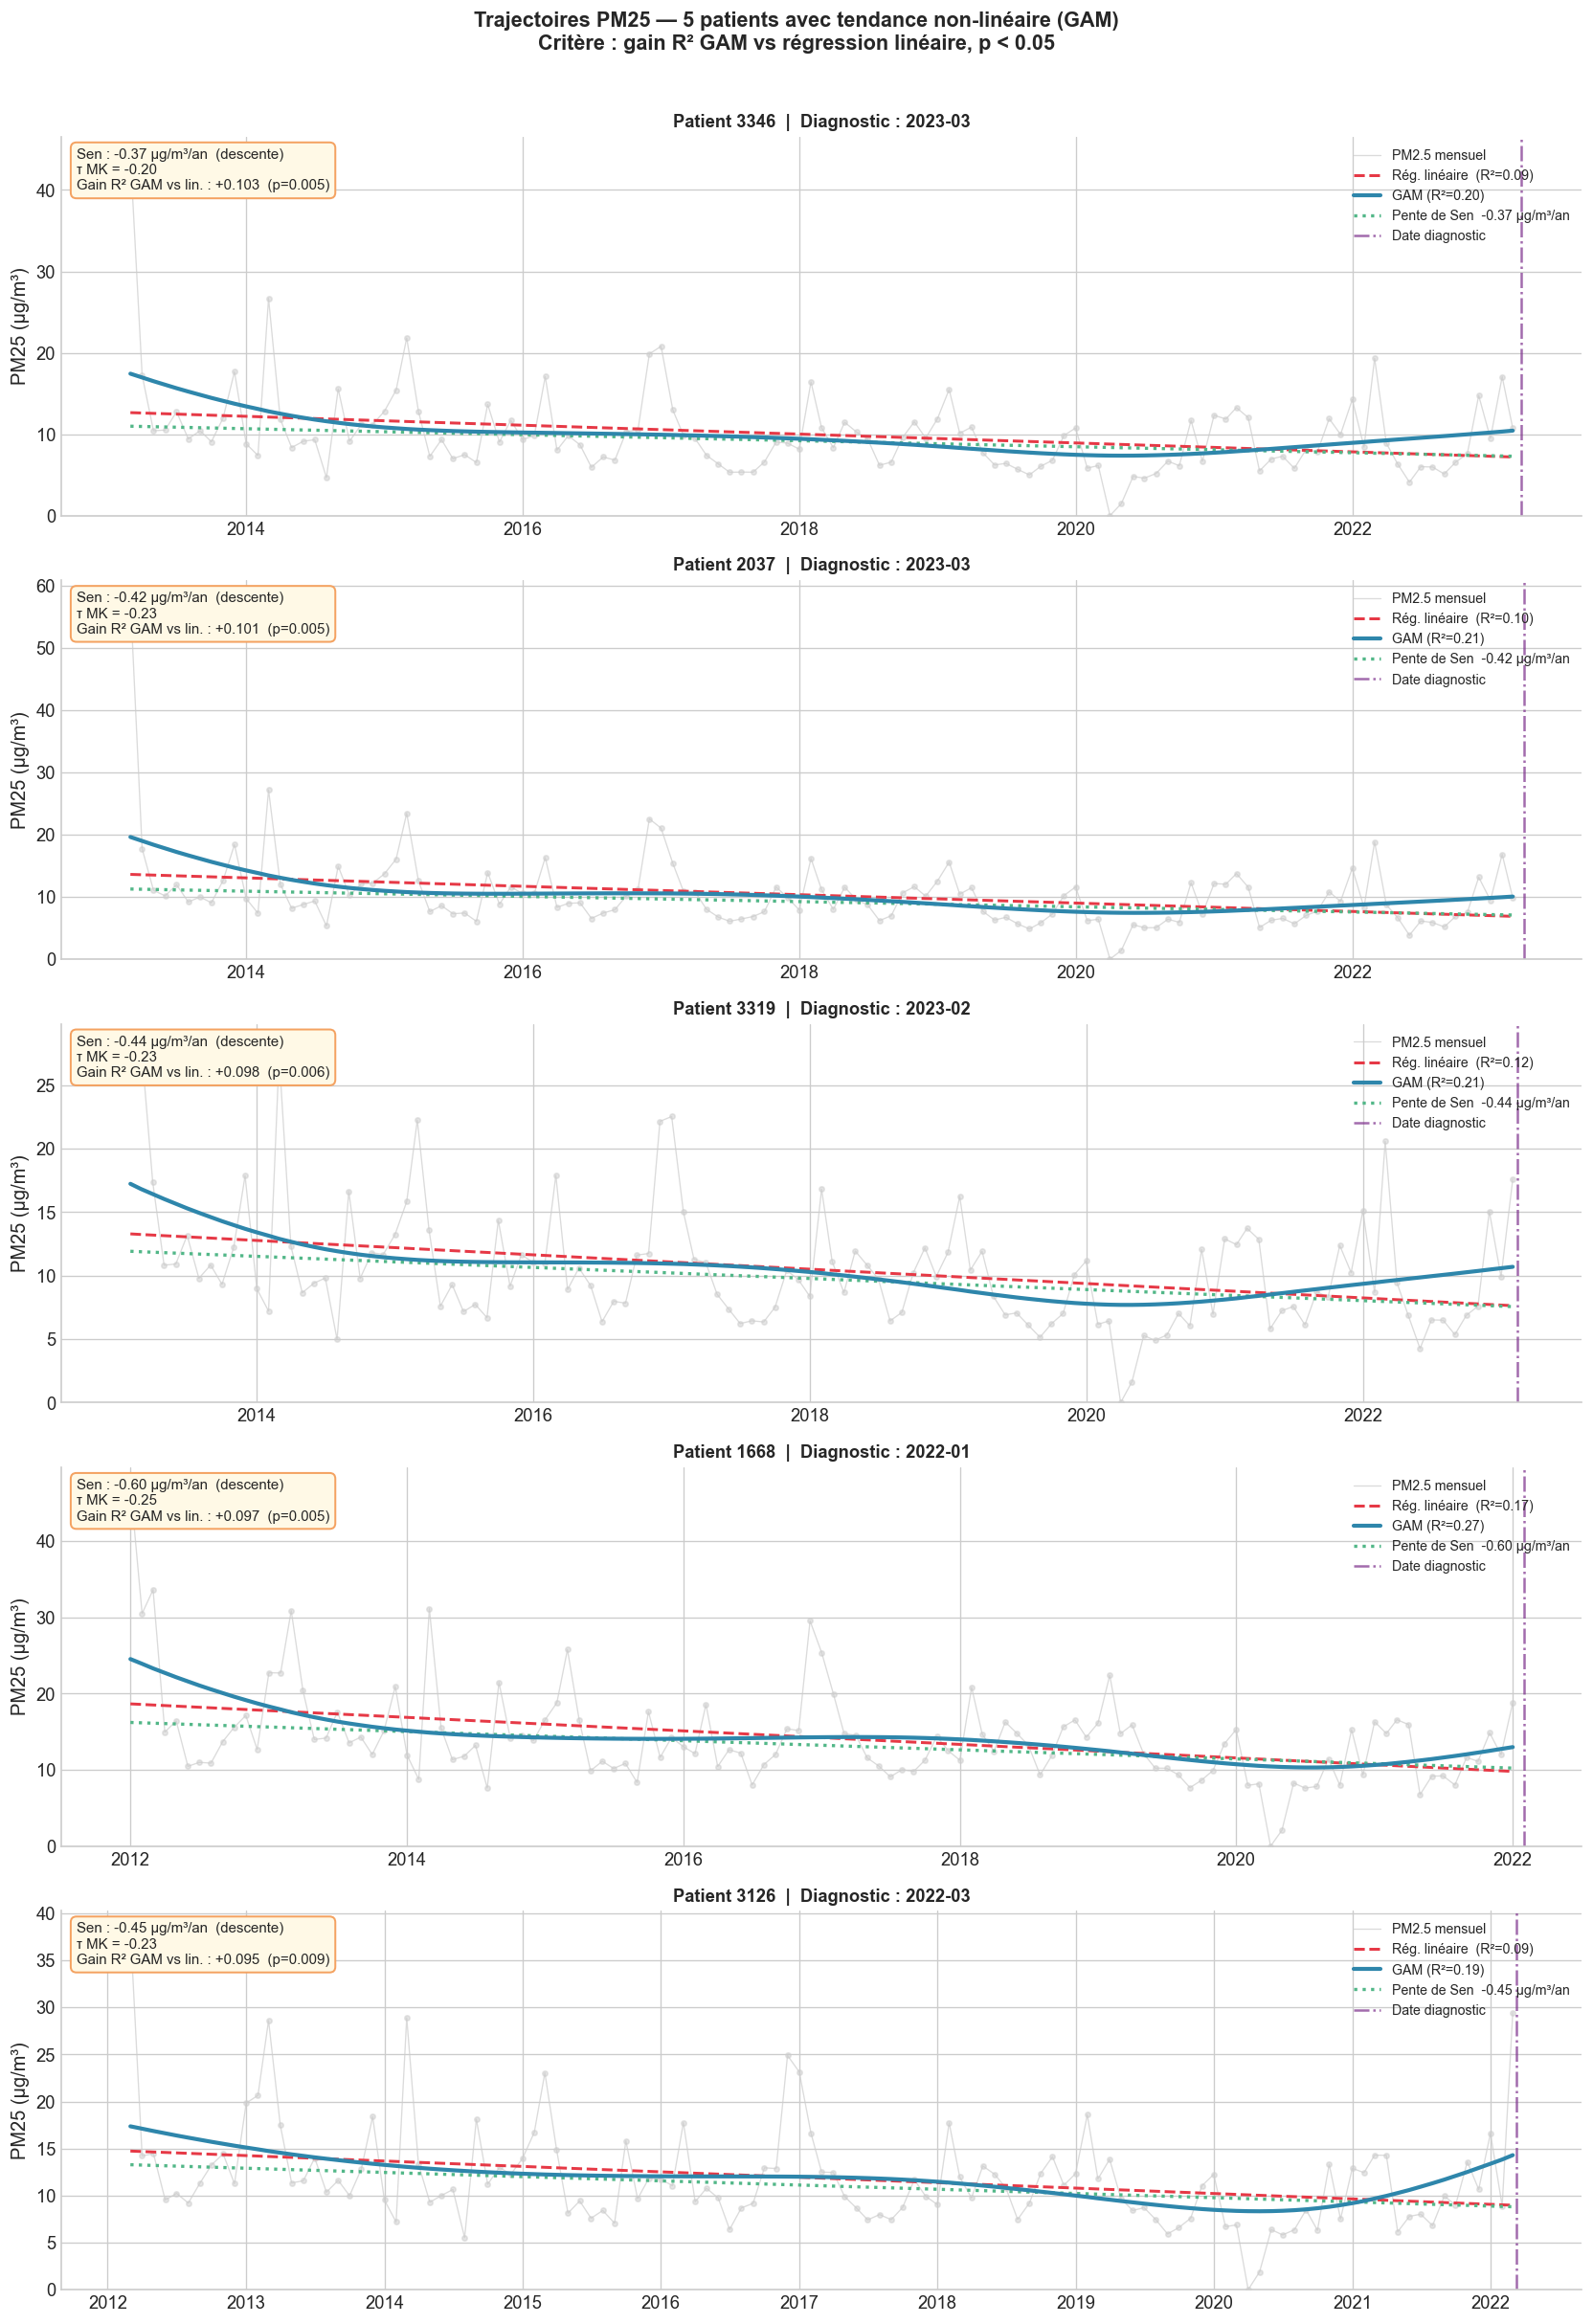


Patients sélectionnés :
 pseudo date_diagnostic  score  p_nonlin  r2_lin  r2_gam  mk_tau  sen_pente
   3346      2023-03-22 0.1034    0.0052  0.0938  0.1973 -0.2036    -0.3688
   2037      2023-03-30 0.1014    0.0055  0.1043  0.2057 -0.2350    -0.4176
   3319      2023-02-14 0.0978    0.0063  0.1166  0.2144 -0.2320    -0.4357
   1668      2022-01-31 0.0965    0.0046  0.1691  0.2656 -0.2510    -0.5982
   3126      2022-03-10 0.0953    0.0086  0.0948  0.1901 -0.2264    -0.4469


In [49]:
# =============================================================================
# VISUALISATION GAM — 5 PATIENTS AVEC TENDANCE NON LINÉAIRE
#
# Objectif : identifier les patients dont la tendance PM2.5 sur 10 ans
#            est NON LINÉAIRE (non capturable par une simple droite),
#            puis visualiser leur trajectoire avec le modèle GAM.
#
# Ce script est COMPLÉMENTAIRE au calcul Sen + MK :
#   - Sen + MK  → variable utilisée dans les modèles statistiques
#   - GAM       → outil de visualisation / exploration de la trajectoire
#
# Critère de non-linéarité : le GAM explique significativement mieux
# les données que la régression linéaire (test F, p < 0.05)
#
# Dépendances : pip install pygam pymannkendall
# =============================================================================

import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pymannkendall as mk
import seaborn as sns
from pygam import LinearGAM, s
from scipy.stats import f as f_dist


# ---------------------------------------------------------------------------
# PARAMÈTRES
# ---------------------------------------------------------------------------

POL              = 'PM25'         # polluant à visualiser
COL_PATIENT      = 'pseudo_provisoire'
COL_DATE         = 'date'
COL_DATE_DIAG    = 'date_diagnostic'
FENETRE_MOIS     = 120            # 10 ans
NB_PATIENTS      = 5              # nombre de patients à visualiser
SEUIL_P_NONLIN   = 0.05           # seuil p-value pour non-linéarité


# ---------------------------------------------------------------------------
# UTILITAIRES
# ---------------------------------------------------------------------------

def soustraire_mois(date_ts: pd.Timestamp, n_mois: int) -> pd.Timestamp:
    mois_res  = date_ts.month - (n_mois % 12)
    annee_res = date_ts.year  - (n_mois // 12)
    if mois_res <= 0:
        mois_res  += 12
        annee_res -= 1
    max_jour = calendar.monthrange(annee_res, mois_res)[1]
    return pd.Timestamp(annee_res, mois_res, min(date_ts.day, max_jour))


def serie_mensuelle(df_pat: pd.DataFrame) -> pd.Series:
    """Agrège les données journalières en moyennes mensuelles."""
    return (
        df_pat[[COL_DATE, POL]]
        .copy()
        .assign(**{COL_DATE: lambda d: pd.to_datetime(d[COL_DATE])})
        .set_index(COL_DATE)[POL]
        .resample('MS')
        .mean()
        .interpolate(method='linear', limit=3, limit_direction='both')
    )


def score_nonlinearite(valeurs: np.ndarray) -> dict:
    """
    Quantifie la non-linéarité en comparant GAM vs régression linéaire.

    Test F de comparaison de modèles :
      H0 : la relation est linéaire (régression linéaire suffit)
      H1 : la relation est non-linéaire (GAM apporte un gain significatif)

    Si p < SEUIL_P_NONLIN → tendance non-linéaire détectée.

    Retour
    ------
    score    : gain R² du GAM sur la régression linéaire (0 à 1)
    p_nonlin : p-value du test F (< 0.05 = non-linéaire)
    r2_lin   : R² de la régression linéaire
    r2_gam   : R² du GAM
    """
    n = len(valeurs)
    t = np.arange(n)

    # Régression linéaire
    coefs     = np.polyfit(t, valeurs, 1)
    pred_lin  = np.polyval(coefs, t)
    ss_res_lin = np.sum((valeurs - pred_lin)**2)
    ss_tot     = np.sum((valeurs - np.mean(valeurs))**2)
    r2_lin     = 1 - ss_res_lin / ss_tot if ss_tot > 0 else 0

    # GAM
    gam = LinearGAM(s(0, n_splines=10, spline_order=3)).fit(
        t.reshape(-1, 1), valeurs
    )
    pred_gam  = gam.predict(t.reshape(-1, 1))
    ss_res_gam = np.sum((valeurs - pred_gam)**2)
    r2_gam     = 1 - ss_res_gam / ss_tot if ss_tot > 0 else 0

    # Test F : comparaison modèle linéaire (df=2) vs GAM (df estimés)
    df_lin = 2                          # intercept + pente
    df_gam = gam.statistics_['edof']    # degrés de liberté effectifs GAM
    df1    = max(df_gam - df_lin, 1)
    df2    = max(n - df_gam, 1)

    if ss_res_gam > 0 and df1 > 0:
        F_stat = ((ss_res_lin - ss_res_gam) / df1) / (ss_res_gam / df2)
        p_val  = 1 - f_dist.cdf(F_stat, df1, df2)
    else:
        p_val  = 1.0

    gain_r2 = r2_gam - r2_lin

    return {
        'score':     round(gain_r2, 4),
        'p_nonlin':  round(p_val, 4),
        'r2_lin':    round(r2_lin, 4),
        'r2_gam':    round(r2_gam, 4),
        'pred_lin':  pred_lin,
        'pred_gam':  pred_gam,
    }


# ---------------------------------------------------------------------------
# DÉTECTION des patients avec tendance non-linéaire
# ---------------------------------------------------------------------------

def detecter_patients_nonlineaires(
    df_pollution: pd.DataFrame,
    df_clinique:  pd.DataFrame,
    n_patients:   int = NB_PATIENTS,
) -> pd.DataFrame:
    """
    Parcourt la cohorte, calcule le score de non-linéarité GAM pour
    chaque patient, et retourne les n_patients avec la tendance la
    plus non-linéaire (gain R² le plus élevé ET p < SEUIL_P_NONLIN).

    Retour
    ------
    DataFrame trié par score décroissant, colonnes :
        pseudo, date_diagnostic, score, p_nonlin, r2_lin, r2_gam,
        serie_mensuelle, pred_lin, pred_gam, mk_tau, sen_pente
    """
    df_poll = df_pollution.copy()
    df_clin = df_clinique.copy()
    df_poll[COL_DATE]     = pd.to_datetime(df_poll[COL_DATE])
    df_clin[COL_DATE_DIAG] = pd.to_datetime(df_clin[COL_DATE_DIAG])

    patients_communs = (
        set(df_poll[COL_PATIENT].unique()) &
        set(df_clin[COL_PATIENT].unique())
    )
    df_clin = df_clin[df_clin[COL_PATIENT].isin(patients_communs)]\
                .reset_index(drop=True)
    df_poll = df_poll[df_poll[COL_PATIENT].isin(patients_communs)]\
                .reset_index(drop=True)

    groupes = df_poll.groupby(COL_PATIENT)
    resultats = []

    print(f"Calcul non-linéarité GAM sur {len(df_clin)} patients...")
    for _, row in df_clin.iterrows():
        pseudo    = row[COL_PATIENT]
        date_diag = pd.Timestamp(row[COL_DATE_DIAG])
        date_deb  = soustraire_mois(date_diag, FENETRE_MOIS)

        if pseudo not in groupes.groups:
            continue

        idx    = groupes.groups[pseudo]
        df_brut = df_poll.loc[idx]

        masque = (
            (df_brut[COL_DATE] >= date_deb) &
            (df_brut[COL_DATE] <  date_diag)
        )
        df_pat = df_brut[masque].copy()

        if len(df_pat) == 0 or POL not in df_pat.columns:
            continue

        # Série mensuelle
        serie = serie_mensuelle(df_pat)
        valides = serie.dropna()
        if len(valides) < 24:
            continue

        valeurs = valides.values.astype(float)
        t_vals  = np.arange(len(valeurs))

        # Score non-linéarité
        scores = score_nonlinearite(valeurs)

        # Mann-Kendall + Sen sur la même série
        try:
            res_mk    = mk.original_test(valeurs)
            mk_tau    = round(float(res_mk.Tau), 4)
            sen_pente = round(float(res_mk.slope * 12), 4)
        except Exception:
            mk_tau = np.nan; sen_pente = np.nan

        resultats.append({
            'pseudo':          pseudo,
            'date_diagnostic': date_diag,
            'score':           scores['score'],
            'p_nonlin':        scores['p_nonlin'],
            'r2_lin':          scores['r2_lin'],
            'r2_gam':          scores['r2_gam'],
            'serie':           valides,         # pd.Series avec index dates
            'pred_lin':        scores['pred_lin'],
            'pred_gam':        scores['pred_gam'],
            'mk_tau':          mk_tau,
            'sen_pente':       sen_pente,
        })

    df_res = pd.DataFrame(resultats)
    if df_res.empty:
        print("Aucun patient trouvé.")
        return df_res

    # Filtrer non-linéaires et trier par score décroissant
    df_nonlin = (
        df_res[df_res['p_nonlin'] < SEUIL_P_NONLIN]
        .sort_values('score', ascending=False)
        .head(n_patients)
        .reset_index(drop=True)
    )

    print(f"\nPatients avec tendance non-linéaire (p < {SEUIL_P_NONLIN}) : "
          f"{len(df_res[df_res['p_nonlin'] < SEUIL_P_NONLIN])}")
    print(f"Patients sélectionnés pour visualisation : {len(df_nonlin)}")

    return df_nonlin


# ---------------------------------------------------------------------------
# VISUALISATION — 5 patients GAM non-linéaires
# ---------------------------------------------------------------------------

def visualiser_gam_nonlineaires(
    df_nonlin:  pd.DataFrame,
    polluant:   str  = POL,
    chemin:     str  = 'gam_tendances_nonlineaires.png',
) -> None:
    """
    Génère une figure avec un subplot par patient sélectionné.

    Chaque subplot montre :
      - La série mensuelle (points gris)
      - La tendance GAM (courbe bleue)
      - La tendance linéaire (droite rouge pointillée)
      - La pente de Sen (droite verte pointillée)
      - Annotation : Sen, tau, R² lin vs GAM
    """
    n = len(df_nonlin)
    if n == 0:
        print("Aucun patient à visualiser.")
        return

    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
    if n == 1:
        axes = [axes]

    couleurs = {
        'serie':  '#CCCCCC',
        'gam':    '#2E86AB',
        'lin':    '#E63946',
        'sen':    '#52B788',
    }

    for ax, (_, row) in zip(axes, df_nonlin.iterrows()):

        serie    = row['serie']
        dates    = serie.index
        valeurs  = serie.values
        t        = np.arange(len(valeurs))
        pred_lin = row['pred_lin']
        pred_gam = row['pred_gam']

        # Pente de Sen — droite passant par la médiane
        med_t   = np.median(t)
        med_v   = np.median(valeurs)
        sen_lin = med_v + (row['sen_pente'] / 12) * (t - med_t)

        # Tracé
        ax.plot(dates, valeurs,  color=couleurs['serie'], lw=0.8,
                alpha=0.7, zorder=1, label='PM2.5 mensuel')
        ax.scatter(dates, valeurs, color=couleurs['serie'],
                   s=10, alpha=0.5, zorder=2)
        ax.plot(dates, pred_lin, color=couleurs['lin'],  lw=1.8,
                ls='--', zorder=3, label=f"Rég. linéaire  (R²={row['r2_lin']:.2f})")
        ax.plot(dates, pred_gam, color=couleurs['gam'],  lw=2.5,
                zorder=4, label=f"GAM (R²={row['r2_gam']:.2f})")
        ax.plot(dates, sen_lin,  color=couleurs['sen'],  lw=2.0,
                ls=':', zorder=3, label=f"Pente de Sen  {row['sen_pente']:+.2f} μg/m³/an")

        # Date de diagnostic (barre verticale)
        ax.axvline(x=row['date_diagnostic'], color='#7B2D8B',
                   lw=1.5, ls='-.', alpha=0.7, label='Date diagnostic')

        # Titre + annotations
        p_str = '<0.001' if row['p_nonlin'] < 0.001 else f"{row['p_nonlin']:.3f}"
        tau_dir = 'montée' if row['mk_tau'] > 0 else ('descente' if row['mk_tau'] < 0 else 'stable')
        ax.set_title(
            f"Patient {row['pseudo']}  |  Diagnostic : {row['date_diagnostic'].strftime('%Y-%m')}",
            fontweight='bold', fontsize=11
        )
        annot = (
            f"Sen : {row['sen_pente']:+.2f} μg/m³/an  ({tau_dir})\n"
            f"τ MK = {row['mk_tau']:+.2f}\n"
            f"Gain R² GAM vs lin. : +{row['score']:.3f}  (p={p_str})"
        )
        ax.text(0.01, 0.97, annot, transform=ax.transAxes,
                fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9E6',
                          edgecolor='#F4A261', lw=1.2))

        ax.set_ylabel(f'{polluant} (μg/m³)')
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8.5, loc='upper right')
        sns.despine(ax=ax)

    fig.suptitle(
        f'Trajectoires {polluant} — 5 patients avec tendance non-linéaire (GAM)\n'
        f'Critère : gain R² GAM vs régression linéaire, p < {SEUIL_P_NONLIN}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(chemin, dpi=180, bbox_inches='tight', facecolor='white')
    print(f"\nFigure sauvegardée : {chemin}")
    plt.show()


# ---------------------------------------------------------------------------
# PIPELINE COMPLET
# ---------------------------------------------------------------------------

def run_visualisation_gam(
    df_pollution: pd.DataFrame,
    df_clinique:  pd.DataFrame,
    chemin:       str = 'gam_tendances_nonlineaires.png',
) -> pd.DataFrame:
    """
    Pipeline complet :
      1. Détecte les patients avec tendance non-linéaire
      2. Génère la figure GAM pour les 5 plus non-linéaires

    Paramètres
    ----------
    df_pollution : DataFrame journalier pollution
    df_clinique  : DataFrame clinique avec dates de diagnostic
    chemin       : chemin de sauvegarde de la figure

    Retour
    ------
    DataFrame des patients sélectionnés avec leurs scores
    """
    df_nonlin = detecter_patients_nonlineaires(df_pollution, df_clinique)

    if df_nonlin.empty:
        print("Aucun patient non-linéaire détecté.")
        return df_nonlin

    visualiser_gam_nonlineaires(df_nonlin, chemin=chemin)

    # Résumé exportable (sans les colonnes série/prédictions)
    cols_export = ['pseudo', 'date_diagnostic', 'score', 'p_nonlin',
                   'r2_lin', 'r2_gam', 'mk_tau', 'sen_pente']
    return df_nonlin[cols_export]


# ---------------------------------------------------------------------------
# EXEMPLE D'UTILISATION
# ---------------------------------------------------------------------------
if __name__ == '__main__':

    # df_poll et df_clinique doivent être déjà chargés
    df_selection = run_visualisation_gam(
        df_pollution = data,
        df_clinique  = df_clinique,
        chemin       = 'gam_tendances_nonlineaires.png',
    )

    print("\nPatients sélectionnés :")
    print(df_selection.to_string(index=False))

## PROXIMITE ROUTIERE

In [50]:
# ============================================================
# ETAPE 0 — Paramètres
# ============================================================

SHAPEFILE_PATH = r"H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Data\tmja-rrnc-2024-shp"
TMJA_COL       = "tmja"
BUFFER_SEUIL   = 500

# ============================================================
# ETAPE 1 — Charger le shapefile TMJA
# ============================================================

routes = gpd.read_file(SHAPEFILE_PATH)

print("CRS du shapefile :", routes.crs)
print("Colonnes disponibles :", routes.columns.tolist())
print("Nombre de tronçons :", len(routes))
print(routes[[TMJA_COL, "geometry"]].head())

# Reprojection en Lambert 93 si ce n'est pas déjà le cas
if routes.crs.to_epsg() != 2154:
    routes = routes.to_crs("EPSG:2154")
    print("Shapefile reprojeté en Lambert 93")

# ============================================================
# ETAPE 1bis — Nettoyage et conversion de la colonne TMJA
# ============================================================

print("\nType brut de la colonne tmja :", routes[TMJA_COL].dtype)
print("Exemples de valeurs brutes :", routes[TMJA_COL].head(10).tolist())

routes[TMJA_COL] = (
    routes[TMJA_COL]
    .astype(str)
    .str.strip()
    .str.replace("\u00a0", "", regex=False)  # espace insécable (fréquent dans les fichiers français)
    .str.replace(" ", "", regex=False)        # espace ordinaire (séparateur milliers)
    .str.replace(",", ".", regex=False)       # virgule décimale → point
    .replace("", np.nan)
    .replace("nan", np.nan)
    .replace("None", np.nan)
)

routes[TMJA_COL] = pd.to_numeric(routes[TMJA_COL], errors="coerce")

n_nan_tmja = routes[TMJA_COL].isna().sum()
print(f"Tronçons avec TMJA manquant après conversion : {n_nan_tmja} / {len(routes)}")
print("Distribution TMJA après nettoyage :")
print(routes[TMJA_COL].describe().round(0))

# ============================================================
# ETAPE 2 — Convertir df_expo en GeoDataFrame (WGS84 → Lambert 93)
# ============================================================

gdf_patients = gpd.GeoDataFrame(
    df_expo.copy(),
    geometry=gpd.points_from_xy(df_expo["x"], df_expo["y"]),
    crs="EPSG:4326"
)

gdf_patients = gdf_patients.to_crs("EPSG:2154")

print(f"\nPatients chargés : {len(gdf_patients)}")
print("CRS patients après reprojection :", gdf_patients.crs)

# ============================================================
# ETAPE 3 — Jointure spatiale : tronçon le plus proche par patient
# ============================================================

gdf_joined = gpd.sjoin_nearest(
    gdf_patients,
    routes[[TMJA_COL, "geometry"]],
    how="left",
    distance_col="dist_RN_m"
)

gdf_joined = gdf_joined[~gdf_joined.index.duplicated(keep="first")]

print(f"\nJointure effectuée.")
print(f"NaN dans dist_RN_m : {gdf_joined['dist_RN_m'].isna().sum()}")
print(f"NaN dans {TMJA_COL} : {gdf_joined[TMJA_COL].isna().sum()}")

# ============================================================
# ETAPE 4 — Construire les variables d'exposition au trafic
# ============================================================

# 4.1 Distance brute arrondie
gdf_joined["dist_RN_m"] = gdf_joined["dist_RN_m"].round(1)

# 4.2 Renommer TMJA
gdf_joined = gdf_joined.rename(columns={TMJA_COL: "TMJA_proche"})

# 4.3 Log-transformation (la colonne est maintenant numérique)
gdf_joined["TMJA_proche_log"] = np.log1p(gdf_joined["TMJA_proche"])

# 4.4 Variable binaire proximité
gdf_joined["proche_RN_500m"] = (gdf_joined["dist_RN_m"] < BUFFER_SEUIL).astype(int)

# 4.5 Indice composite trafic × proximité
gdf_joined["indice_trafic"] = (
    gdf_joined["TMJA_proche_log"] / np.log1p(gdf_joined["dist_RN_m"] + 1)
).round(4)

# ============================================================
# ETAPE 5 — Réintégrer dans df_expo
# ============================================================

COLS_TRAFIC = ["dist_RN_m", "TMJA_proche", "TMJA_proche_log", "proche_RN_500m", "indice_trafic"]

df_expo = df_expo.copy()
for col in COLS_TRAFIC:
    df_expo[col] = gdf_joined[col].values

print("\n--- Résumé des variables produites ---")
print(df_expo[COLS_TRAFIC].describe().round(2))

# ============================================================
# ETAPE 6 — Contrôle qualité
# ============================================================

print("\n--- Contrôle qualité ---")

n_missing = df_expo["TMJA_proche"].isna().sum()
print(f"Patients sans tronçon assigné : {n_missing} ({100*n_missing/len(df_expo):.1f}%)")

print(f"\nDistance à la RN la plus proche (mètres) :")
print(f"  Médiane : {df_expo['dist_RN_m'].median():.0f} m")
print(f"  Moyenne : {df_expo['dist_RN_m'].mean():.0f} m")
print(f"  Min     : {df_expo['dist_RN_m'].min():.0f} m")
print(f"  Max     : {df_expo['dist_RN_m'].max():.0f} m")
print(f"  P95     : {df_expo['dist_RN_m'].quantile(0.95):.0f} m")

n_proches = df_expo["proche_RN_500m"].sum()
print(f"\nPatients à moins de {BUFFER_SEUIL}m d'une RN : {n_proches} ({100*n_proches/len(df_expo):.1f}%)")

print(f"\nTMJA du tronçon le plus proche :")
print(f"  Médiane : {df_expo['TMJA_proche'].median():.0f} véh/j")
print(f"  Valeurs uniques (tronçons distincts) : {df_expo['TMJA_proche'].nunique()}")

# ============================================================
# ETAPE 7 — Sauvegarde optionnelle
# ============================================================

# df_expo.to_csv("df_expo_avec_trafic.csv", index=False)
# df_expo.to_parquet("df_expo_avec_trafic.parquet", index=False)

print("\nTerminé. Variables ajoutées à df_expo :", COLS_TRAFIC)

CRS du shapefile : PROJCS["RGF93 Lambert 93",GEOGCS["RGF93 geographiques (dms)",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["IGNF","RGF93G"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["IGNF","LAMB93"]]
Colonnes disponibles : ['route', 'longueur', 'prD', 'depPrD', 'concession', 'absD', 'cumulD', 'xD', 'yD', 'zD', 'prF', 'depPrF', 'concessi_1', 'cumulF', 'xF', 'yF', 'zF', 'cote', 'anneeMesur', 'typeCompta', 'typeComp_1', 'tmja', 'pctPL', 'geometry']
Nombre de tronçons : 1100
    tmj

In [51]:
df_expo

,sexe,age_diagnostic,date_diagnostic_x,stade,type_histologique,statut_tabagique,paquet_annee,mutation_EGFR,mutation_KRAS,mutation_BRAF,...,O3_mk_tendance,z_PM10,z_NO2,z_O3,IPG,dist_RN_m,TMJA_proche,TMJA_proche_log,proche_RN_500m,indice_trafic
0,masculin,70,2018-02-14,IV,Adenocarcinome,fumeur,55.0,,,,...,stable,0.429098,-0.209448,0.067924,0.095858,215.4,171937,12.054889,1,2.2400
1,masculin,54,2018-01-16,IV,Adenocarcinome,fumeur,40.0,,positive,,...,descente,1.575195,0.999387,-1.274504,0.433359,14316.8,28786,10.267679,0,1.0730
2,feminin,51,2018-02-09,IV,Adenocarcinome,fumeur,15.0,,positive,,...,descente,-0.399504,-1.230729,0.605041,-0.341731,3385.6,59554,10.994656,0,1.3527
3,masculin,75,2018-04-05,Non disponible,Carcinome epidermoide,fumeur,10.0,,positive,,...,stable,1.288407,0.716354,-1.038383,0.322126,12529.1,96596,11.478303,0,1.2164
4,feminin,65,2018-03-07,IV,Adenocarcinome,fumeur,25.0,,,,...,stable,1.702770,1.390470,-1.819634,0.424536,10453.4,28786,10.267679,0,1.1094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,feminin,85,2023-02-17,Non disponible,Adenocarcinome,fumeur,40.0,,positive,,...,montée,-1.134107,-0.486847,0.720308,-0.300216,4284.9,28786,10.267679,0,1.2277
1678,masculin,71,2023-04-05,Non disponible,Adenocarcinome,fumeur,40.0,,,,...,montée,-0.411205,0.364701,-0.322824,-0.123109,8515.8,28786,10.267679,0,1.1346
1679,feminin,64,2023-03-07,Non disponible,Carcinome indifferencie,fumeur,50.0,,positive,,...,stable,-1.294539,-0.642628,0.758944,-0.392741,9802.2,28786,10.267679,0,1.1172
1680,feminin,67,2018-09-21,Non disponible,Adenocarcinome,fumeur,60.0,,positive,,...,montée,0.747234,0.538570,-0.377245,0.302853,6098.1,171937,12.054889,0,1.3831


## VARIABLES SOCIO ECONOMIQUES

In [52]:
df_expo

,sexe,age_diagnostic,date_diagnostic_x,stade,type_histologique,statut_tabagique,paquet_annee,mutation_EGFR,mutation_KRAS,mutation_BRAF,...,O3_mk_tendance,z_PM10,z_NO2,z_O3,IPG,dist_RN_m,TMJA_proche,TMJA_proche_log,proche_RN_500m,indice_trafic
0,masculin,70,2018-02-14,IV,Adenocarcinome,fumeur,55.0,,,,...,stable,0.429098,-0.209448,0.067924,0.095858,215.4,171937,12.054889,1,2.2400
1,masculin,54,2018-01-16,IV,Adenocarcinome,fumeur,40.0,,positive,,...,descente,1.575195,0.999387,-1.274504,0.433359,14316.8,28786,10.267679,0,1.0730
2,feminin,51,2018-02-09,IV,Adenocarcinome,fumeur,15.0,,positive,,...,descente,-0.399504,-1.230729,0.605041,-0.341731,3385.6,59554,10.994656,0,1.3527
3,masculin,75,2018-04-05,Non disponible,Carcinome epidermoide,fumeur,10.0,,positive,,...,stable,1.288407,0.716354,-1.038383,0.322126,12529.1,96596,11.478303,0,1.2164
4,feminin,65,2018-03-07,IV,Adenocarcinome,fumeur,25.0,,,,...,stable,1.702770,1.390470,-1.819634,0.424536,10453.4,28786,10.267679,0,1.1094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,feminin,85,2023-02-17,Non disponible,Adenocarcinome,fumeur,40.0,,positive,,...,montée,-1.134107,-0.486847,0.720308,-0.300216,4284.9,28786,10.267679,0,1.2277
1678,masculin,71,2023-04-05,Non disponible,Adenocarcinome,fumeur,40.0,,,,...,montée,-0.411205,0.364701,-0.322824,-0.123109,8515.8,28786,10.267679,0,1.1346
1679,feminin,64,2023-03-07,Non disponible,Carcinome indifferencie,fumeur,50.0,,positive,,...,stable,-1.294539,-0.642628,0.758944,-0.392741,9802.2,28786,10.267679,0,1.1172
1680,feminin,67,2018-09-21,Non disponible,Adenocarcinome,fumeur,60.0,,positive,,...,montée,0.747234,0.538570,-0.377245,0.302853,6098.1,171937,12.054889,0,1.3831


In [53]:
df_socio = pd.read_excel(r'H:\PFE Loice\Notebooks\Loice_Canc-air_2025\loice_pneumodetect\Data\edi2021-iris-fm.xlsx', 
                         sheet_name='EDI2021_IRIS')

In [55]:
df = df_expo.copy()

df_final = df.merge(
    df_socio[['IRIS', 'EDI2021', 'quintileEDI2021']],
    left_on='CODE_IRIS',
    right_on='IRIS',
    how='left'
)

In [56]:
df_final

,sexe,age_diagnostic,date_diagnostic_x,stade,type_histologique,statut_tabagique,paquet_annee,mutation_EGFR,mutation_KRAS,mutation_BRAF,...,z_O3,IPG,dist_RN_m,TMJA_proche,TMJA_proche_log,proche_RN_500m,indice_trafic,IRIS_y,EDI2021,quintileEDI2021
0,masculin,70,2018-02-14,IV,Adenocarcinome,fumeur,55.0,,,,...,0.067924,0.095858,215.4,171937,12.054889,1,2.2400,930510203,-1.890918,2
1,masculin,54,2018-01-16,IV,Adenocarcinome,fumeur,40.0,,positive,,...,-1.274504,0.433359,14316.8,28786,10.267679,0,1.0730,751145401,9.700101,5
2,feminin,51,2018-02-09,IV,Adenocarcinome,fumeur,15.0,,positive,,...,0.605041,-0.341731,3385.6,59554,10.994656,0,1.3527,772850204,3.998364,5
3,masculin,75,2018-04-05,Non disponible,Carcinome epidermoide,fumeur,10.0,,positive,,...,-1.038383,0.322126,12529.1,96596,11.478303,0,1.2164,930290701,10.721689,5
4,feminin,65,2018-03-07,IV,Adenocarcinome,fumeur,25.0,,,,...,-1.819634,0.424536,10453.4,28786,10.267679,0,1.1094,751093303,-1.107064,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,feminin,85,2023-02-17,Non disponible,Adenocarcinome,fumeur,40.0,,positive,,...,0.720308,-0.300216,4284.9,28786,10.267679,0,1.2277,920630703,0.006627,3
1678,masculin,71,2023-04-05,Non disponible,Adenocarcinome,fumeur,40.0,,,,...,-0.322824,-0.123109,8515.8,28786,10.267679,0,1.1346,751166221,-3.240576,1
1679,feminin,64,2023-03-07,Non disponible,Carcinome indifferencie,fumeur,50.0,,positive,,...,0.758944,-0.392741,9802.2,28786,10.267679,0,1.1172,920220102,-2.242249,2
1680,feminin,67,2018-09-21,Non disponible,Adenocarcinome,fumeur,60.0,,positive,,...,-0.377245,0.302853,6098.1,171937,12.054889,0,1.3831,940520111,-4.568558,1


In [ ]:
# =============================================================================
# VISUALISATIONS PAR ANNÉE
# IMPORTANT : les variables locales sont nommées 'serie' et non 'data'
# pour éviter d'écraser la variable globale 'data'
# =============================================================================

def plot_kde_par_annee(df, polluant, colonne_annee='annee', figsize=(10, 6), alpha=0.4):
    """Courbes de densité (KDE) superposées par année pour un polluant."""
    fig, ax = plt.subplots(figsize=figsize)
    annees = sorted(df[colonne_annee].unique())
    for annee in annees:
        serie = df[df[colonne_annee] == annee][polluant].dropna()  # 'serie' pas 'data'
        if len(serie) == 0:
            continue
        sns.kdeplot(data=serie, ax=ax, label=str(annee), fill=True, alpha=alpha, linewidth=2)
    ax.set_xlabel(f'{polluant} (μg/m³)', fontsize=12)
    ax.set_ylabel('Densité', fontsize=12)
    ax.set_title(f'Distribution de {polluant} par année', fontsize=14, fontweight='bold')
    ax.legend(title='Année', loc='upper right')
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()


def plot_hist_par_annee(df, polluant, colonne_annee='annee', figsize=(10, 6), bins=50, alpha=0.5):
    """Histogrammes superposés par année pour un polluant."""
    fig, ax = plt.subplots(figsize=figsize)
    annees = sorted(df[colonne_annee].unique())
    for annee in annees:
        serie = df[df[colonne_annee] == annee][polluant].dropna()
        if len(serie) == 0:
            continue
        ax.hist(serie, bins=bins, alpha=alpha, label=str(annee), edgecolor='white', linewidth=0.5)
    ax.set_xlabel(f'{polluant} (μg/m³)', fontsize=12)
    ax.set_ylabel('Fréquence', fontsize=12)
    ax.set_title(f'Distribution de {polluant} par année', fontsize=14, fontweight='bold')
    ax.legend(title='Année', loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_boxplot_par_annee(df, polluant, colonne_annee='annee', figsize=(10, 6)):
    """Boxplots côte à côte par année pour un polluant."""
    fig, ax = plt.subplots(figsize=figsize)
    annees = sorted(df[colonne_annee].unique())
    sns.boxplot(data=df, x=colonne_annee, y=polluant, ax=ax, order=annees, palette='husl')
    ax.set_xlabel('Année', fontsize=12)
    ax.set_ylabel(f'{polluant} (μg/m³)', fontsize=12)
    ax.set_title(f'Boxplots de {polluant} par année', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_violin_par_annee(df, polluant, colonne_annee='annee', figsize=(10, 6)):
    """Violin plots par année pour un polluant."""
    fig, ax = plt.subplots(figsize=figsize)
    annees = sorted(df[colonne_annee].unique())
    sns.violinplot(data=df, x=colonne_annee, y=polluant, ax=ax,
                   order=annees, palette='husl', inner='quartile')
    ax.set_xlabel('Année', fontsize=12)
    ax.set_ylabel(f'{polluant} (μg/m³)', fontsize=12)
    ax.set_title(f'Violin plots de {polluant} par année', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_ridge_mensuel_par_annee(df, polluant, colonne_date='date', figsize=(18, 8)):
    """Ridge plot style avec dégradé de couleur, par mois, avec un subplot par année."""
    df = df.copy()
    df['date'] = pd.to_datetime(df[colonne_date])
    df['annee'] = df['date'].dt.year
    df['mois']  = df['date'].dt.month
    annees = sorted(df['annee'].unique())
    mois_noms = ['Janvier','Février','Mars','Avril','Mai','Juin',
                 'Juillet','Août','Septembre','Octobre','Novembre','Décembre']
    xmin  = max(0, df[polluant].quantile(0.001))
    xmax  = df[polluant].quantile(0.999)
    x_grid = np.linspace(xmin, xmax, 500)
    cmap  = plt.cm.plasma
    fig, axes = plt.subplots(1, len(annees), figsize=figsize, sharey=True)
    if len(annees) == 1:
        axes = [axes]
    for ax_idx, annee in enumerate(annees):
        ax = axes[ax_idx]
        df_annee = df[df['annee'] == annee]
        scale = 0.8
        for mois in range(12, 0, -1):
            serie_mois = df_annee[df_annee['mois'] == mois][polluant].dropna()
            if len(serie_mois) <= 10 or serie_mois.std() == 0:
                continue
            try:
                kde = gaussian_kde(serie_mois, bw_method=0.3)
            except LinAlgError:
                continue
            y_kde = kde(x_grid)
            y_kde = y_kde / y_kde.max() * scale
            baseline = mois
            for i in range(len(x_grid) - 1):
                color = cmap((x_grid[i] - xmin) / (xmax - xmin))
                ax.fill_between(x_grid[i:i+2], baseline, baseline + y_kde[i:i+2],
                                color=color, alpha=0.8, linewidth=0)
            ax.plot(x_grid, baseline + y_kde, color='black', linewidth=1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(0.5, 13.5)
        ax.set_xlabel(f'{polluant} (μg/m³)', fontsize=11)
        ax.set_title(f'{annee}', fontsize=14, fontweight='bold')
        ax.set_yticks(range(1, 13))
        ax.set_yticklabels(mois_noms, fontsize=10, fontweight='bold')
        ax.yaxis.grid(True, linestyle='--', alpha=0.3)
        ax.xaxis.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=xmin, vmax=xmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(f'{polluant} (μg/m³)', fontsize=11)
    plt.suptitle(f'Distribution de {polluant} par mois et par année',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def stats_par_annee(df, polluant, colonne_annee='annee'):
    """Tableau de statistiques descriptives par année pour un polluant."""
    return df.groupby(colonne_annee)[polluant].agg([
        ('N', 'count'), ('Moyenne', 'mean'), ('Médiane', 'median'),
        ('Écart-type', 'std'), ('Min', 'min'),
        ('P25', lambda x: x.quantile(0.25)), ('P75', lambda x: x.quantile(0.75)),
        ('P95', lambda x: x.quantile(0.95)), ('Max', 'max')
    ]).round(2)

## 3. Calcul des métriques d'exposition (fenêtre 10 ans)

In [ ]:
# =============================================================================
# CALCUL DES MÉTRIQUES D'EXPOSITION — VERSION 4
# Fenêtre : 120 mois (10 ans) AVANT le diagnostic
#
# CORRECTIONS v4 :
# - Remplacement de pd.DateOffset par calcul calendaire direct (year-10)
#   dans la boucle principale → élimine le bug DateOffset sur certains OS
# - Même correction dans filtrer_par_fenetre pour cohérence
# - reset_index(drop=True) après chaque filtrage pour garantir la cohérence
# =============================================================================

import calendar

POLLUANTS_METRIQUES = {'PM25': 'PM25', 'PM10': 'PM10', 'NO2': 'NO2', 'O3': 'O3'}

SEUILS_REGLEMENTAIRES = {
    'PM25': {'OMS_2021': 5, 'OMS_ancien': 10, 'modere': 15, 'UE': 25, 'eleve': 35},
    'PM10': {'OMS_2021': 15, 'OMS_ancien': 20, 'UE': 40, 'alerte': 50},
    'NO2':  {'OMS_2021': 10, 'modere': 25, 'UE': 40},
    'O3':   {'OMS': 100, 'info': 120, 'alerte': 180}
}

FENETRE_GLOBALE_MOIS = 120

FENETRES_CONFIG = {
    '0-6m':     (0, 6),   '6-12m':    (6, 12),  '12-18m':   (12, 18),  '18-24m':   (18, 24),
    '24-30m':   (24, 30), '30-36m':   (30, 36),  '36-42m':   (36, 42),  '42-48m':   (42, 48),
    '48-54m':   (48, 54), '54-60m':   (54, 60),  '60-66m':   (60, 66),  '66-72m':   (66, 72),
    '72-78m':   (72, 78), '78-84m':   (78, 84),  '84-90m':   (84, 90),  '90-96m':   (90, 96),
    '96-102m':  (96, 102),'102-108m': (102, 108),'108-114m': (108, 114),'114-120m': (114, 120),
}


# =============================================================================
# UTILITAIRE — calcul de date sans DateOffset
# =============================================================================

def soustraire_mois(date_ts: pd.Timestamp, n_mois: int) -> pd.Timestamp:
    """
    Soustrait n_mois à date_ts sans utiliser pd.DateOffset.
    Gère correctement les fins de mois (ex: 31 mars - 1 mois = 28/29 fév).
    Contourne le bug pd.DateOffset sur certaines configurations Windows/pandas.
    """
    total_mois = date_ts.month - (n_mois % 12)
    annee_res  = date_ts.year  - (n_mois // 12)

    if total_mois <= 0:
        total_mois += 12
        annee_res  -= 1

    # Gérer les fins de mois (ex: 31 jan - 1 mois → pas de 31 décembre problem,
    # mais 31 mars - 1 mois → 28/29 fév selon année)
    max_jour = calendar.monthrange(annee_res, total_mois)[1]
    jour_res = min(date_ts.day, max_jour)

    return pd.Timestamp(annee_res, total_mois, jour_res)


# =============================================================================
# FILTRE PAR FENÊTRE TEMPORELLE
# =============================================================================

def filtrer_par_fenetre(df_patient, date_diagnostic, mois_debut, mois_fin, col_date='date'):
    """
    Filtre les données pour une fenêtre temporelle AVANT le diagnostic.
    Utilise soustraire_mois() au lieu de pd.DateOffset.

    Fenêtre [mois_debut, mois_fin] depuis le diagnostic :
        date_fin   = diagnostic - mois_debut  (borne récente)
        date_debut = diagnostic - mois_fin    (borne ancienne)
    """
    date_fin   = soustraire_mois(date_diagnostic, mois_debut)
    date_debut = soustraire_mois(date_diagnostic, mois_fin)
    mask = (df_patient[col_date] >= date_debut) & (df_patient[col_date] < date_fin)
    return df_patient[mask]


# =============================================================================
# MÉTRIQUES DE TENDANCE CENTRALE
# =============================================================================

def calculer_tendance_centrale(serie, nom):
    s = serie[~np.isnan(serie)]
    if len(s) == 0:
        return {f'{nom}_moyenne': np.nan, f'{nom}_mediane': np.nan,
                f'{nom}_max': np.nan, f'{nom}_min': np.nan, f'{nom}_ecart_moy_med': np.nan}
    moy = np.mean(s)
    med = np.median(s)
    return {f'{nom}_moyenne': moy, f'{nom}_mediane': med,
            f'{nom}_max': np.max(s), f'{nom}_min': np.min(s), f'{nom}_ecart_moy_med': moy - med}


# =============================================================================
# MÉTRIQUES DE VARIABILITÉ
# =============================================================================

def calculer_variabilite(serie, nom):
    s = serie[~np.isnan(serie)]
    if len(s) == 0:
        return {f'{nom}_std': np.nan, f'{nom}_cv': np.nan, f'{nom}_iqr': np.nan}
    std     = np.std(s)
    moy     = np.mean(s)
    q75, q25 = np.percentile(s, [75, 25])
    return {f'{nom}_std': std, f'{nom}_cv': std / moy if moy > 0 else np.nan, f'{nom}_iqr': q75 - q25}


# =============================================================================
# EXPOSITION CUMULÉE
# =============================================================================

def calculer_exposition_cumulee(serie, nom):
    s        = serie[~np.isnan(serie)]
    n_total  = len(serie)
    n_valides = len(s)
    pct_manq = (n_total - n_valides) / n_total * 100 if n_total > 0 else np.nan
    if n_valides == 0:
        return {f'{nom}_cumul_120m': np.nan, f'{nom}_cumul_pct_manq': np.nan}
    return {f'{nom}_cumul_120m': np.nansum(serie), f'{nom}_cumul_pct_manq': pct_manq}


def calculer_exposition_ponderee(serie, nom, poids='lineaire'):
    idx_valides = ~np.isnan(serie)
    n = len(serie)
    if np.sum(idx_valides) == 0:
        return {f'{nom}_moy_pond_{poids}': np.nan}
    if poids == 'lineaire':
        w = np.linspace(0.1, 1.0, n)
    else:
        w = np.exp(np.linspace(-2, 0, n))
        w = w / w.max()
    serie_p = np.where(idx_valides, serie * w, 0)
    w_val   = np.where(idx_valides, w, 0)
    return {f'{nom}_moy_pond_{poids}': np.sum(serie_p) / np.sum(w_val) if np.sum(w_val) > 0 else np.nan}


# =============================================================================
# PICS ET PERCENTILES
# =============================================================================

def calculer_pics(serie, nom):
    s = serie[~np.isnan(serie)]
    if len(s) == 0:
        return {f'{nom}_P90': np.nan, f'{nom}_P95': np.nan,
                f'{nom}_P99': np.nan, f'{nom}_top10_mean': np.nan}
    seuil = np.percentile(s, 90)
    top10 = s[s >= seuil]
    return {f'{nom}_P90': np.percentile(s, 90), f'{nom}_P95': np.percentile(s, 95),
            f'{nom}_P99': np.percentile(s, 99),
            f'{nom}_top10_mean': np.mean(top10) if len(top10) > 0 else np.nan}


def calculer_pics_seuils_fixes(serie, nom, seuils):
    s = serie[~np.isnan(serie)]
    if len(s) == 0:
        return {f'{nom}_nb_sup_{v}_regl': np.nan for v in seuils.values()}
    return {f'{nom}_nb_sup_{v}_regl': int(np.sum(s > v)) for v in seuils.values()}


# =============================================================================
# ÉPISODES PROLONGÉS
# =============================================================================

def calculer_episodes(serie, nom, seuil, min_jours=3):
    if len(serie) == 0 or np.all(np.isnan(serie)):
        return {f'{nom}_nb_episodes': np.nan,
                f'{nom}_duree_totale_episodes': np.nan,
                f'{nom}_duree_max_episode': np.nan}
    au_dessus = np.nan_to_num((serie > seuil).astype(int), nan=0)
    episodes  = []
    compteur  = 0
    for val in au_dessus:
        if val == 1:
            compteur += 1
        else:
            if compteur >= min_jours:
                episodes.append(compteur)
            compteur = 0
    if compteur >= min_jours:
        episodes.append(compteur)
    return {f'{nom}_nb_episodes':           len(episodes),
            f'{nom}_duree_totale_episodes': sum(episodes) if episodes else 0,
            f'{nom}_duree_max_episode':     max(episodes) if episodes else 0}


# =============================================================================
# TRAJECTOIRE TEMPORELLE
# =============================================================================

def calculer_trajectoire(serie, nom):
    s = serie[~np.isnan(serie)]
    if len(s) < 30:
        return {f'{nom}_pente_annuelle': np.nan, f'{nom}_tendance': 'Indeterminee',
                f'{nom}_r2_tendance': np.nan}
    slope, _, r_value, _, _ = stats.linregress(np.arange(len(s)), s)
    pente = slope * 365
    tendance = 'Croissante' if pente > 0.5 else ('Decroissante' if pente < -0.5 else 'Stable')
    return {f'{nom}_pente_annuelle': pente, f'{nom}_tendance': tendance,
            f'{nom}_r2_tendance': r_value ** 2}


# =============================================================================
# INDICES COMPOSITES
# =============================================================================

def calculer_indices_composites(moyennes, ref_externe=None):
    ref = {**{'PM25': {'mean': 12, 'std': 5}, 'PM10': {'mean': 20, 'std': 8},
               'NO2':  {'mean': 25, 'std': 10}, 'O3':  {'mean': 50, 'std': 15}},
           **(ref_externe or {})}
    z = {}
    for pol, p in ref.items():
        key = f'{pol}_moyenne'
        z[f'z_{pol}'] = ((moyennes[key] - p['mean']) / p['std']
                         if key in moyennes and not np.isnan(moyennes.get(key, np.nan))
                         else np.nan)
    z_vals = [v for v in z.values() if not np.isnan(v)]
    ipg    = np.mean(z_vals) if z_vals else np.nan
    zpm25  = z.get('z_PM25', np.nan); zpm10 = z.get('z_PM10', np.nan)
    zno2   = z.get('z_NO2',  np.nan); zo3   = z.get('z_O3',   np.nan)
    ip = 0.7 * zpm25 + 0.3 * zpm10 if not (np.isnan(zpm25) or np.isnan(zpm10)) else np.nan
    ig = 0.6 * zno2  + 0.4 * zo3   if not (np.isnan(zno2)  or np.isnan(zo3))   else np.nan
    return {'IPG': ipg, 'indice_particules': ip, 'indice_gaz': ig, **z}


# =============================================================================
# QUARTILES PATIENTS
# =============================================================================

def calculer_quartiles_patients(df_m, polluants=None):
    if polluants is None:
        polluants = ['PM25', 'PM10', 'NO2', 'O3']
    seuils = {}
    for pol in polluants:
        col = f'{pol}_moyenne'
        if col in df_m.columns:
            v = df_m[col].dropna()
            if len(v) > 0:
                seuils[col] = {'Q1': np.percentile(v, 25), 'Q2': np.percentile(v, 50),
                               'Q3': np.percentile(v, 75), 'min': v.min(),
                               'max': v.max(), 'n': len(v)}
    return seuils


def assigner_quartile(valeur, seuils):
    if pd.isna(valeur): return np.nan
    if valeur <= seuils['Q1']: return 1
    elif valeur <= seuils['Q2']: return 2
    elif valeur <= seuils['Q3']: return 3
    else: return 4


def categoriser_par_quartiles(df, seuils):
    df = df.copy()
    for metrique, s in seuils.items():
        df[f'{metrique}_quartile'] = df[metrique].apply(lambda x: assigner_quartile(x, s))
    return df


# =============================================================================
# CALCUL POUR UN PATIENT
# =============================================================================

def calculer_metriques_patient(df_patient, date_diagnostic, col_date='date',
                                mapping_polluants=None, inclure_seuils_reglementaires=True):
    if mapping_polluants is None:
        mapping_polluants = POLLUANTS_METRIQUES

    metriques  = {}
    df_global  = df_patient.sort_values(col_date, ascending=True)

    metriques['nb_jours_total']        = len(df_global)
    metriques['date_debut_exposition'] = df_global[col_date].min() if len(df_global) > 0 else pd.NaT
    metriques['date_fin_exposition']   = df_global[col_date].max() if len(df_global) > 0 else pd.NaT

    if len(df_global) == 0:
        return metriques

    series = {pol: df_global[col].values if col in df_global.columns else np.full(len(df_global), np.nan)
              for pol, col in mapping_polluants.items()}

    for pol in mapping_polluants:
        metriques.update(calculer_tendance_centrale(series[pol], pol))
        metriques.update(calculer_variabilite(series[pol], pol))
        metriques.update(calculer_exposition_cumulee(series[pol], pol))
        col_pol = mapping_polluants[pol]
        st = df_global[col_pol].values if col_pol in df_global.columns else np.full(len(df_global), np.nan)
        metriques.update(calculer_exposition_ponderee(st, pol, poids='lineaire'))
        metriques.update(calculer_exposition_ponderee(st, pol, poids='exponentiel'))
        metriques.update(calculer_pics(series[pol], pol))
        if inclure_seuils_reglementaires and pol in SEUILS_REGLEMENTAIRES:
            metriques.update(calculer_pics_seuils_fixes(series[pol], pol, SEUILS_REGLEMENTAIRES[pol]))

    # Épisodes PM25 (Q3 individuel) et O3 (seuil OMS 100 μg/m³)
    if 'PM25' in series:
        pm25c      = series['PM25'][~np.isnan(series['PM25'])]
        seuil_pm25 = np.percentile(pm25c, 75) if len(pm25c) > 0 else np.nan
        if not np.isnan(seuil_pm25):
            metriques.update(calculer_episodes(series['PM25'], 'PM25', seuil=seuil_pm25, min_jours=3))
        else:
            metriques.update({'PM25_nb_episodes': np.nan,
                              'PM25_duree_totale_episodes': np.nan,
                              'PM25_duree_max_episode': np.nan})
    if 'O3' in series:
        metriques.update(calculer_episodes(series['O3'], 'O3', seuil=100.0, min_jours=3))

    for pol in mapping_polluants:
        metriques.update(calculer_trajectoire(series[pol], pol))

    metriques.update(calculer_indices_composites(
        {k: v for k, v in metriques.items() if k.endswith('_moyenne')}
    ))

    # Métriques par fenêtre de 6 mois
    for nom_f, (md, mf) in FENETRES_CONFIG.items():
        df_f = filtrer_par_fenetre(df_patient, date_diagnostic, md, mf, col_date)
        suf  = f'_{nom_f}'
        metriques[f'nb_jours{suf}'] = len(df_f)
        if len(df_f) > 0:
            for pol, col_pol in mapping_polluants.items():
                if col_pol in df_f.columns:
                    sf = df_f[col_pol].dropna().values
                    if len(sf) > 0:
                        metriques[f'{pol}_moy{suf}'] = np.mean(sf)
                        metriques[f'{pol}_med{suf}'] = np.median(sf)
                        metriques[f'{pol}_max{suf}'] = np.max(sf)
                        metriques[f'{pol}_std{suf}'] = np.std(sf)

    return metriques


# =============================================================================
# CALCUL POUR TOUTE LA COHORTE
# =============================================================================

def calculer_metriques_cohorte(df_pollution, df_clinique_input,
                                col_patient='pseudo_provisoire', col_date='date',
                                col_date_diagnostic='date_diagnostic',
                                mapping_polluants=None, annee_min_diagnostic=None,
                                inclure_seuils_reglementaires=True, verbose=True):
    """
    Calcule les métriques d'exposition pour toute la cohorte.
    Fenêtre : 120 mois (10 ans) AVANT le diagnostic.

    Utilise soustraire_mois() au lieu de pd.DateOffset pour le calcul
    de la borne inférieure de la fenêtre — contourne le bug DateOffset
    observé sur certaines configurations Windows/pandas.
    """
    if mapping_polluants is None:
        mapping_polluants = POLLUANTS_METRIQUES

    # Copies de travail
    df_poll = df_pollution.copy()
    df_clin = df_clinique_input.copy()

    # Conversion numpy — garantit datetime64[ns] sur tous les OS
    df_poll[col_date]            = df_poll[col_date].values.astype('datetime64[ns]')
    df_clin[col_date_diagnostic] = df_clin[col_date_diagnostic].values.astype('datetime64[ns]')

    assert df_poll[col_date].dtype == 'datetime64[ns]', \
        f"ERREUR : '{col_date}' n'est pas en datetime64[ns]"
    assert df_clin[col_date_diagnostic].dtype == 'datetime64[ns]', \
        f"ERREUR : '{col_date_diagnostic}' n'est pas en datetime64[ns]"

    if annee_min_diagnostic:
        df_clin = df_clin[df_clin[col_date_diagnostic].dt.year >= annee_min_diagnostic]
        if verbose:
            print(f"Patients avec diagnostic >= {annee_min_diagnostic} : {len(df_clin)}")

    # Intersection des patients présents dans les deux tables
    patients_communs = (
        set(df_poll[col_patient].unique()) &
        set(df_clin[col_patient].unique())
    )
    if verbose:
        print(f"Patients avec données pollution ET cliniques : {len(patients_communs)}")

    df_clin = df_clin[df_clin[col_patient].isin(patients_communs)].reset_index(drop=True)
    df_poll = df_poll[df_poll[col_patient].isin(patients_communs)].reset_index(drop=True)

    # Reconversion après filtrage — le slicing peut perdre le dtype sur certains OS
    df_poll[col_date] = df_poll[col_date].values.astype('datetime64[ns]')

    # Convertir toutes les dates de df_poll en int64 (nanosecondes depuis epoch)
    # Une seule fois avant la boucle — comparaison numpy pure dans la boucle,
    # indépendante de tout comportement pandas/OS/version
    dates_poll_ns = df_poll[col_date].values.astype('int64')

    # Index groupés par patient — accès O(1) sans re-filtrer le DataFrame entier
    groupes_poll  = df_poll.groupby(col_patient)

    resultats = []
    exclus    = []
    iterator  = df_clin[col_patient].unique()
    if verbose:
        iterator = tqdm(iterator, desc="Calcul métriques (120 mois)")

    for pseudo in iterator:
        date_diag  = pd.Timestamp(
            df_clin.loc[df_clin[col_patient] == pseudo, col_date_diagnostic].iloc[0]
        )
        date_debut = soustraire_mois(date_diag, FENETRE_GLOBALE_MOIS)

        # Bornes en nanosecondes int64 — aucune ambiguïté de type possible
        diag_ns  = np.int64(date_diag.value)
        debut_ns = np.int64(date_debut.value)

        # Patient absent de df_poll (ne devrait pas arriver après l'intersection)
        if pseudo not in groupes_poll.groups:
            exclus.append(pseudo)
            continue

        # Index des lignes de ce patient dans df_poll
        idx_patient      = groupes_poll.groups[pseudo]
        dates_patient_ns = dates_poll_ns[idx_patient]

        # Masque numpy sur int64 — bypasse tout problème de dtype pandas
        masque = (dates_patient_ns < diag_ns) & (dates_patient_ns >= debut_ns)

        if masque.sum() == 0:
            exclus.append(pseudo)
            continue

        df_pat = df_poll.loc[idx_patient[masque]].copy()

        m = calculer_metriques_patient(
            df_pat, date_diag, col_date,
            mapping_polluants, inclure_seuils_reglementaires
        )
        m[col_patient]       = pseudo
        m['date_diagnostic'] = date_diag
        resultats.append(m)

    if verbose:
        if exclus:
            print(f"\nPatients exclus (aucune donnée dans la fenêtre 10 ans) : {len(exclus)}")
            pd.DataFrame({'pseudo_provisoire': exclus}).to_csv(
                'patients_exclus.csv', index=False, sep=';'
            )
        else:
            print("\nAucun patient exclu — toute la cohorte est incluse dans l'analyse.")

    df_m = pd.DataFrame(resultats)
    if len(df_m) == 0:
        print("ATTENTION : aucune métrique calculée.")
        return df_m, {}

    cols_id = [col_patient, 'date_diagnostic', 'nb_jours_total',
               'date_debut_exposition', 'date_fin_exposition']
    df_m = df_m[cols_id + [c for c in df_m.columns if c not in cols_id]]

    seuils_q = calculer_quartiles_patients(df_m, list(mapping_polluants.keys()))
    df_m     = categoriser_par_quartiles(df_m, seuils_q)

    if verbose:
        print(f"\nMétriques calculées pour {len(df_m)} patients | {len(df_m.columns)} variables")
        print('\n' + '=' * 65)
        print('RÉSUMÉ — Quartiles PM2.5 (moyennes patients sur 10 ans)')
        print('=' * 65)
        if 'PM25_moyenne' in seuils_q:
            s = seuils_q['PM25_moyenne']
            print(f"  Q1 : ≤ {s['Q1']:.2f} | Q2 : {s['Q1']:.2f}–{s['Q2']:.2f} | "
                  f"Q3 : {s['Q2']:.2f}–{s['Q3']:.2f} | Q4 : > {s['Q3']:.2f} μg/m³")
        if 'PM25_cumul_120m' in df_m.columns:
            print(f"  Cumul médian PM2.5 : {df_m['PM25_cumul_120m'].median():,.0f} μg/m³×j")

    return df_m, seuils_q


# =============================================================================
# CRÉATION DES GROUPES NF / F-SNF / F-SF
# =============================================================================

def creer_groupes(df):
    """Crée la colonne 'groupe' : NF / F-SNF / F-SF."""
    mutations = ['EGFR', 'ALK', 'ROS1', 'ERBB2', 'RET', 'NTRK', 'MET']
    df        = df.copy()
    cols_mut  = [f'mutation_{m}' for m in mutations if f'mutation_{m}' in df.columns]
    df['a_mutation_non_fumeur'] = df[cols_mut].any(axis=1) if cols_mut else False

    nf_labels = {'non fumeur', 'non-fumeur', 'jamais fumé', 'never smoker'}
    f_labels  = {'fumeur', 'fumeur actif', 'ancien fumeur', 'ex-fumeur',
                 'current smoker', 'former smoker', 'smoker'}

    def _g(row):
        s = str(row.get('statut_tabagique', '')).lower().strip()
        if s in nf_labels: return 'NF'
        if s in f_labels:  return 'F-SNF' if row.get('a_mutation_non_fumeur', False) else 'F-SF'
        return 'AUTRE'

    df['groupe'] = df.apply(_g, axis=1)
    return df

# VISUALISATION

## 4. DESCRIPTION GLOBAL DE LA VARIATION DE PM25 

✅ Sauvegardé : ridgeline_PM25_2009-2015.png


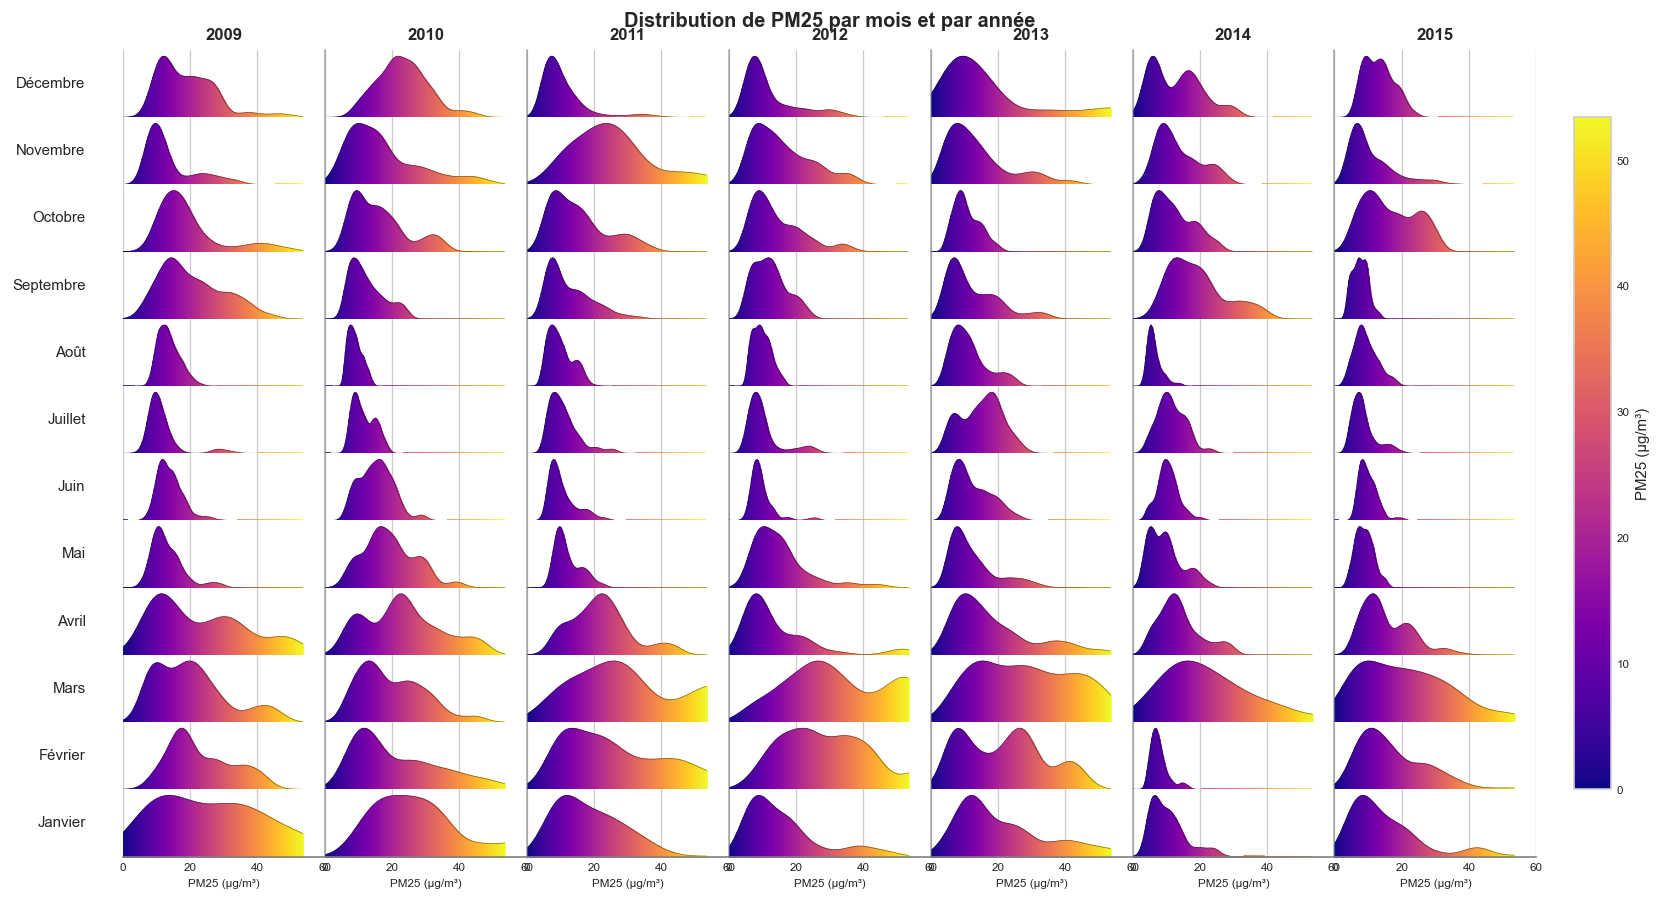

✅ Sauvegardé : ridgeline_PM25_2016-2023.png


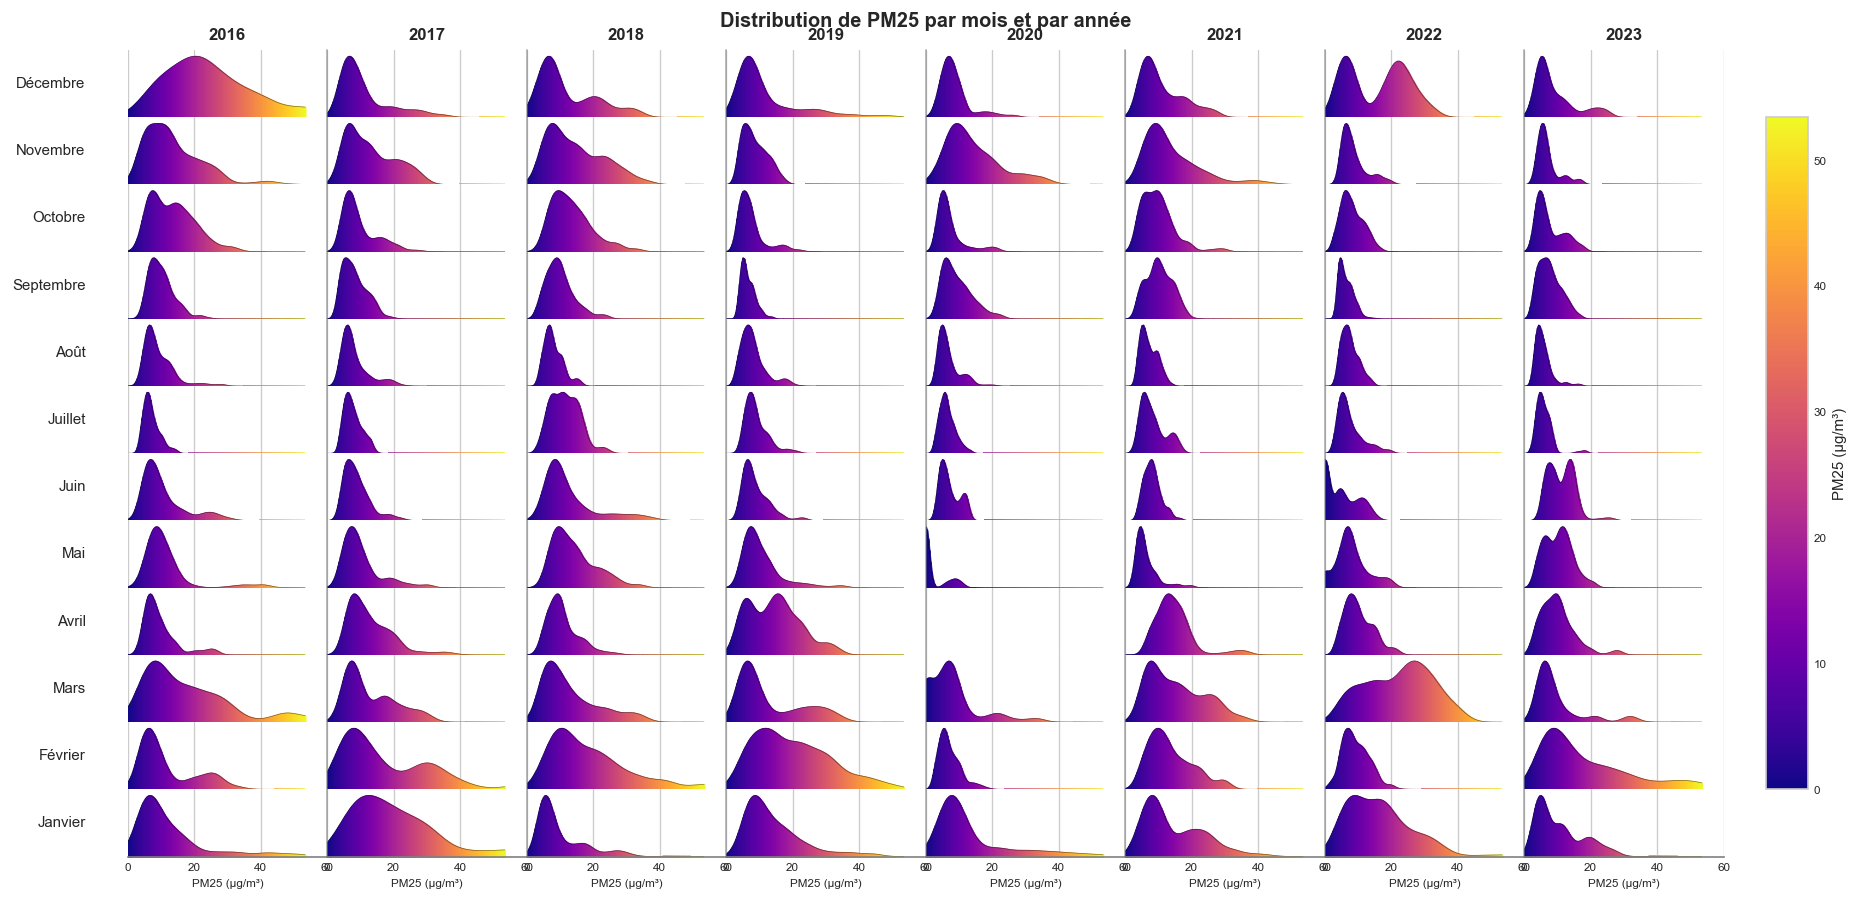

"\n# Charger les données\ndf_pollution = pd.read_csv('pollution_journaliere.csv')  # date, PM25, pseudo_provisoire\ndf_final = pd.read_excel('cohorte_patients.xlsx')        # pseudo_provisoire, ...\n\n# Graphique 2009-2015\nplot_ridgeline_mensuel(df_pollution, df_final, \n                        annees=range(2009, 2016),\n                        save_path='ridgeline_PM25_2009-2015.png')\n\n# Graphique 2016-2023\nplot_ridgeline_mensuel(df_pollution, df_final,\n                        annees=range(2016, 2024),\n                        save_path='ridgeline_PM25_2016-2023.png')\n"

In [ ]:
# =============================================================================
# RIDGELINE PLOTS MENSUELS PM25 — FILTRÉS PAR PATIENTS DE LA COHORTE
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde

MOIS_LABELS = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
               'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']


def plot_ridgeline_mensuel(df_pollution, df_patients, colonne_id='pseudo_provisoire',
                            colonne_date='date', colonne_pm='PM25',
                            annees=None, cmap='plasma', titre=None, save_path=None):
    """
    Ridgeline plot mensuel par année, filtré sur les patients de la cohorte.
    """
    
    # Filtrer pollution sur patients de la cohorte
    patients = df_patients[colonne_id].unique()
    df = df_pollution[df_pollution[colonne_id].isin(patients)].copy()
    
    df[colonne_date] = pd.to_datetime(df[colonne_date], errors='coerce')
    df = df.dropna(subset=[colonne_date, colonne_pm])
    df['annee'] = df[colonne_date].dt.year
    df['mois'] = df[colonne_date].dt.month
    
    # Années
    if annees is None:
        annees = sorted(df['annee'].unique())
    else:
        annees = [a for a in annees if a in df['annee'].unique()]
    
    n_annees = len(annees)
    if n_annees == 0:
        print("⚠️ Aucune donnée disponible.")
        return None
    
    # Figure avec espace à gauche pour les labels mois
    fig, axes = plt.subplots(12, n_annees, figsize=(2 * n_annees + 1.5, 8),
                              sharex=True, sharey=True,
                              gridspec_kw={'hspace': 0, 'wspace': 0})
    
    # Ajuster les marges pour laisser de l'espace à gauche
    plt.subplots_adjust(left=0.12, right=0.88, top=0.92, bottom=0.08)
    
    if n_annees == 1:
        axes = axes.reshape(-1, 1)
    
    # Colormap
    colormap = cm.get_cmap(cmap)
    x_max = min(df[colonne_pm].quantile(0.99), 80)
    x_range = np.linspace(0, x_max, 150)
    norm = Normalize(vmin=0, vmax=x_max)
    
    # Plot
    for row_idx, mois in enumerate(range(12, 0, -1)):
        for col_idx, annee in enumerate(annees):
            ax = axes[row_idx, col_idx]
            
            # Ligne horizontale de séparation
            ax.axhline(y=0, color='lightgray', lw=0.5)
            
            # Données
            vals = df.loc[(df['annee'] == annee) & (df['mois'] == mois), colonne_pm].dropna().values
            
            if len(vals) >= 5:
                try:
                    kde = gaussian_kde(vals, bw_method=0.3)
                    density = kde(x_range)
                    density = density / density.max()
                    
                    # Gradient fill
                    for i in range(len(x_range) - 1):
                        ax.fill_between(x_range[i:i+2], 0, density[i:i+2],
                                        color=colormap(norm(x_range[i])), alpha=0.9)
                    ax.plot(x_range, density, color='black', lw=0.4, alpha=0.5)
                except:
                    pass
            
            # Axes
            ax.set_xlim(0, x_max)
            ax.set_ylim(0, 1.1)
            ax.set_yticks([])
            ax.set_ylabel('')
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Titre année (ligne du haut)
            if row_idx == 0:
                ax.set_title(str(annee), fontsize=10, fontweight='bold')
    
    # Labels mois à GAUCHE - en dehors de la figure
    for row_idx, mois in enumerate(range(12, 0, -1)):
        # Position Y du centre de la ligne
        y_pos = 1 - (row_idx + 0.5) / 12
        y_fig = 0.08 + y_pos * 0.84  # Ajuster selon les marges
        fig.text(0.10, y_fig, MOIS_LABELS[mois - 1], 
                 fontsize=9, ha='right', va='center')
    
    # Axes X (dernière ligne)
    for col_idx in range(n_annees):
        ax = axes[-1, col_idx]
        ax.spines['bottom'].set_visible(True)
        ax.spines['bottom'].set_color('gray')
        ax.set_xticks([0, 20, 40, 60])
        ax.set_xticklabels(['0', '20', '40', '60'], fontsize=7)
        ax.set_xlabel(f'{colonne_pm} (μg/m³)', fontsize=7)
    
    # Lignes verticales entre années (sur toute la hauteur)
    for col_idx in range(1, n_annees):
        x_pos = 0.12 + (col_idx / n_annees) * 0.76  # Ajuster selon les marges
        fig.add_artist(plt.Line2D([x_pos, x_pos], [0.08, 0.92], 
                                   transform=fig.transFigure, 
                                   color='gray', lw=1.2, alpha=0.5))
    
    # Colorbar à droite
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'{colonne_pm} (μg/m³)', fontsize=9)
    cbar.ax.tick_params(labelsize=7)
    
    # Titre
    if titre is None:
        titre = f'Distribution de {colonne_pm} par mois et par année'
    fig.suptitle(titre, fontsize=12, fontweight='bold', y=0.96)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✅ Sauvegardé : {save_path}")
    
    plt.show()
    return fig


# =============================================================================
# UTILISATION
# =============================================================================

# Graphique 2009-2015
plot_ridgeline_mensuel(data, df_final, 
                        annees=range(2009, 2016),
                        save_path='ridgeline_PM25_2009-2015.png')

# Graphique 2016-2023
plot_ridgeline_mensuel(data, df_final,
                        annees=range(2016, 2024),
                        save_path='ridgeline_PM25_2016-2023.png')

"""
# Charger les données
df_pollution = pd.read_csv('pollution_journaliere.csv')  # date, PM25, pseudo_provisoire
df_final = pd.read_excel('cohorte_patients.xlsx')        # pseudo_provisoire, ...

# Graphique 2009-2015
plot_ridgeline_mensuel(df_pollution, df_final, 
                        annees=range(2009, 2016),
                        save_path='ridgeline_PM25_2009-2015.png')

# Graphique 2016-2023
plot_ridgeline_mensuel(df_pollution, df_final,
                        annees=range(2016, 2024),
                        save_path='ridgeline_PM25_2016-2023.png')
"""

## 5. Stats descriptives — 3 analyses


   📊 Debug Analyse 3:
      - Non-fumeurs : 241
      - Fumeurs légers (PA ≤ 5) : 42
      - Fumeurs modérés/forts (PA > 5) : 1399

   📊 Debug Analyse 4:
      - BRAF+ : 74
      - KRAS+ : 377
      - Non-fumeurs stricts : 241
      - BRAF/KRAS chez non-fumeurs : 24
      - Groupe A1 (7 mut NF) : 332
      - Groupe A4 (élargi)   : 350 (+18 via BRAF/KRAS NF)

EFFECTIFS PAR ANALYSE

  Analyse 1 — 7 mutations NF vs Autres :
    Autres                                   :  1350  (80.3%)
    Groupe A — 7 mutations NF                :   332  (19.7%)

  Analyse 2 — Exposés vs Non exposés :
    Exposé (Faible→Très forte)               :  1441  (85.7%)
    Non exposé                               :   241  (14.3%)

  Analyse 3 — Non-fumeurs + Fumeurs légers (PA≤5) vs Fumeurs modérés/forts :
    Fumeur modéré/fort (PA>5)                :  1399  (83.2%)
    Non-fumeur / Fumeur léger (PA≤5)         :   283  (16.8%)

  Analyse 4 — Mutations NF + Non-fumeurs BRAF/KRAS vs Autres :
    Autres          

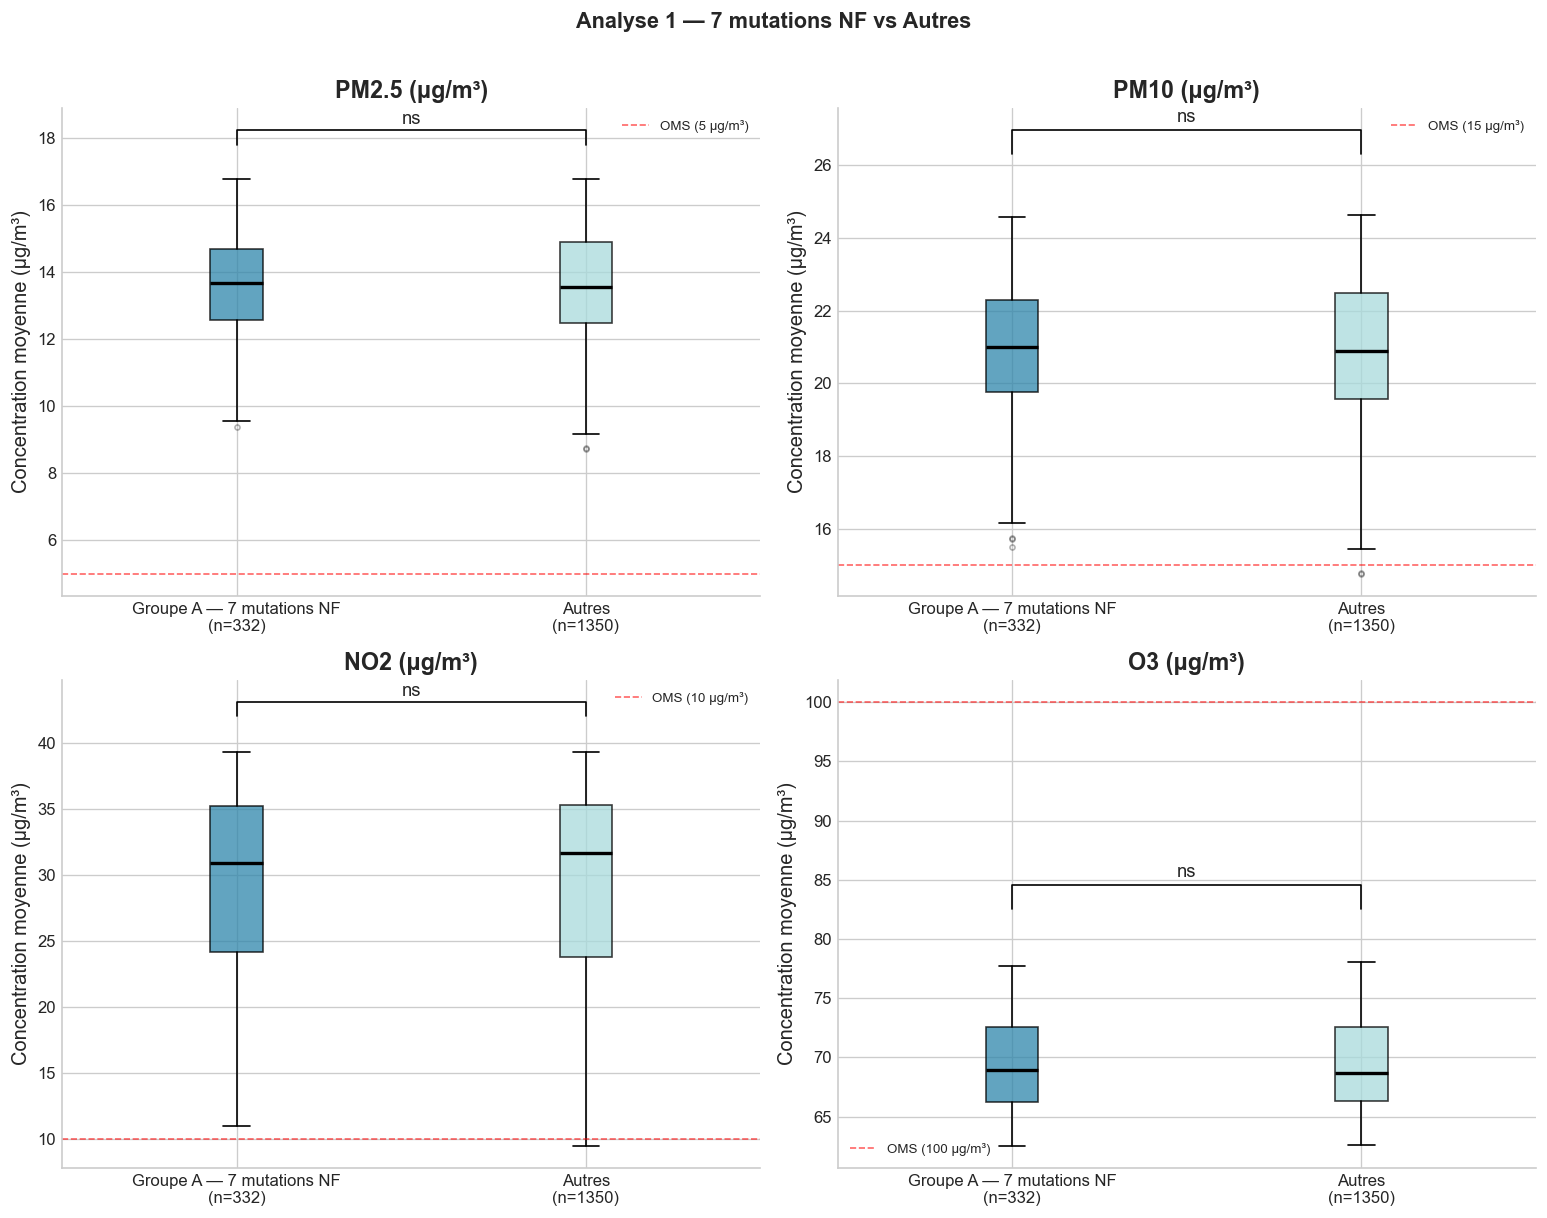

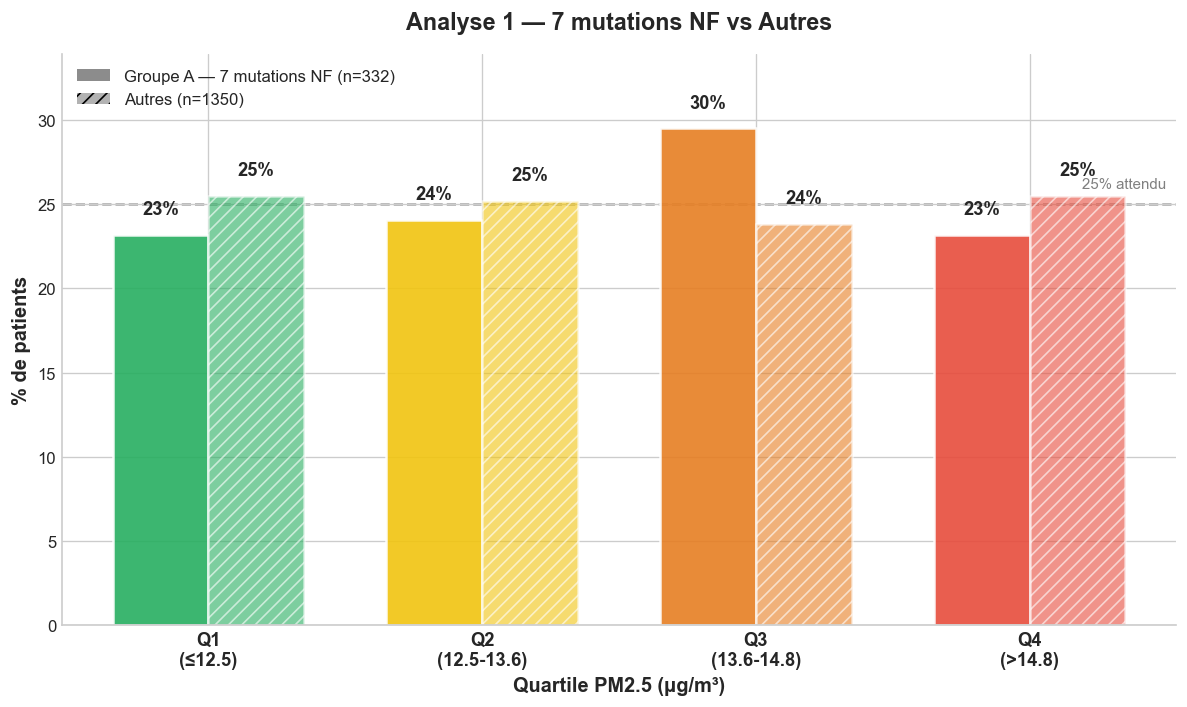


📊 Tests Mann-Whitney par fenêtre temporelle :
Fenêtre        Médiane G1   Médiane G2      p-value    Signif.
----------------------------------------------------------------------
0-6m                10.65        10.78        0.930         ns
6-12m               10.35        10.44        0.361         ns
12-18m              10.93        11.01        0.759         ns
18-24m              10.93        10.83        0.708         ns
24-30m              11.51        11.22        0.426         ns
30-36m              11.37        11.37        0.938         ns
36-42m              12.39        11.96        0.158         ns
42-48m              12.28        12.32        0.550         ns
48-54m              12.83        12.59        0.143         ns
54-60m              12.94        12.90        0.906         ns
60-66m              13.38        13.24        0.371         ns
66-72m              13.14        13.27        0.557         ns
72-78m              14.17        13.88        0.102         ns


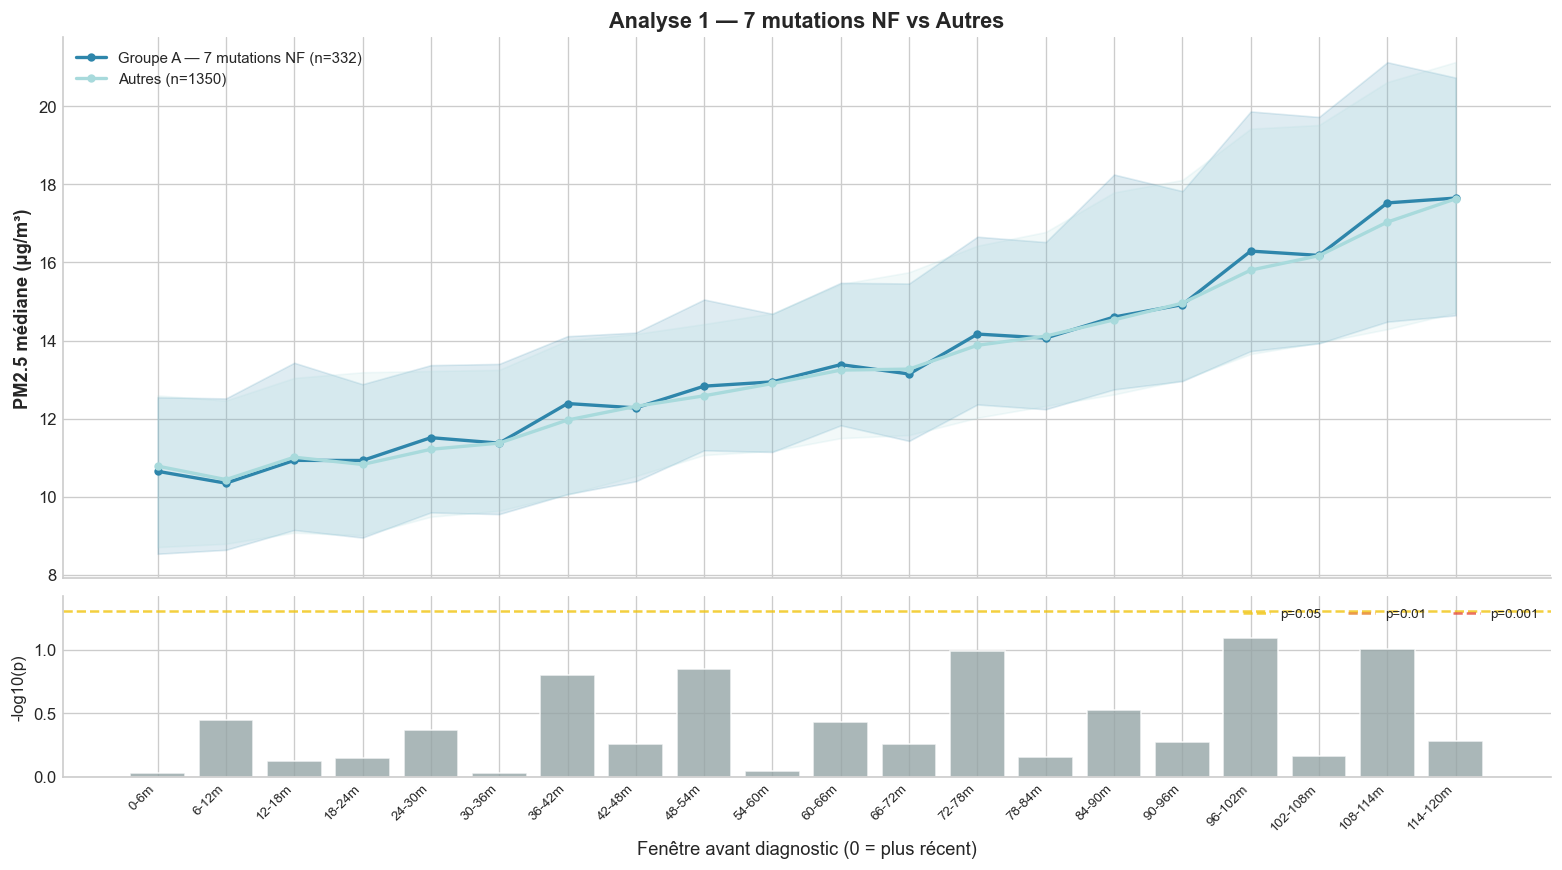

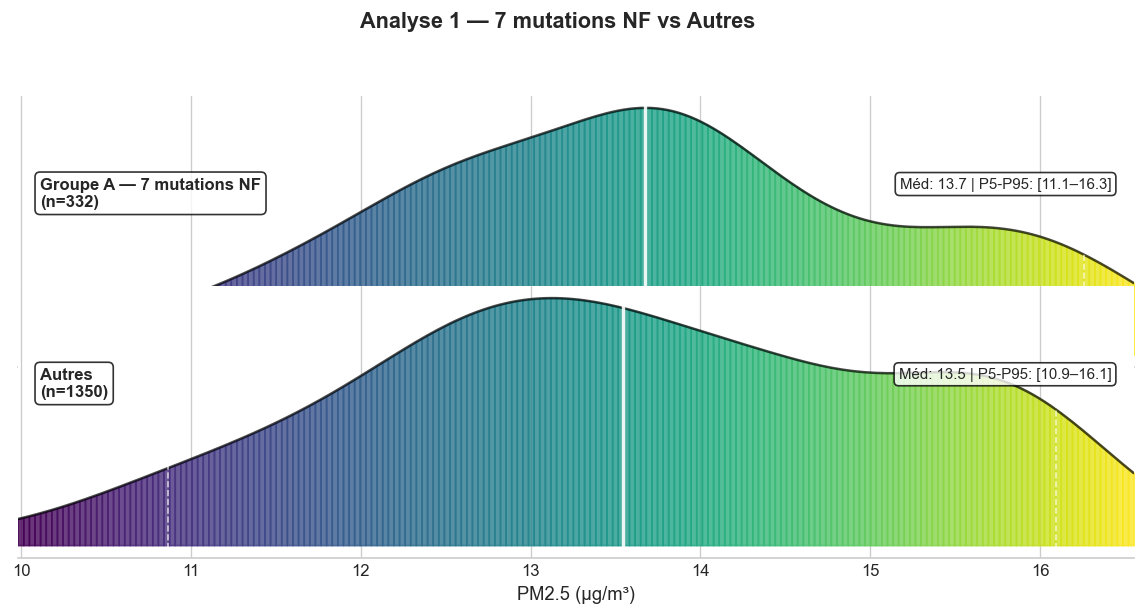

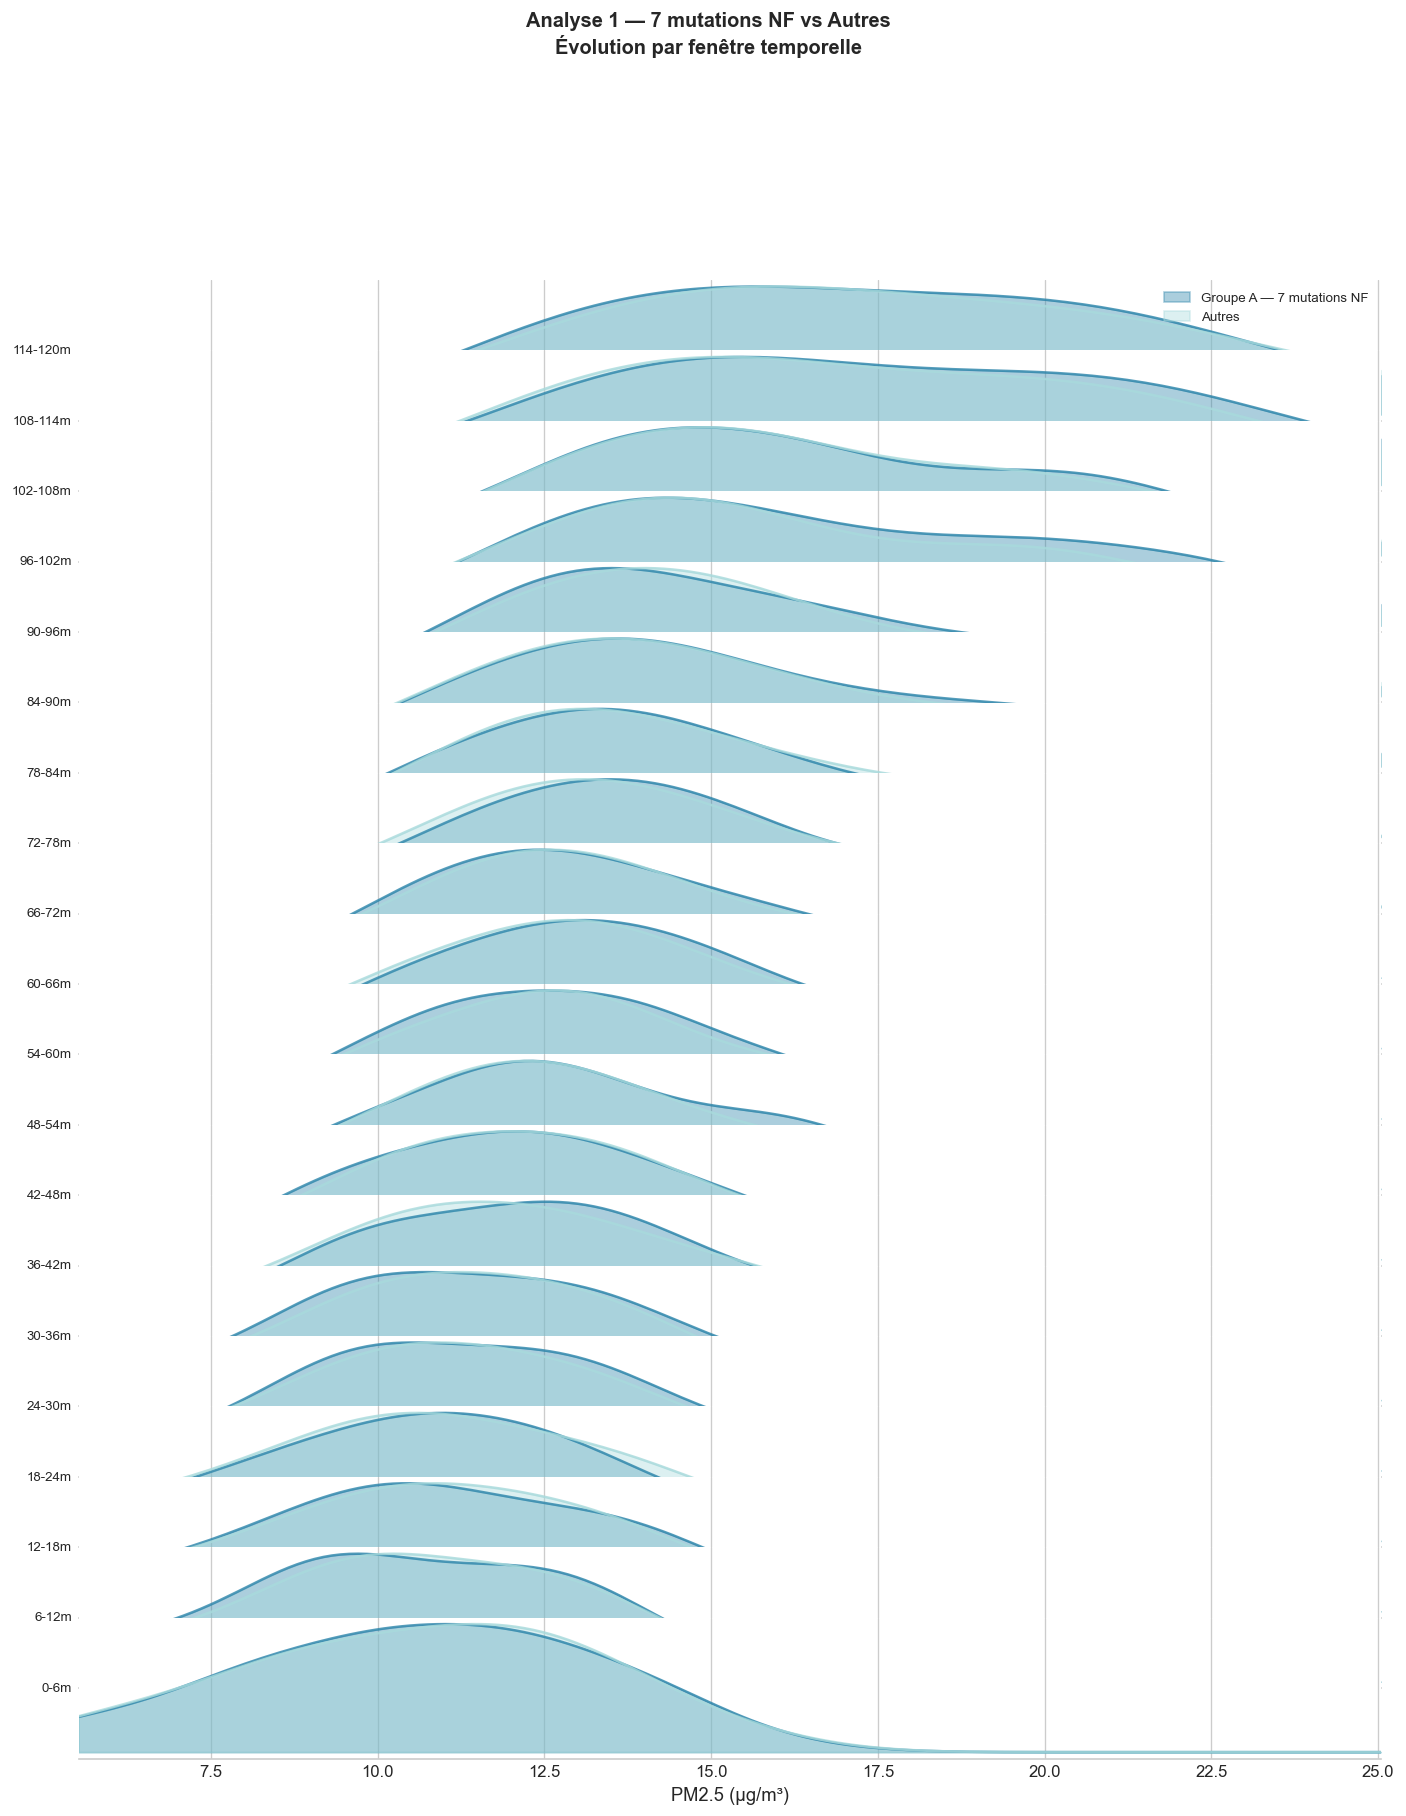


  Analyse 2 — Exposés vs Non exposés
  📊 Effectifs: 1682
     - Non exposé: 241
     - Exposé (Faible→Très forte): 1441


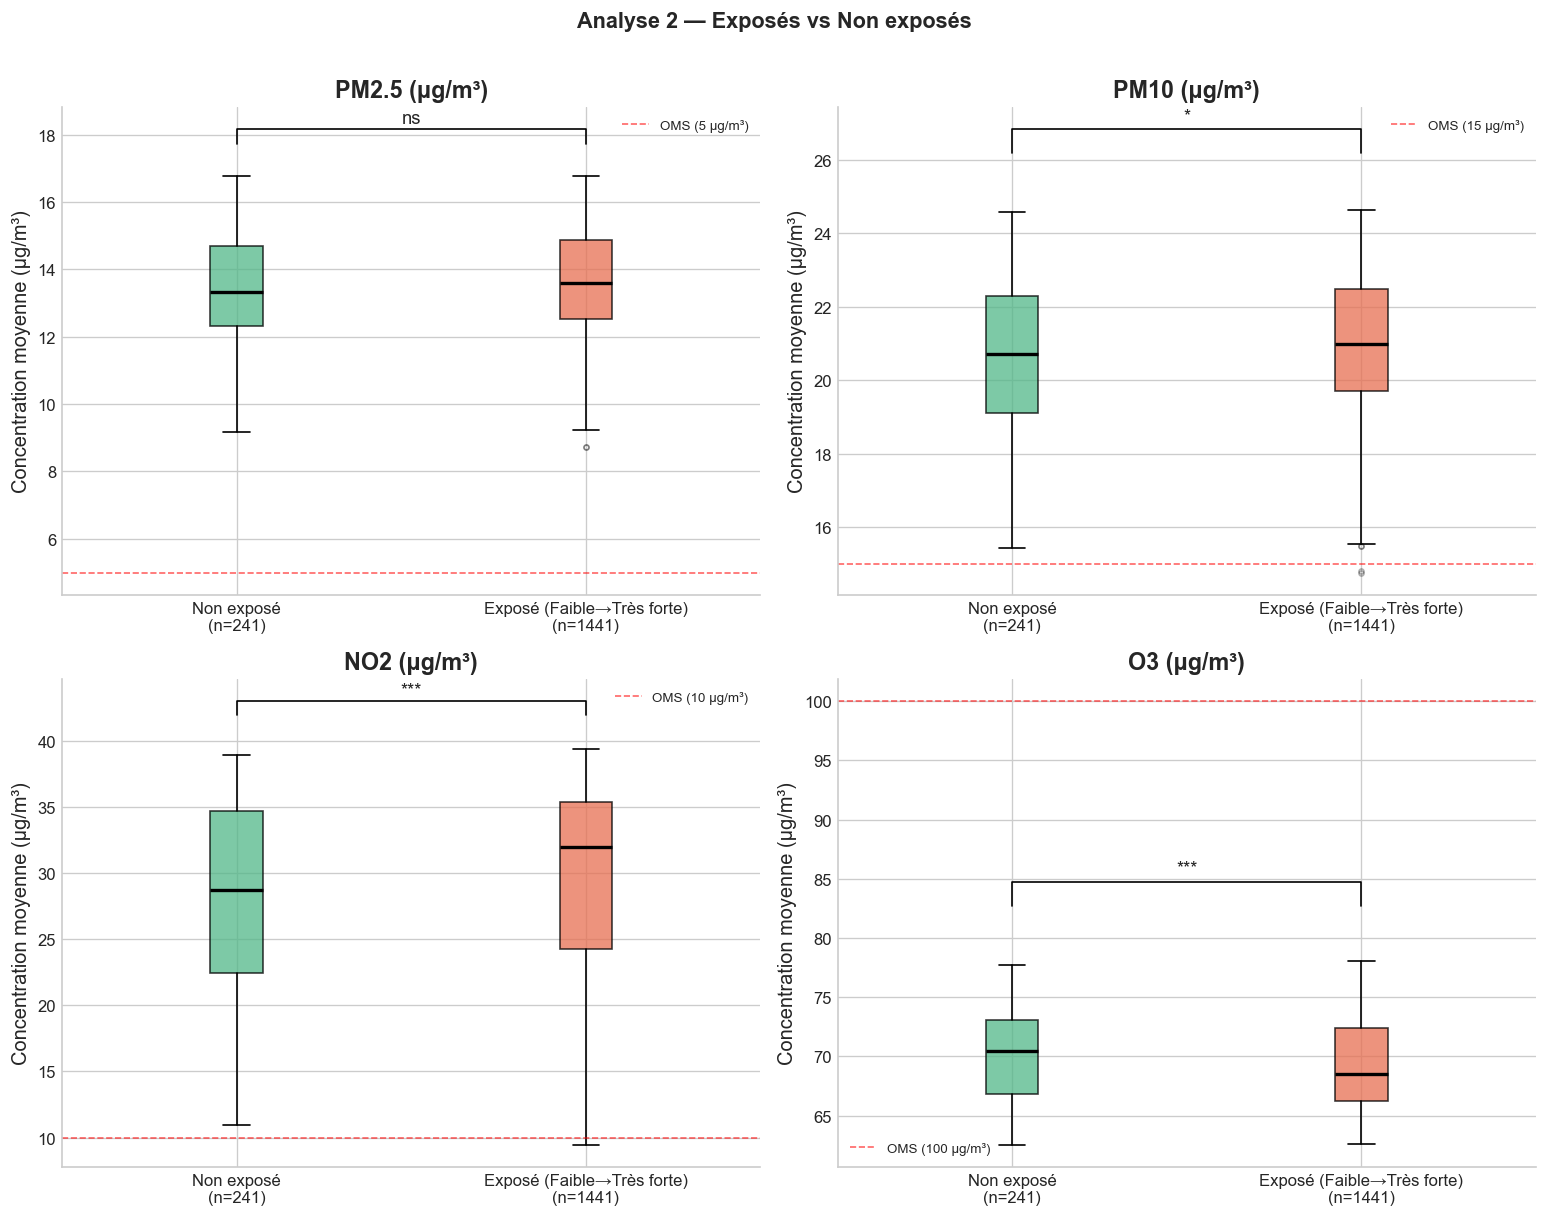

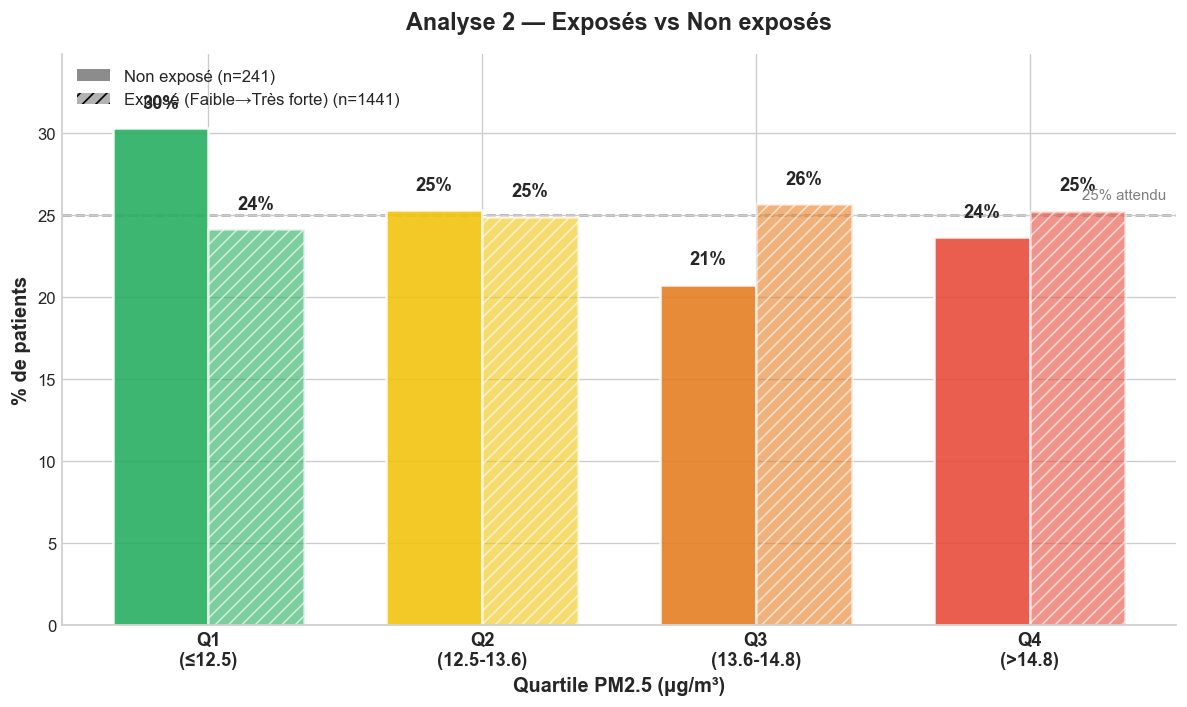


📊 Tests Mann-Whitney par fenêtre temporelle :
Fenêtre        Médiane G1   Médiane G2      p-value    Signif.
----------------------------------------------------------------------
0-6m                10.90        10.72        0.721         ns
6-12m                9.79        10.53       0.0167          *
12-18m              10.84        11.01        0.364         ns
18-24m              10.90        10.83        0.421         ns
24-30m              11.11        11.27        0.293         ns
30-36m              10.76        11.48       0.0061         **
36-42m              11.91        12.04        0.671         ns
42-48m              12.05        12.33        0.131         ns
48-54m              12.56        12.65        0.606         ns
54-60m              12.25        12.98       0.0016         **
60-66m              13.56        13.24        0.384         ns
66-72m              12.97        13.30        0.244         ns
72-78m              13.40        13.99        0.322         ns


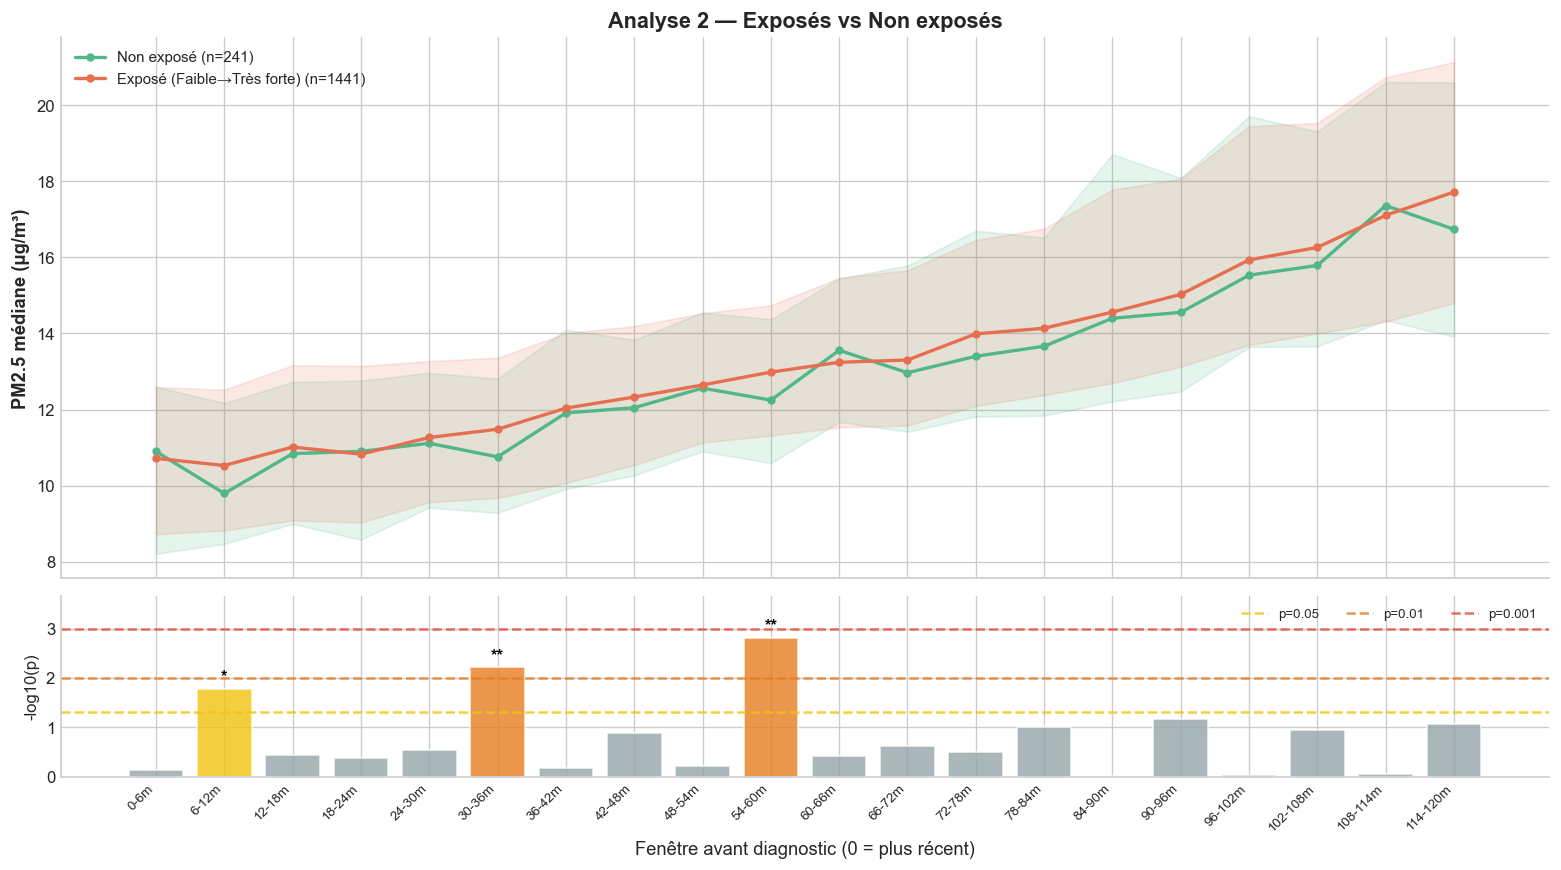

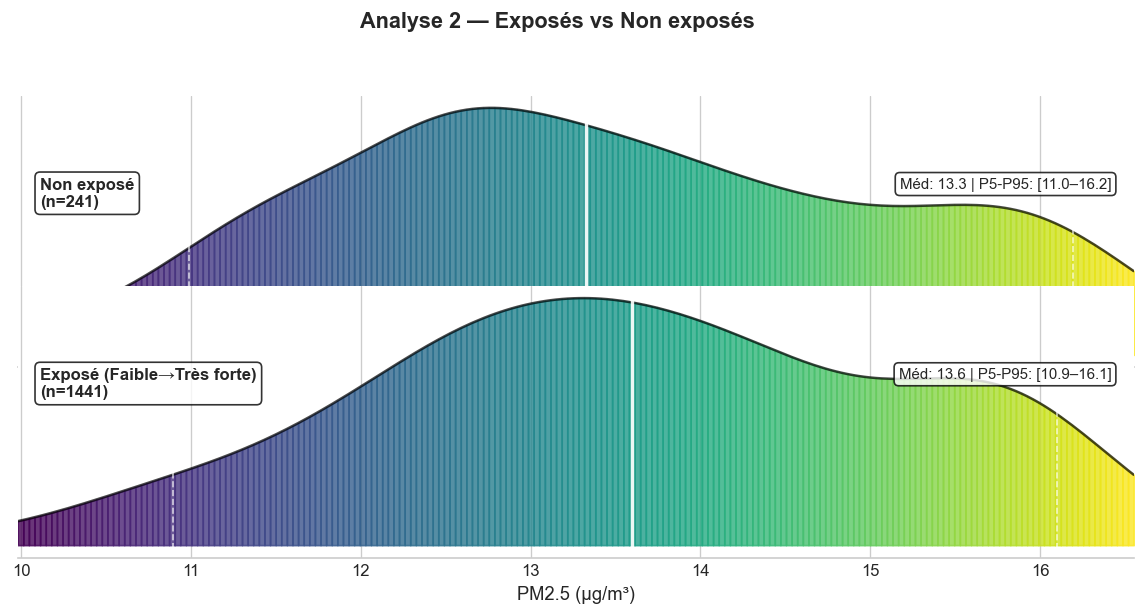

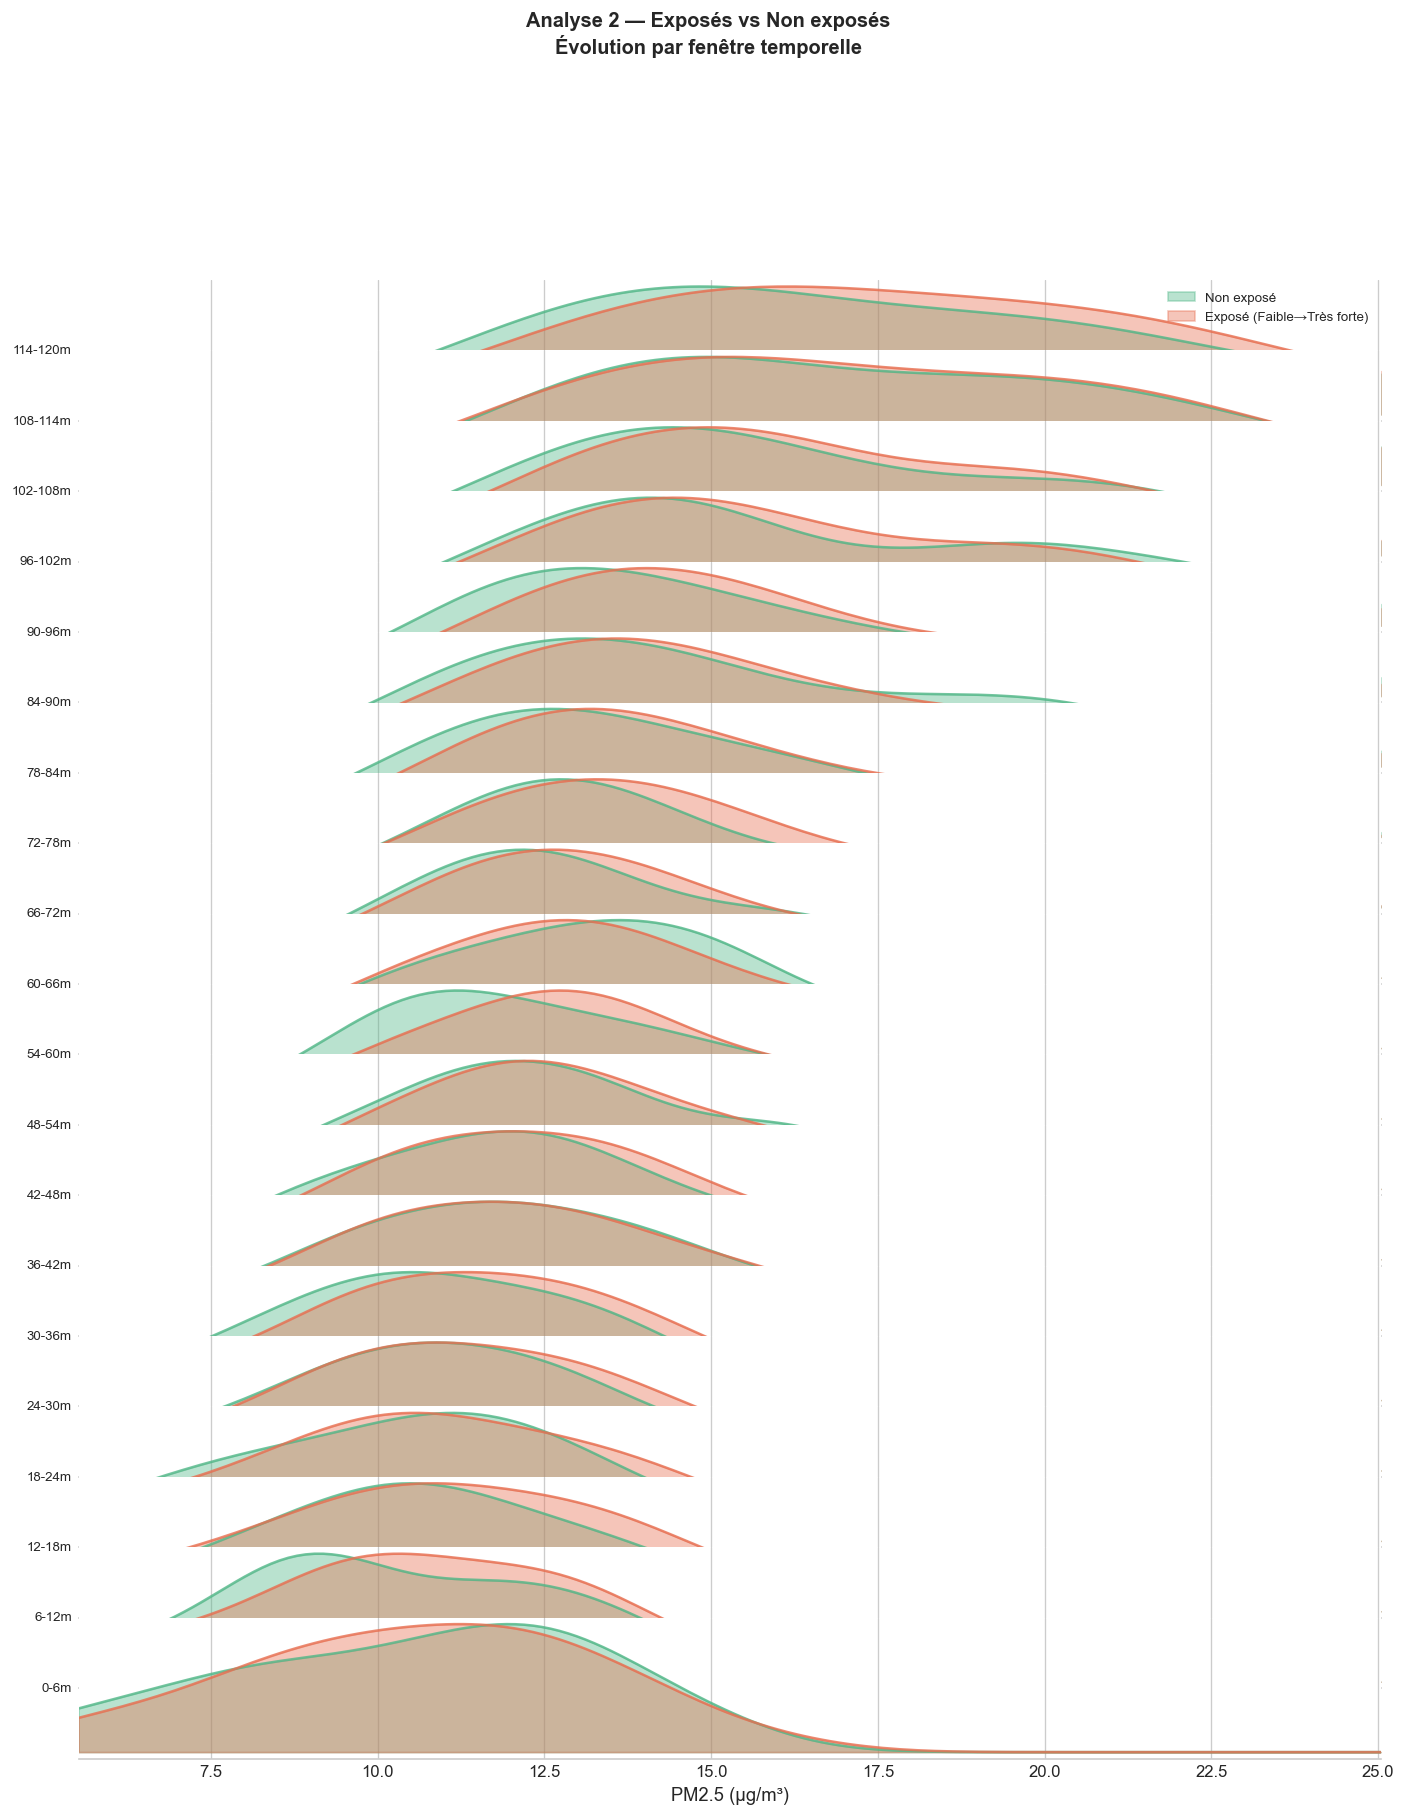


  Analyse 3 — Non-fumeurs + Fumeurs légers (PA≤5) vs Fumeurs modérés/forts
  📊 Effectifs: 1682
     - Non-fumeur / Fumeur léger (PA≤5): 283
     - Fumeur modéré/fort (PA>5): 1399


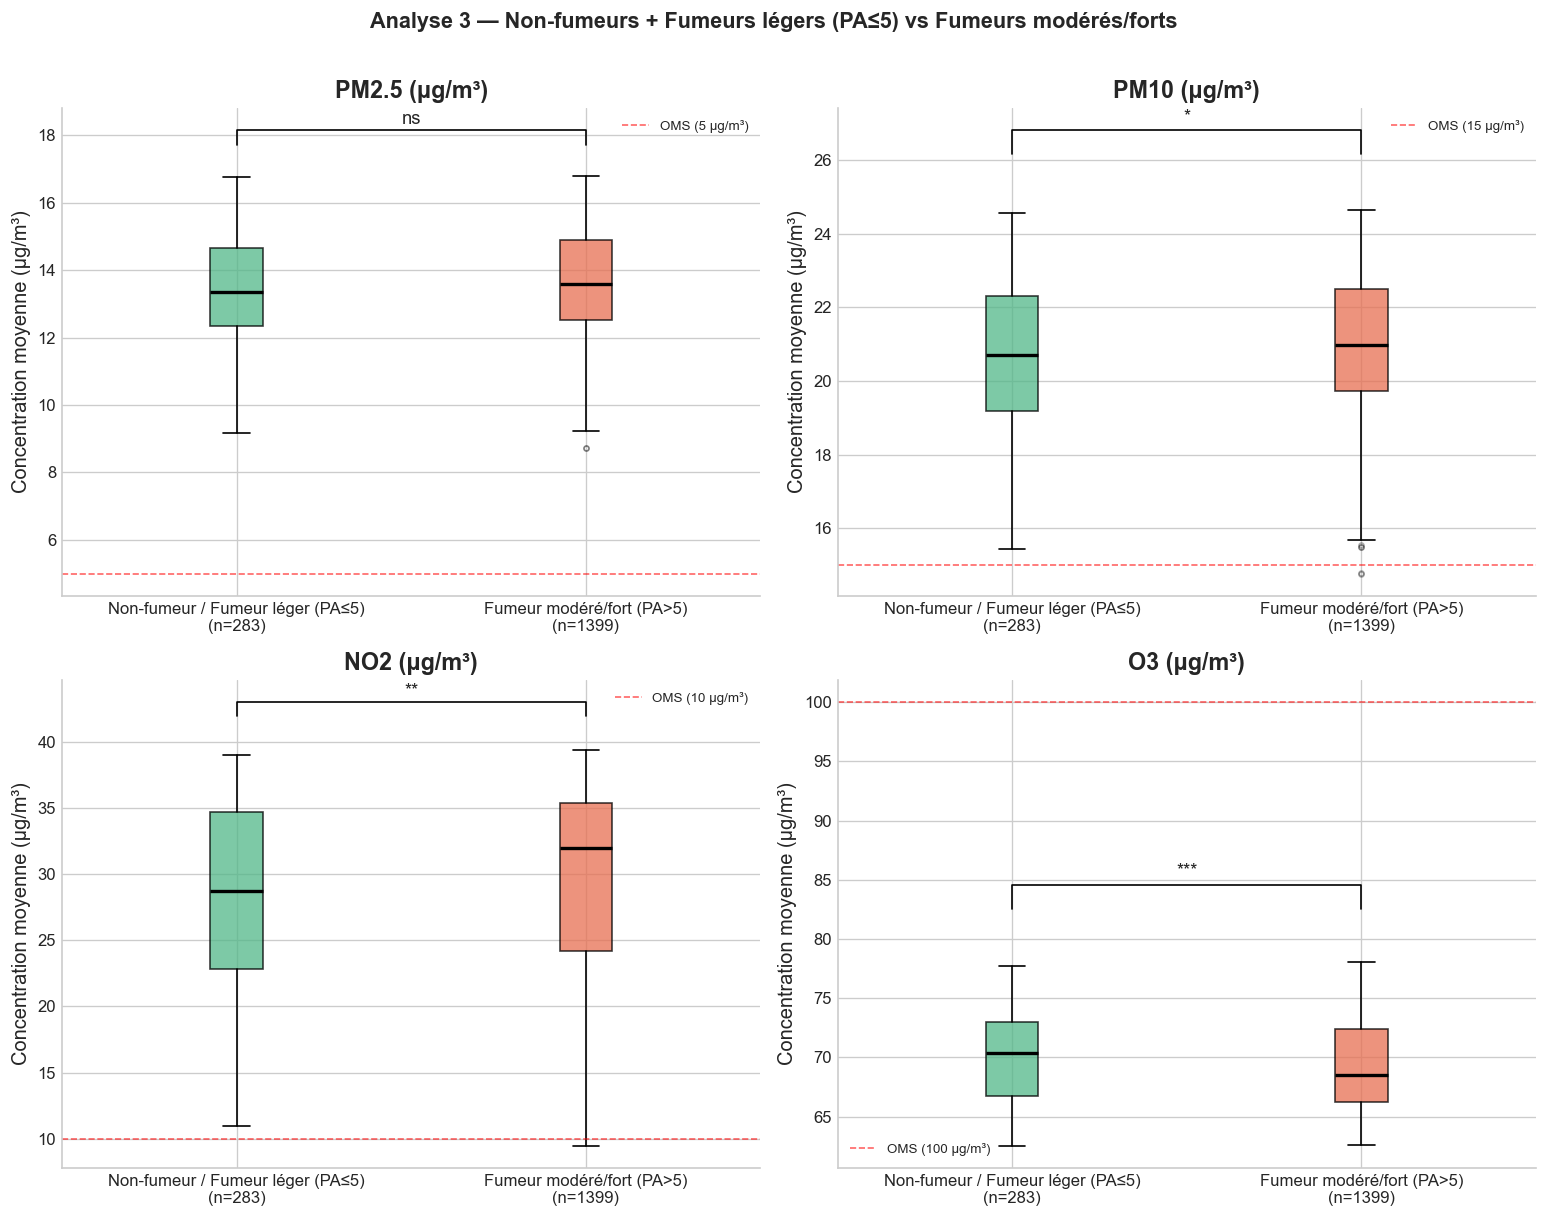

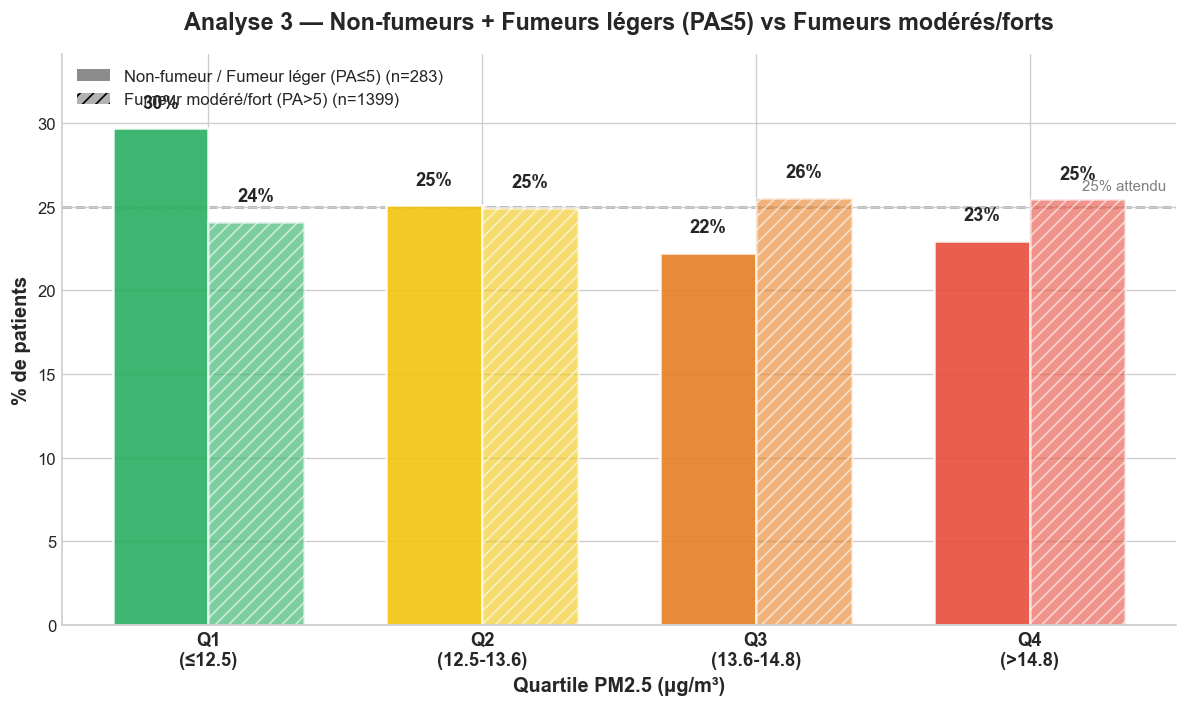


📊 Tests Mann-Whitney par fenêtre temporelle :
Fenêtre        Médiane G1   Médiane G2      p-value    Signif.
----------------------------------------------------------------------
0-6m                10.83        10.75        0.477         ns
6-12m                9.80        10.53       0.0275          *
12-18m              10.89        11.01        0.347         ns
18-24m              10.96        10.82        0.618         ns
24-30m              11.11        11.27        0.260         ns
30-36m              10.76        11.48       0.0044         **
36-42m              12.07        12.02        0.867         ns
42-48m              12.11        12.32        0.384         ns
48-54m              12.56        12.66        0.504         ns
54-60m              12.29        12.98       0.0012         **
60-66m              13.50        13.24        0.414         ns
66-72m              13.13        13.30        0.287         ns
72-78m              13.45        14.02        0.195         ns


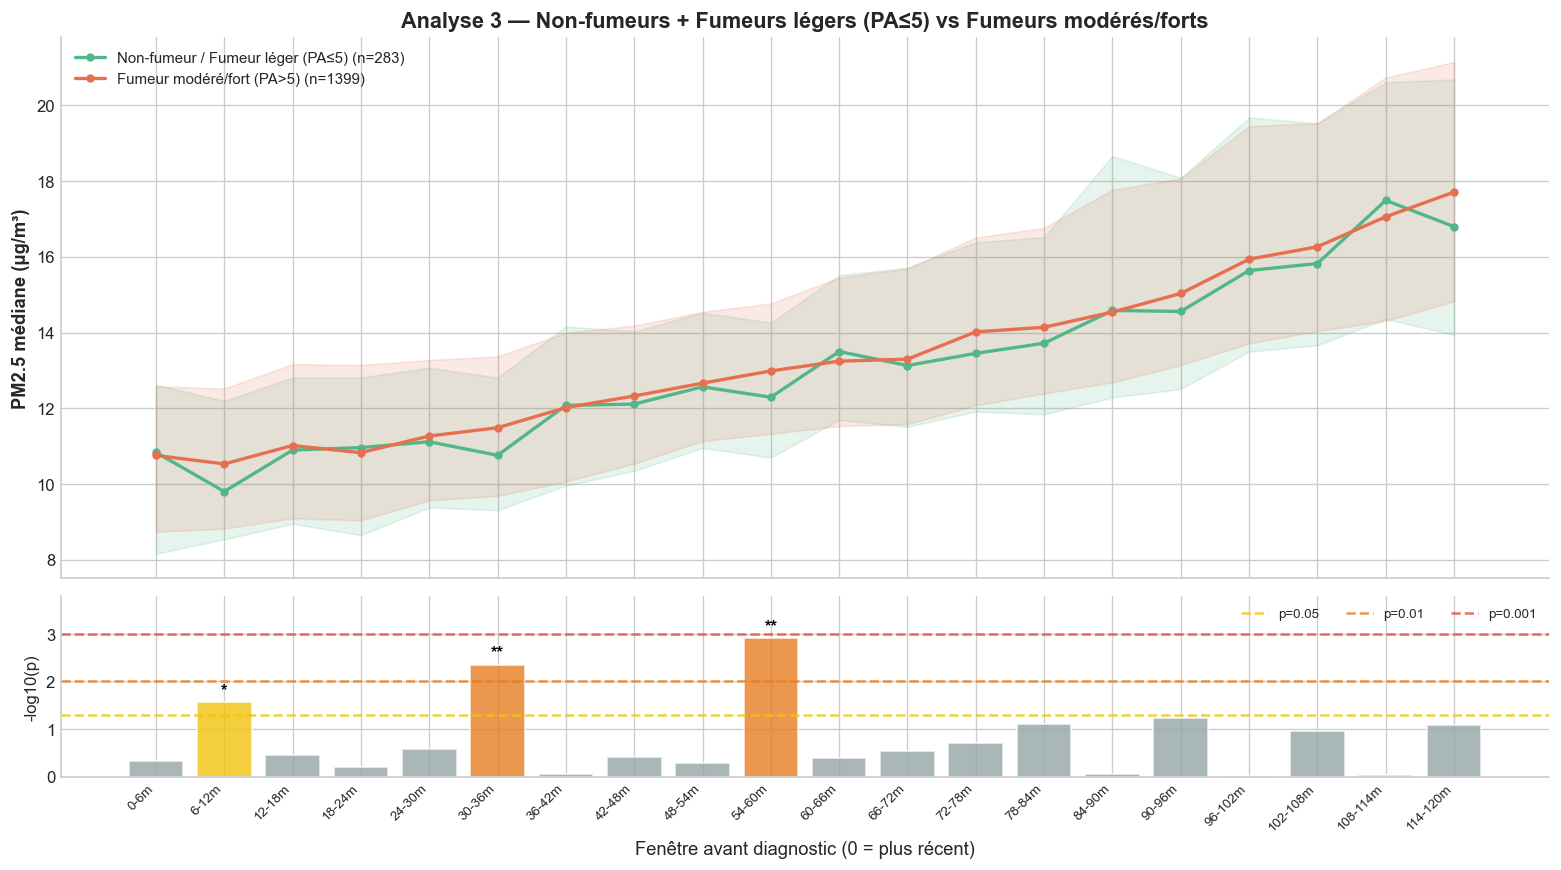

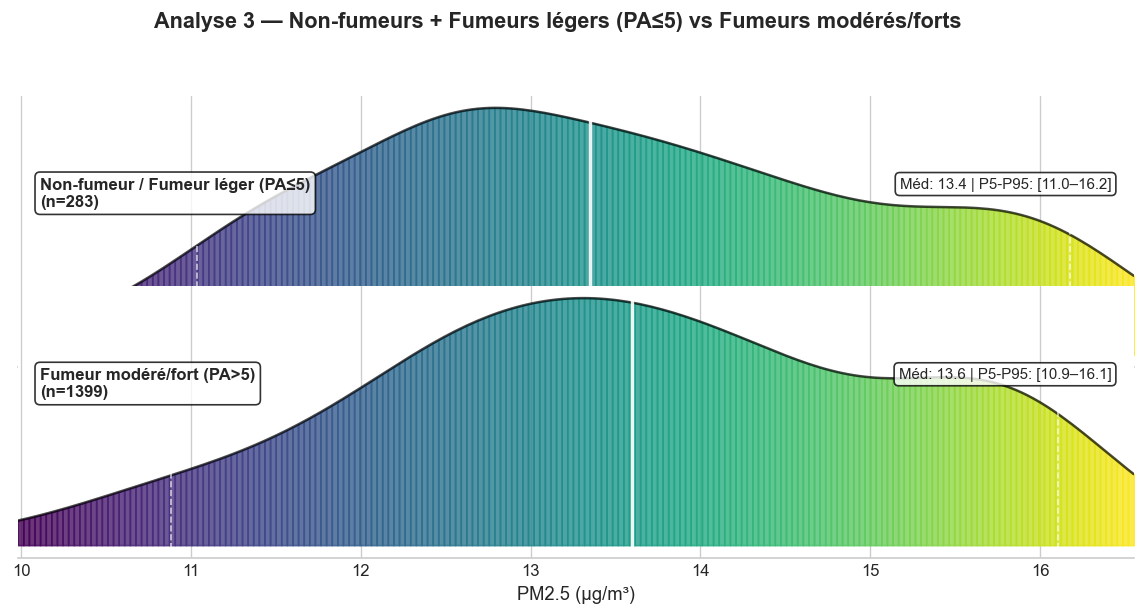

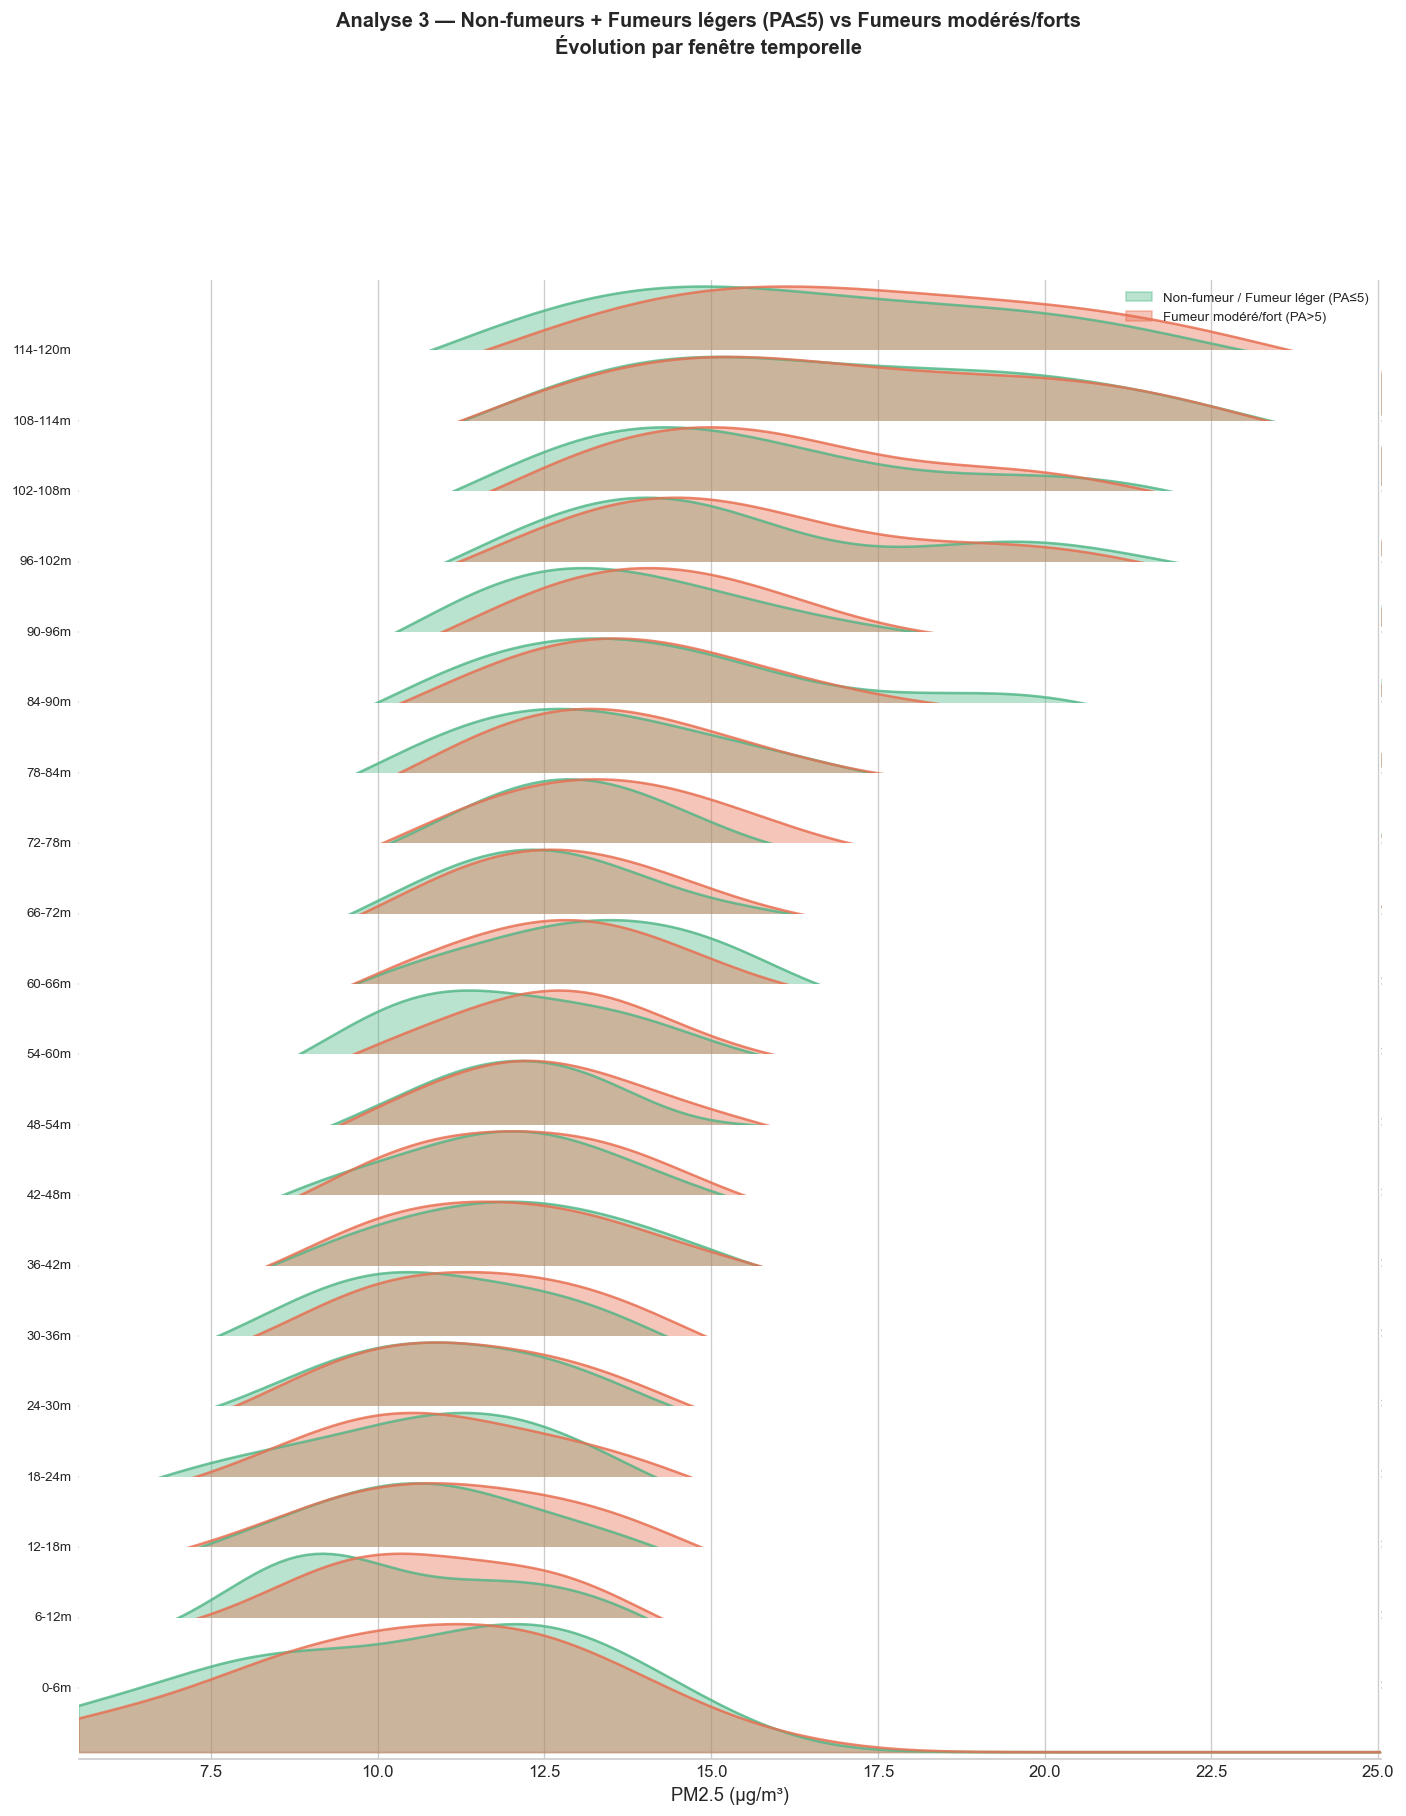


  Analyse 4 — Mutations NF + Non-fumeurs BRAF/KRAS vs Autres
  📊 Effectifs: 1682
     - Mut NF + BRAF/KRAS non-fumeurs: 350
     - Autres: 1332


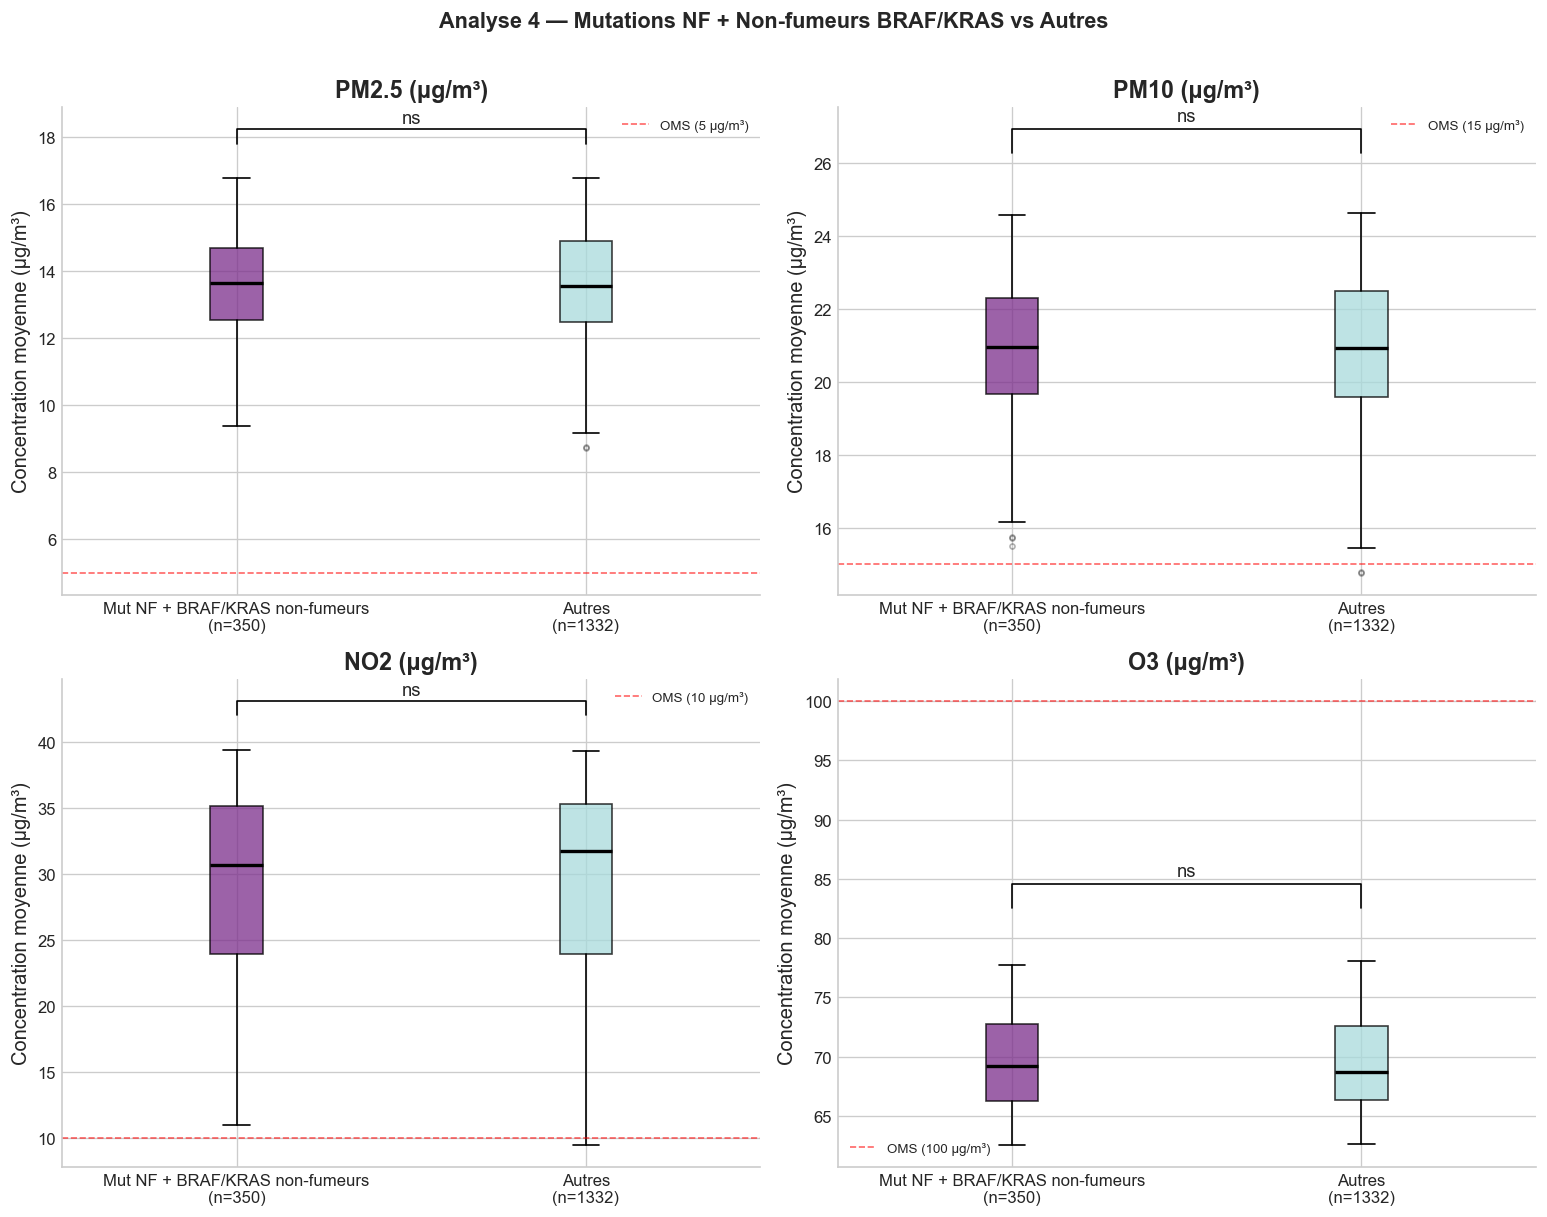

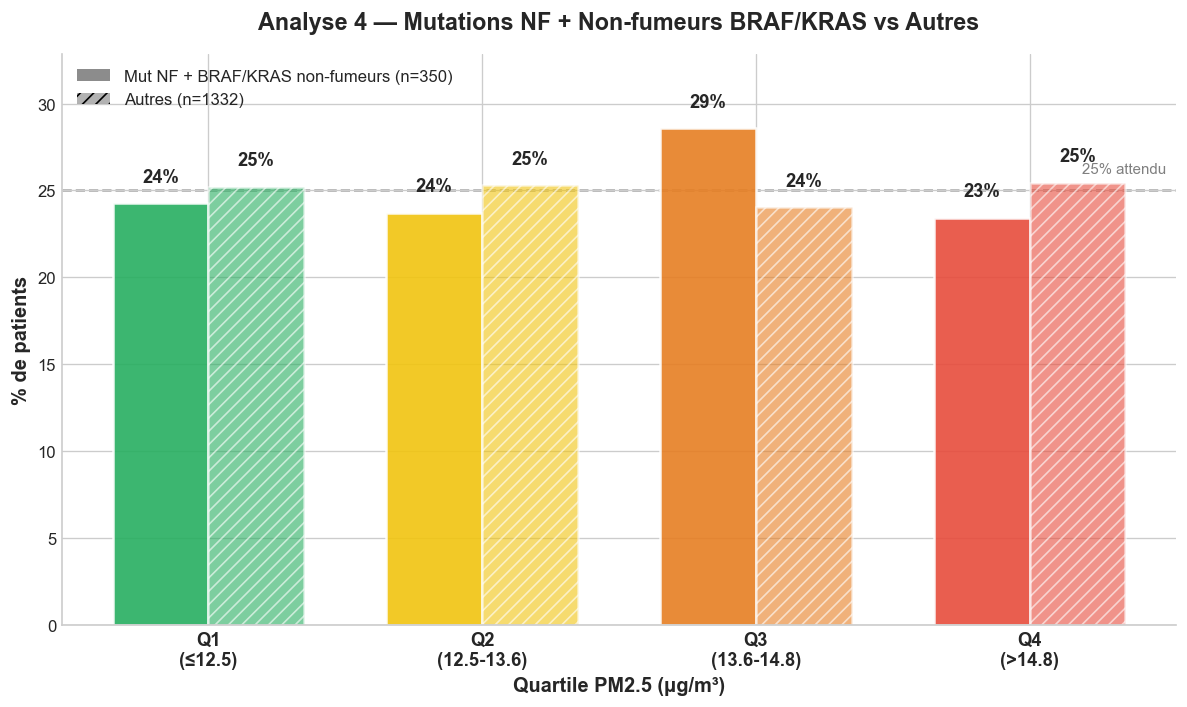


📊 Tests Mann-Whitney par fenêtre temporelle :
Fenêtre        Médiane G1   Médiane G2      p-value    Signif.
----------------------------------------------------------------------
0-6m                10.66        10.78        0.803         ns
6-12m               10.22        10.47        0.143         ns
12-18m              10.91        11.01        0.893         ns
18-24m              10.83        10.84        0.450         ns
24-30m              11.48        11.21        0.330         ns
30-36m              11.29        11.39        0.830         ns
36-42m              12.30        11.99        0.211         ns
42-48m              12.19        12.32        0.267         ns
48-54m              12.83        12.59        0.106         ns
54-60m              12.74        12.95        0.424         ns
60-66m              13.36        13.25        0.426         ns
66-72m              13.13        13.28        0.378         ns
72-78m              14.15        13.88        0.087         ns


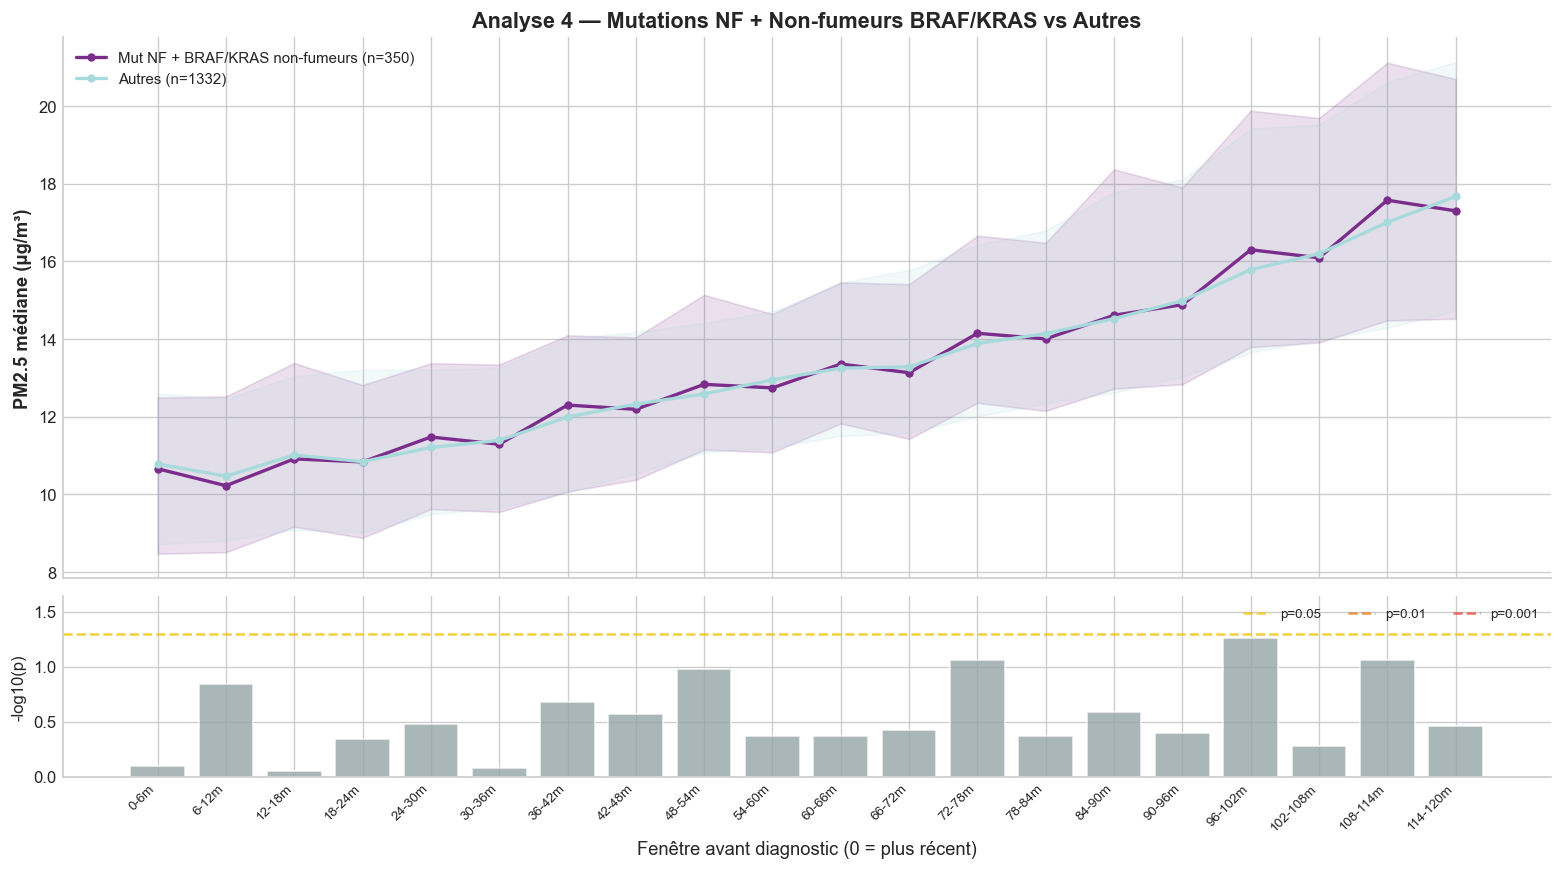

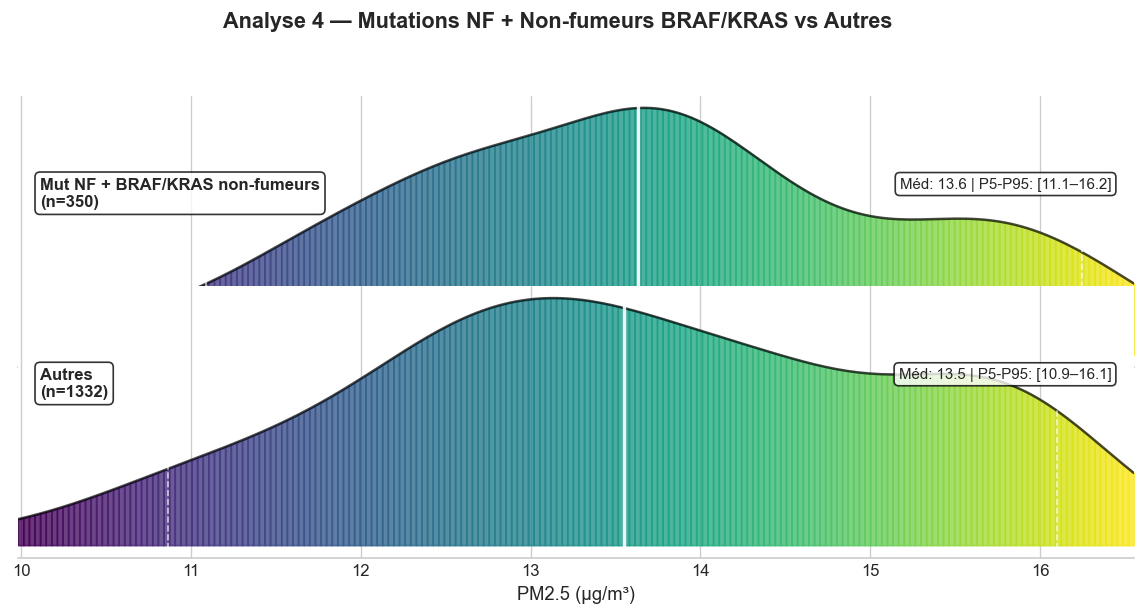

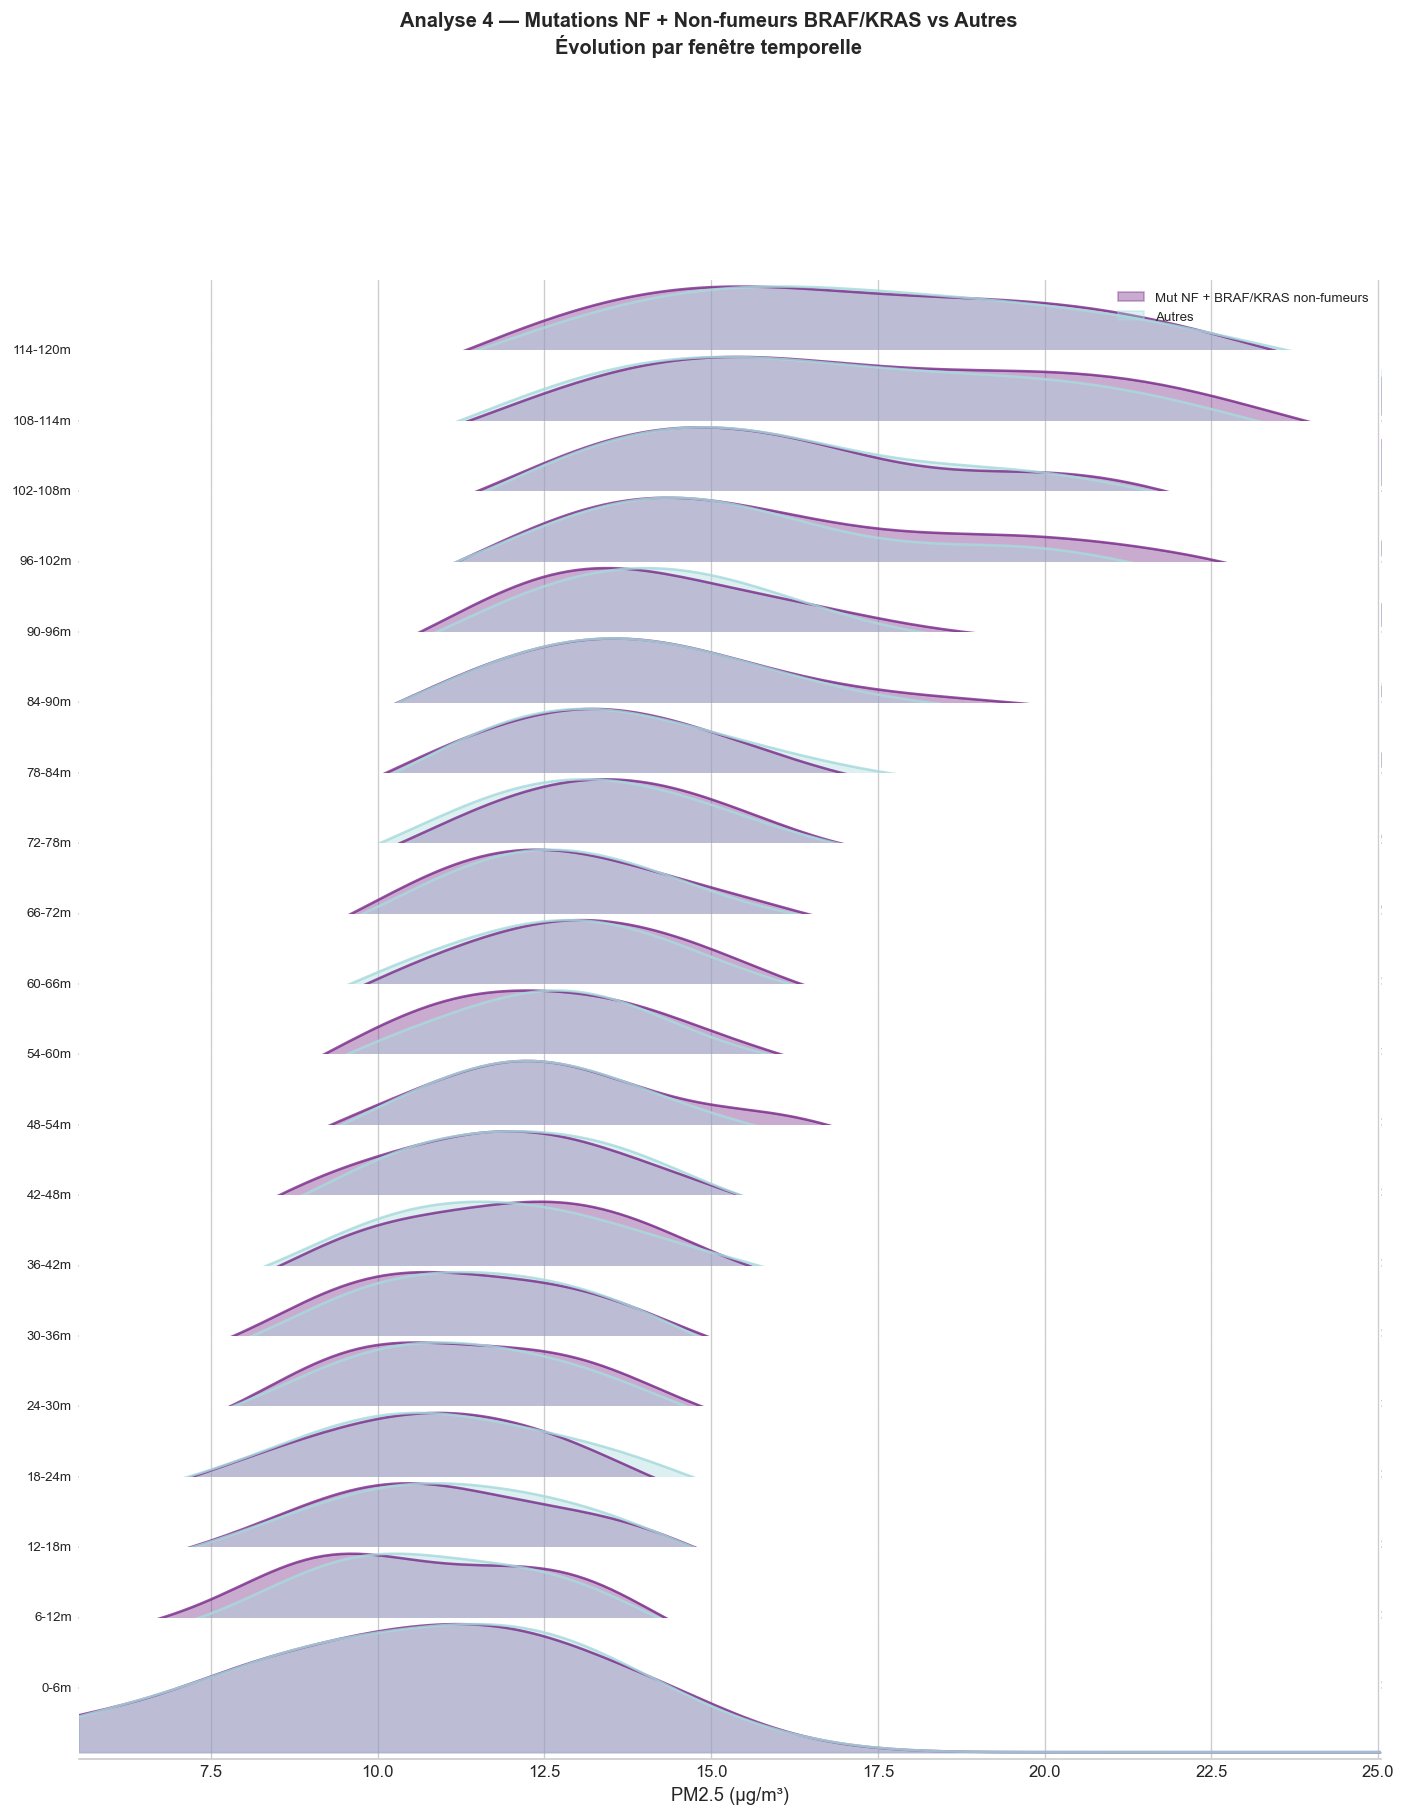

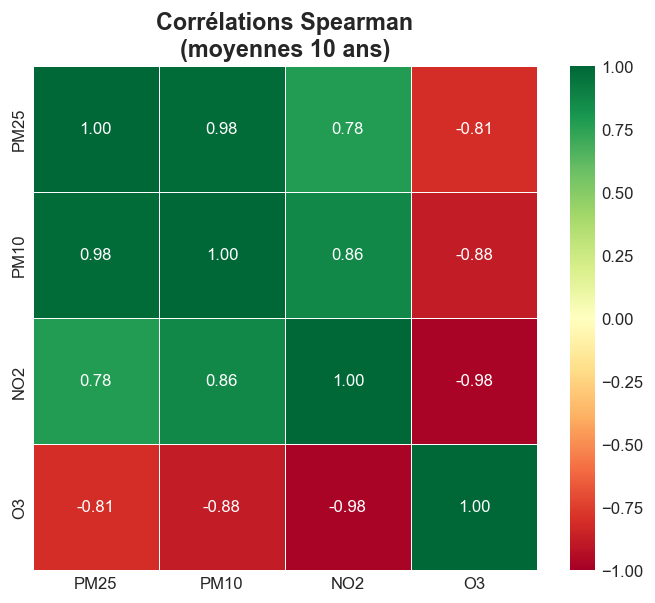

✅ Export : figures_stats/stats_desc_4analyses.xlsx


In [ ]:
# =============================================================================
# STATS DESCRIPTIVES — 4 STRATIFICATIONS (VERSION FINALE)
# Adapté à la structure exacte du fichier LUNGCANCAIR
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, fisher_exact
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ---------------------------------------------------------------------------
# CONSTANTES
# ---------------------------------------------------------------------------

# Catégories d'exposition tabagique (paquets-années)
EXPO_NON_EXPOSE = {'non exposé', 'non-fumeur', 'jamais fumé', 'never smoker', 'non exposã©'}
EXPO_FAIBLE     = {'faible (1-10)'}
EXPO_MODEREE    = {'modérée (10-20)', 'modã©rã©e (10-20)'}
EXPO_FORTE      = {'forte (20-40)'}
EXPO_TRES_FORTE = {'très forte (>40)', 'trã¨s forte (>40)'}
EXPO_EXPOSE     = EXPO_FAIBLE | EXPO_MODEREE | EXPO_FORTE | EXPO_TRES_FORTE

# Seuil paquets-années pour fumeur léger
SEUIL_PA_LEGER = 5  # PA <= 5

# Mutations
MUTATIONS_NF_7 = ['EGFR', 'ALK', 'ROS1', 'RET', 'NTRK', 'ERBB2', 'MET']
MUTATIONS_F    = ['KRAS', 'BRAF', 'TP53']

# Polluants
POLLUANTS_STATS = ['PM25', 'PM10', 'NO2', 'O3']
POLLUANTS_LABELS_STATS = {
    'PM25': 'PM2.5 (μg/m³)',
    'PM10': 'PM10 (μg/m³)',
    'NO2':  'NO2 (μg/m³)',
    'O3':   'O3 (μg/m³)',
}

# Fenêtres temporelles - format avec tiret comme dans vos données
FENETRES_TEMPORELLES = [
    '0-6m', '6-12m', '12-18m', '18-24m', '24-30m', '30-36m',
    '36-42m', '42-48m', '48-54m', '54-60m', '60-66m', '66-72m',
    '72-78m', '78-84m', '84-90m', '90-96m', '96-102m', '102-108m',
    '108-114m', '114-120m'
]

# Palette de couleurs
COULEURS_STATS = {
    'Groupe A — 7 mutations NF': '#2E86AB',
    'Autres':                    '#A8DADC',
    'Non exposé':                '#52B788',
    'Exposé (Faible→Très forte)':'#E76F51',
    'Non-fumeur / Fumeur léger (PA≤5)': '#52B788',
    'Non-fumeur / Fumeur léger': '#52B788',
    'Fumeur modéré/fort (PA>5)': '#E76F51',
    'Fumeur modéré/fort':        '#E76F51',
    'Mut NF + BRAF/KRAS non-fumeurs': '#7B2D8B',
    'Groupe élargi pollution':   '#7B2D8B',
    'Contrôle':                  '#BBBBBB',
}


# ---------------------------------------------------------------------------
# UTILITAIRES STATISTIQUES
# ---------------------------------------------------------------------------

def mediane_iqr(s, dec=1):
    """Médiane [Q25–Q75]."""
    s = s.dropna()
    if len(s) == 0:
        return 'NA'
    f = f'{{:.{dec}f}}'
    return f'{f.format(np.median(s))} [{f.format(np.percentile(s, 25))}–{f.format(np.percentile(s, 75))}]'


def moy_et(s, dec=1):
    """Moyenne ± ET."""
    s = s.dropna()
    if len(s) == 0:
        return 'NA'
    f = f'{{:.{dec}f}}'
    return f'{f.format(np.mean(s))} ± {f.format(np.std(s))}'


def n_pct(s, val):
    """n (%) pour une valeur catégorielle."""
    total = s.notna().sum()
    if total == 0:
        return 'NA'
    n = (s == val).sum()
    return f'{n} ({n / total * 100:.1f}%)'


def formater_p(p):
    if pd.isna(p):
        return 'NA'
    return '<0.001' if p < 0.001 else f'{p:.3f}'


def test_kw(df, col, col_g, groupes):
    """Kruskal-Wallis avec gestion des erreurs."""
    if col not in df.columns:
        return 'NA'
    
    ss = [df.loc[df[col_g] == g, col].dropna().values for g in groupes]
    ss = [s for s in ss if len(s) > 1]
    
    if len(ss) < 2:
        return 'NA'
    
    all_values = np.concatenate(ss)
    if len(np.unique(all_values)) <= 1:
        return 'NA (var=0)'
    
    try:
        _, p = kruskal(*ss)
        return formater_p(p)
    except Exception:
        return 'NA'


def test_chi2(df, col, col_g):
    """Chi2 ou Fisher."""
    if col not in df.columns:
        return 'NA'
    sub = df[[col, col_g]].dropna()
    if len(sub) == 0:
        return 'NA'
    table = pd.crosstab(sub[col], sub[col_g])
    
    if table.shape[0] < 2 or table.shape[1] < 2:
        return 'NA'
    
    try:
        _, p, _, expected = chi2_contingency(table)
        if table.shape == (2, 2) and (expected < 5).any():
            _, p = fisher_exact(table)
            return formater_p(p) + ' (F)'
        return formater_p(p)
    except:
        return 'NA'


def etoiles(p):
    if pd.isna(p) or p >= 0.05:
        return 'ns'
    return '***' if p < 0.001 else ('**' if p < 0.01 else '*')


# ---------------------------------------------------------------------------
# DÉTECTION DES MUTATIONS
# ---------------------------------------------------------------------------

def porte_mutation(df, mut):
    """
    Détecte si le patient porte une mutation.
    Gère le format 'positive', True, 1, 'Oui', etc.
    """
    col = f'mutation_{mut}'
    if col not in df.columns:
        return pd.Series(False, index=df.index)
    
    vals = df[col].astype(str).str.strip().str.lower()
    vals_positives = {'positive', 'true', '1', 'oui', 'yes', 'positif', 'muté', 'mutated'}
    
    return vals.isin(vals_positives)


# ---------------------------------------------------------------------------
# CONSTRUCTION DES 4 GROUPES D'ANALYSE
# ---------------------------------------------------------------------------

def construire_groupes_analyses(df):
    """
    Ajoute 4 colonnes de stratification :
    - groupe_A1 : 7 mutations NF vs Autres
    - groupe_A2 : Exposés vs Non exposés (tabac)
    - groupe_A3 : Non-fumeurs + Fumeurs légers (PA≤5) vs Fumeurs modérés/forts
    - groupe_A4 : Groupe élargi pollution vs Contrôle
    """
    df = df.copy()

    # Normalisation des colonnes textuelles
    if 'exposition_tabagique' in df.columns:
        expo_low = df['exposition_tabagique'].astype(str).str.strip().str.lower()
    else:
        expo_low = pd.Series('', index=df.index)
    
    if 'statut_tabagique' in df.columns:
        statut_low = df['statut_tabagique'].astype(str).str.strip().str.lower()
    else:
        statut_low = pd.Series('', index=df.index)

    # ══════════════════════════════════════════════════════════════════════
    # ANALYSE 1 : 7 mutations NF vs Autres
    # ══════════════════════════════════════════════════════════════════════
    
    if 'a_mutation_non_fumeur' in df.columns:
        masque_mut_nf = df['a_mutation_non_fumeur'] == True
    else:
        masque_mut_nf = pd.Series(False, index=df.index)
        for mut in MUTATIONS_NF_7:
            masque_mut_nf = masque_mut_nf | porte_mutation(df, mut)
        df['a_mutation_non_fumeur'] = masque_mut_nf
    
    df['groupe_A1'] = np.where(
        df['a_mutation_non_fumeur'] == True,
        'Groupe A — 7 mutations NF',
        'Autres'
    )

    # ══════════════════════════════════════════════════════════════════════
    # ANALYSE 2 : Exposés vs Non exposés
    # ══════════════════════════════════════════════════════════════════════
    
    def mapper_expo(val):
        val = str(val).strip().lower()
        if val in EXPO_NON_EXPOSE:
            return 'Non exposé'
        if val in EXPO_EXPOSE:
            return 'Exposé (Faible→Très forte)'
        return None
    
    df['groupe_A2'] = expo_low.apply(mapper_expo)

    # ══════════════════════════════════════════════════════════════════════
    # ANALYSE 3 : Non-fumeurs + Fumeurs légers (PA ≤ 5) vs Fumeurs modérés/forts
    # ══════════════════════════════════════════════════════════════════════
    
    # Non-fumeur = statut "jamais fumé" ou exposition "non exposé"
    est_non_fumeur = (
        statut_low.isin({'jamais fumé', 'never smoker', 'non-fumeur', 'jamais', 'non fumeur', 'never'}) |
        expo_low.isin(EXPO_NON_EXPOSE)
    )
    
    if 'paquet_annee' in df.columns:
        pa = pd.to_numeric(df['paquet_annee'], errors='coerce')
        
        # Fumeur léger : PA > 0 ET PA <= seuil
        est_fumeur_leger = (pa > 0) & (pa <= SEUIL_PA_LEGER)
        
        # Fumeur modéré/fort : PA > seuil
        est_fumeur_fort = pa > SEUIL_PA_LEGER
        
        # Groupe "profil pollution" = Non-fumeurs OU Fumeurs légers
        masque_profil_pollution = est_non_fumeur | est_fumeur_leger
        
        df['groupe_A3'] = np.where(
            masque_profil_pollution, 'Non-fumeur / Fumeur léger (PA≤5)',
            np.where(est_fumeur_fort, 'Fumeur modéré/fort (PA>5)', None)
        )
        
        # Debug A3
        n_nf = est_non_fumeur.sum()
        n_leger = est_fumeur_leger.sum()
        n_fort = est_fumeur_fort.sum()
        print(f"\n   📊 Debug Analyse 3:")
        print(f"      - Non-fumeurs : {n_nf}")
        print(f"      - Fumeurs légers (PA ≤ {SEUIL_PA_LEGER}) : {n_leger}")
        print(f"      - Fumeurs modérés/forts (PA > {SEUIL_PA_LEGER}) : {n_fort}")
    else:
        # Fallback basé sur exposition_tabagique uniquement
        masque_profil_pollution = expo_low.isin(EXPO_NON_EXPOSE | EXPO_FAIBLE)
        masque_fort = expo_low.isin(EXPO_MODEREE | EXPO_FORTE | EXPO_TRES_FORTE)
        
        df['groupe_A3'] = np.where(
            masque_profil_pollution, 'Non-fumeur / Fumeur léger',
            np.where(masque_fort, 'Fumeur modéré/fort', None)
        )

    # ══════════════════════════════════════════════════════════════════════
    # ANALYSE 4 : Groupe élargi pollution vs Contrôle
    # ══════════════════════════════════════════════════════════════════════
    
    # Non-fumeur strict
    non_fumeur_strict = statut_low.isin({
        'jamais fumé', 'never smoker', 'non-fumeur', 'jamais', 
        'non fumeur', 'never', 'non-fumeur actif'
    })
    
    # BRAF/KRAS positifs
    porte_braf = porte_mutation(df, 'BRAF')
    porte_kras = porte_mutation(df, 'KRAS')
    
    # Debug
    n_braf = porte_braf.sum()
    n_kras = porte_kras.sum()
    n_nf_strict = non_fumeur_strict.sum()
    
    print(f"\n   📊 Debug Analyse 4:")
    print(f"      - BRAF+ : {n_braf}")
    print(f"      - KRAS+ : {n_kras}")
    print(f"      - Non-fumeurs stricts : {n_nf_strict}")
    
    # BRAF/KRAS chez non-fumeurs
    masque_braf_kras_nf = non_fumeur_strict & (porte_braf | porte_kras)
    n_braf_kras_nf = masque_braf_kras_nf.sum()
    print(f"      - BRAF/KRAS chez non-fumeurs : {n_braf_kras_nf}")
    
    # Groupe "Profil pollution" = 7 mutations NF OU (BRAF/KRAS chez non-fumeurs)
    masque_A4 = (df['a_mutation_non_fumeur'] == True) | masque_braf_kras_nf
    
    df['groupe_A4'] = np.where(masque_A4, 'Mut NF + BRAF/KRAS non-fumeurs', 'Autres')
    
    # Différence avec A1
    n_a1 = (df['groupe_A1'] == 'Groupe A — 7 mutations NF').sum()
    n_a4 = (df['groupe_A4'] == 'Mut NF + BRAF/KRAS non-fumeurs').sum()
    print(f"      - Groupe A1 (7 mut NF) : {n_a1}")
    print(f"      - Groupe A4 (élargi)   : {n_a4} (+{n_a4 - n_a1} via BRAF/KRAS NF)")

    # ══════════════════════════════════════════════════════════════════════
    # RÉCAPITULATIF DES EFFECTIFS
    # ══════════════════════════════════════════════════════════════════════
    
    print("\n" + "=" * 60)
    print("EFFECTIFS PAR ANALYSE")
    print("=" * 60)
    
    specs = [
        ('groupe_A1', 'Analyse 1 — 7 mutations NF vs Autres'),
        ('groupe_A2', 'Analyse 2 — Exposés vs Non exposés'),
        ('groupe_A3', f'Analyse 3 — Non-fumeurs + Fumeurs légers (PA≤{SEUIL_PA_LEGER}) vs Fumeurs modérés/forts'),
        ('groupe_A4', 'Analyse 4 — Mutations NF + Non-fumeurs BRAF/KRAS vs Autres'),
    ]
    
    for col, nom in specs:
        print(f"\n  {nom} :")
        vc = df[col].value_counts(dropna=False)
        for g, n in vc.items():
            pct = n / len(df) * 100
            g_str = str(g) if pd.notna(g) else 'Non classé (NaN)'
            print(f"    {g_str:<40} : {n:>5}  ({pct:.1f}%)")

    return df


# ---------------------------------------------------------------------------
# TABLEAU 1 — CARACTÉRISTIQUES DE LA COHORTE
# ---------------------------------------------------------------------------

def tableau1(df, col_g, groupes):
    """Tableau des caractéristiques démographiques et cliniques."""
    cols = ['Variable'] + groupes + ['Total', 'p-value']
    lignes = []
    N = len(df)

    def sep(titre):
        r = {c: '' for c in cols}
        r['Variable'] = f'── {titre}'
        lignes.append(r)

    def cont(label, col, dec=1):
        if col not in df.columns:
            return
        r = {'Variable': label}
        for g in groupes:
            r[g] = mediane_iqr(df.loc[df[col_g] == g, col], dec)
        r['Total'] = mediane_iqr(df[col], dec)
        r['p-value'] = test_kw(df, col, col_g, groupes)
        lignes.append(r)

    def cat(label, col, val=None, show_p=True):
        if col not in df.columns:
            return
        if val is None:
            r = {'Variable': label, 'Total': '',
                 'p-value': test_chi2(df, col, col_g) if show_p else ''}
            for g in groupes:
                r[g] = ''
            lignes.append(r)
            for v in sorted(df[col].dropna().unique(), key=str):
                cat(f'   {v}', col, v, False)
        else:
            r = {'Variable': label, 'p-value': ''}
            for g in groupes:
                r[g] = n_pct(df.loc[df[col_g] == g, col], val)
            r['Total'] = n_pct(df[col], val)
            lignes.append(r)

    # N
    r_n = {'Variable': 'N (%)', 'p-value': '—', 'Total': str(N)}
    for g in groupes:
        ng = (df[col_g] == g).sum()
        r_n[g] = f'{ng} ({ng / N * 100:.1f}%)'
    lignes.append(r_n)

    sep('Démographie')
    cont('Âge au diagnostic, médiane [IQR]', 'age_diagnostic')
    cat('Sexe', 'sexe')

    sep('Clinique')
    cat('Stade', 'stade')
    cat('Histologie groupe', 'histologie_groupe')

    sep('Tabagisme')
    cat('Statut tabagique', 'statut_tabagique')
    cat('Exposition tabagique', 'exposition_tabagique')
    cont('Paquets-années, médiane [IQR]', 'paquet_annee')

    sep('Mutations — signature non-fumeur (7 cibles)')
    for mut in MUTATIONS_NF_7:
        if porte_mutation(df, mut).any():
            n_pos = porte_mutation(df, mut).sum()
            r = {'Variable': f'{mut}+ (n={n_pos})'}
            for g in groupes:
                sub = df[df[col_g] == g]
                n_g = porte_mutation(sub, mut).sum()
                pct = n_g / len(sub) * 100 if len(sub) > 0 else 0
                r[g] = f'{n_g} ({pct:.1f}%)'
            r['Total'] = f'{n_pos} ({n_pos/len(df)*100:.1f}%)'
            r['p-value'] = ''
            lignes.append(r)

    sep('Mutations — signature fumeur (KRAS, BRAF, TP53)')
    for mut in MUTATIONS_F:
        if porte_mutation(df, mut).any():
            n_pos = porte_mutation(df, mut).sum()
            r = {'Variable': f'{mut}+ (n={n_pos})'}
            for g in groupes:
                sub = df[df[col_g] == g]
                n_g = porte_mutation(sub, mut).sum()
                pct = n_g / len(sub) * 100 if len(sub) > 0 else 0
                r[g] = f'{n_g} ({pct:.1f}%)'
            r['Total'] = f'{n_pos} ({n_pos/len(df)*100:.1f}%)'
            r['p-value'] = ''
            lignes.append(r)

    sep('Qualité de l\'exposition')
    cont('Nb jours valides', 'nb_jours_total', 0)

    return pd.DataFrame(lignes, columns=cols)


# ---------------------------------------------------------------------------
# TABLEAU 2 — MÉTRIQUES D'EXPOSITION AUX POLLUANTS
# ---------------------------------------------------------------------------

def tableau2(df, col_g, groupes):
    """Tableau des métriques d'exposition polluants."""
    cols = ['Métrique'] + groupes + ['Total', 'p-value']
    lignes = []

    def sep(titre):
        r = {c: '' for c in cols}
        r['Métrique'] = f'── {titre}'
        lignes.append(r)

    def ligne(label, col, fmt='mediane', dec=1):
        if col not in df.columns:
            return
        r = {'Métrique': f'   {label}'}
        for g in groupes:
            s = df.loc[df[col_g] == g, col].dropna()
            if fmt == 'mediane':
                r[g] = mediane_iqr(s, dec)
            elif fmt == 'moy_et':
                r[g] = moy_et(s, dec)
            else:
                r[g] = f'{np.percentile(s, 95):.{dec}f}' if len(s) > 0 else 'NA'
        s_all = df[col].dropna()
        if fmt == 'mediane':
            r['Total'] = mediane_iqr(s_all, dec)
        elif fmt == 'moy_et':
            r['Total'] = moy_et(s_all, dec)
        else:
            r['Total'] = f'{np.percentile(s_all, 95):.{dec}f}' if len(s_all) > 0 else 'NA'
        r['p-value'] = test_kw(df, col, col_g, groupes)
        lignes.append(r)

    def quartiles(pol):
        col_q = f'{pol}_moyenne_quartile'
        if col_q not in df.columns:
            return
        for q in [1, 2, 3, 4]:
            r = {'Métrique': f'   Q{q}, n (%)'}
            for g in groupes:
                r[g] = n_pct(df.loc[df[col_g] == g, col_q], q)
            r['Total'] = n_pct(df[col_q], q)
            r['p-value'] = ''
            lignes.append(r)
        
        sub = df[[col_q, col_g]].dropna()
        if len(sub) > 0:
            try:
                table = pd.crosstab(sub[col_q], sub[col_g])
                if table.shape[0] >= 2 and table.shape[1] >= 2:
                    _, p, _, _ = chi2_contingency(table)
                    lignes[-1]['p-value'] = formater_p(p) + ' (χ²)'
            except:
                pass

    for pol in POLLUANTS_STATS:
        if f'{pol}_moyenne' not in df.columns:
            continue
        sep(POLLUANTS_LABELS_STATS[pol])
        ligne('Moyenne ± ET', f'{pol}_moyenne', fmt='moy_et')
        ligne('Médiane [IQR]', f'{pol}_moyenne', fmt='mediane')
        ligne('P95', f'{pol}_P95', fmt='p95')
        ligne('Cumul 10 ans', f'{pol}_cumul_120m', fmt='mediane', dec=0)
        
        # Seuils réglementaires
        seuils = {'PM25': [5, 10, 15, 25], 'PM10': [15, 20, 40], 'NO2': [10, 25, 40], 'O3': [100, 120]}
        if pol in seuils:
            for s in seuils[pol]:
                col_s = f'{pol}_nb_sup_{s}_regl'
                if col_s in df.columns:
                    ligne(f'Nb jours > {s} μg/m³', col_s, fmt='mediane', dec=0)
                    break
        
        if pol in ('PM25', 'O3'):
            ligne('Nb épisodes', f'{pol}_nb_episodes', fmt='mediane', dec=0)
            ligne('Durée totale épisodes (j)', f'{pol}_duree_totale_episodes', fmt='mediane', dec=0)
        
        quartiles(pol)
        lignes.append({c: '' for c in cols})

    sep('Tendances temporelles')
    for pol in POLLUANTS_STATS:
        ligne(f'{pol} pente (μg/m³/an)', f'{pol}_pente_annuelle', fmt='mediane', dec=2)

    sep('Indices composites')
    ligne('IPG', 'IPG', fmt='mediane', dec=2)
    ligne('Indice particules', 'indice_particules', fmt='mediane', dec=2)
    ligne('Indice gaz', 'indice_gaz', fmt='mediane', dec=2)

    return pd.DataFrame(lignes, columns=cols)


# ---------------------------------------------------------------------------
# FIGURES
# ---------------------------------------------------------------------------

def fig_boxplots(df, col_g, groupes, titre='', chemin=None):
    """Boxplots des concentrations moyennes pour chaque polluant."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    couleurs = [COULEURS_STATS.get(g, '#888') for g in groupes]

    for idx, pol in enumerate(POLLUANTS_STATS):
        col = f'{pol}_moyenne'
        if col not in df.columns:
            continue
        ax = axes[idx]
        dd = [df.loc[df[col_g] == g, col].dropna().values for g in groupes]
        labs = [f'{g}\n(n={len(d)})' for g, d in zip(groupes, dd)]

        if all(len(d) == 0 for d in dd):
            ax.text(0.5, 0.5, 'Pas de données', ha='center', va='center')
            continue

        bp = ax.boxplot(dd, labels=labs, patch_artist=True,
                        medianprops=dict(color='black', lw=2),
                        flierprops=dict(marker='o', ms=3, alpha=0.3))
        for patch, c in zip(bp['boxes'], couleurs):
            patch.set_facecolor(c)
            patch.set_alpha(0.75)

        # Mann-Whitney par paires
        dd_valid = [(i, d) for i, d in enumerate(dd) if len(d) > 0]
        if len(dd_valid) >= 2:
            y_max = max(np.percentile(d, 97) for _, d in dd_valid)
            step = y_max * 0.09
            y = y_max + step
            
            for (i1, d1), (i2, d2) in combinations(dd_valid, 2):
                try:
                    _, p = mannwhitneyu(d1, d2, alternative='two-sided')
                    ax.plot([i1 + 1, i1 + 1, i2 + 1, i2 + 1],
                            [y, y + step * 0.3, y + step * 0.3, y], lw=1, c='black')
                    ax.text((i1 + i2) / 2 + 1, y + step * 0.35,
                            etoiles(p), ha='center', va='bottom', fontsize=11)
                    y += step * 1.3
                except:
                    pass

        # Seuil OMS
        seuils_oms = {'PM25': 5, 'PM10': 15, 'NO2': 10, 'O3': 100}
        if pol in seuils_oms:
            ax.axhline(seuils_oms[pol], color='red', ls='--', lw=1, alpha=0.6,
                       label=f'OMS ({seuils_oms[pol]} μg/m³)')
            ax.legend(fontsize=8)

        ax.set_title(POLLUANTS_LABELS_STATS[pol], fontweight='bold')
        ax.set_ylabel('Concentration moyenne (μg/m³)')
        sns.despine(ax=ax)

    if titre:
        fig.suptitle(titre, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def fig_quartiles_pm25(df, col_g, groupes, titre='', chemin=None):
    """Distribution par quartile PM2.5 avec gradient de couleurs."""
    col_q = 'PM25_moyenne_quartile'
    col_moy = 'PM25_moyenne'
    
    if col_q not in df.columns:
        print(f"⚠️ Colonne '{col_q}' absente.")
        return None

    # Calculer les bornes des quartiles
    if col_moy in df.columns:
        q1_max = df[col_moy].quantile(0.25)
        q2_max = df[col_moy].quantile(0.50)
        q3_max = df[col_moy].quantile(0.75)
        q4_max = df[col_moy].max()
        q_labels = [
            f'Q1\n(≤{q1_max:.1f})',
            f'Q2\n({q1_max:.1f}-{q2_max:.1f})',
            f'Q3\n({q2_max:.1f}-{q3_max:.1f})',
            f'Q4\n(>{q3_max:.1f})'
        ]
    else:
        q_labels = ['Q1', 'Q2', 'Q3', 'Q4']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Couleurs gradient : vert → jaune → orange → rouge
    couleurs_quartiles = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
    
    n_groupes = len(groupes)
    n_quartiles = 4
    bar_width = 0.35
    x = np.arange(n_quartiles)
    
    for gi, g in enumerate(groupes):
        props = [((df.loc[df[col_g] == g, col_q]) == q).sum() / max((df[col_g] == g).sum(), 1) * 100
                 for q in [1, 2, 3, 4]]
        
        # Décalage pour barres côte à côte
        if n_groupes == 2:
            offset = (gi - 0.5) * bar_width
        else:
            offset = (gi - n_groupes / 2 + 0.5) * bar_width
        
        # Barres avec couleurs par quartile
        for qi in range(n_quartiles):
            bar = ax.bar(x[qi] + offset, props[qi], bar_width, 
                        color=couleurs_quartiles[qi], 
                        edgecolor='white', lw=1.5, alpha=0.9 if gi == 0 else 0.6,
                        hatch='' if gi == 0 else '///')
            
            # Label %
            if props[qi] > 2:
                ax.text(x[qi] + offset, props[qi] + 1, f'{props[qi]:.0f}%', 
                        ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Ligne 25% attendu
    ax.axhline(25, color='gray', ls='--', lw=1.5, alpha=0.7, zorder=0)
    ax.text(3.5, 26, '25% attendu', fontsize=9, color='gray', ha='right')
    
    # Axes
    ax.set_xticks(x)
    ax.set_xticklabels(q_labels, fontsize=11, fontweight='bold')
    ax.set_ylabel('% de patients', fontsize=12, fontweight='bold')
    ax.set_xlabel('Quartile PM2.5 (μg/m³)', fontsize=12, fontweight='bold')
    
    # Légende pour les groupes
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gray', alpha=0.9, label=f'{groupes[0]} (n={(df[col_g] == groupes[0]).sum()})'),
        Patch(facecolor='gray', alpha=0.6, hatch='///', label=f'{groupes[1]} (n={(df[col_g] == groupes[1]).sum()})') if n_groupes > 1 else None
    ]
    legend_elements = [e for e in legend_elements if e is not None]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    if titre:
        ax.set_title(titre, fontsize=14, fontweight='bold', pad=15)
    
    ax.set_ylim(0, max([((df.loc[df[col_g] == g, col_q]) == q).sum() / max((df[col_g] == g).sum(), 1) * 100
                        for g in groupes for q in [1,2,3,4]]) * 1.15)
    
    sns.despine(ax=ax)
    plt.tight_layout()
    
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def fig_tendance_temporelle(df, col_g, groupes, titre='', chemin=None):
    """
    Évolution temporelle de PM2.5 sur les 10 ans précédant le diagnostic.
    Avec tests Mann-Whitney par fenêtre.
    """
    fenetres, etiq = [], []
    
    for fen in FENETRES_TEMPORELLES:
        col = f'PM25_moy_{fen}'
        if col in df.columns:
            fenetres.append(col)
            etiq.append(fen)
    
    if not fenetres:
        print("⚠️ Colonnes fenêtres temporelles absentes.")
        return None

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), 
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
                              sharex=True)
    ax = axes[0]
    ax_pval = axes[1]
    
    # Plot des médianes et IQR
    for g in groupes:
        sous = df[df[col_g] == g]
        if len(sous) == 0:
            continue
        meds = [sous[f].median() for f in fenetres]
        q25 = [sous[f].quantile(0.25) for f in fenetres]
        q75 = [sous[f].quantile(0.75) for f in fenetres]
        c = COULEURS_STATS.get(g, '#888')
        ax.plot(range(len(fenetres)), meds, marker='o', ms=4, lw=2,
                color=c, label=f'{g} (n={len(sous)})')
        ax.fill_between(range(len(fenetres)), q25, q75, alpha=0.15, color=c)

    ax.set_ylabel('PM2.5 médiane (μg/m³)', fontsize=11, fontweight='bold')
    if titre:
        ax.set_title(titre, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')
    sns.despine(ax=ax)
    
    # Tests Mann-Whitney par fenêtre
    p_values = []
    for f in fenetres:
        g1_vals = df.loc[df[col_g] == groupes[0], f].dropna().values
        g2_vals = df.loc[df[col_g] == groupes[1], f].dropna().values if len(groupes) > 1 else np.array([])
        
        if len(g1_vals) > 5 and len(g2_vals) > 5:
            try:
                _, p = mannwhitneyu(g1_vals, g2_vals, alternative='two-sided')
                p_values.append(p)
            except:
                p_values.append(np.nan)
        else:
            p_values.append(np.nan)
    
    # Plot des p-values (en -log10)
    colors_pval = []
    for p in p_values:
        if pd.isna(p):
            colors_pval.append('gray')
        elif p < 0.001:
            colors_pval.append('#e74c3c')  # Rouge foncé
        elif p < 0.01:
            colors_pval.append('#e67e22')  # Orange
        elif p < 0.05:
            colors_pval.append('#f1c40f')  # Jaune
        else:
            colors_pval.append('#95a5a6')  # Gris (non significatif)
    
    # Barres de -log10(p)
    log_p = [-np.log10(p) if not pd.isna(p) and p > 0 else 0 for p in p_values]
    bars = ax_pval.bar(range(len(fenetres)), log_p, color=colors_pval, alpha=0.8, edgecolor='white')
    
    # Lignes de seuils
    ax_pval.axhline(-np.log10(0.05), color='#f1c40f', ls='--', lw=1.5, alpha=0.8, label='p=0.05')
    ax_pval.axhline(-np.log10(0.01), color='#e67e22', ls='--', lw=1.5, alpha=0.8, label='p=0.01')
    ax_pval.axhline(-np.log10(0.001), color='#e74c3c', ls='--', lw=1.5, alpha=0.8, label='p=0.001')
    
    # Annotations des p-values significatives
    for i, (p, bar) in enumerate(zip(p_values, bars)):
        if not pd.isna(p) and p < 0.05:
            label = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
            ax_pval.text(i, bar.get_height() + 0.1, label, ha='center', va='bottom', 
                        fontsize=10, fontweight='bold', color='black')
    
    ax_pval.set_ylabel('-log10(p)', fontsize=10)
    ax_pval.set_xlabel('Fenêtre avant diagnostic (0 = plus récent)', fontsize=11)
    ax_pval.set_xticks(range(len(etiq)))
    ax_pval.set_xticklabels(etiq, rotation=45, ha='right', fontsize=8)
    ax_pval.legend(fontsize=8, loc='upper right', ncol=3)
    ax_pval.set_ylim(0, max(log_p) * 1.3 if max(log_p) > 0 else 4)
    sns.despine(ax=ax_pval)
    
    plt.tight_layout()
    
    # Tableau récapitulatif des tests
    print("\n📊 Tests Mann-Whitney par fenêtre temporelle :")
    print("=" * 70)
    print(f"{'Fenêtre':<12} {'Médiane G1':>12} {'Médiane G2':>12} {'p-value':>12} {'Signif.':>10}")
    print("-" * 70)
    
    for i, (fen, f, p) in enumerate(zip(etiq, fenetres, p_values)):
        med1 = df.loc[df[col_g] == groupes[0], f].median()
        med2 = df.loc[df[col_g] == groupes[1], f].median() if len(groupes) > 1 else np.nan
        
        if pd.isna(p):
            signif = 'NA'
            p_str = 'NA'
        elif p < 0.001:
            signif = '***'
            p_str = '<0.001'
        elif p < 0.01:
            signif = '**'
            p_str = f'{p:.4f}'
        elif p < 0.05:
            signif = '*'
            p_str = f'{p:.4f}'
        else:
            signif = 'ns'
            p_str = f'{p:.3f}'
        
        print(f"{fen:<12} {med1:>12.2f} {med2:>12.2f} {p_str:>12} {signif:>10}")
    
    print("=" * 70)
    n_signif = sum(1 for p in p_values if not pd.isna(p) and p < 0.05)
    print(f"Fenêtres significatives (p<0.05) : {n_signif}/{len(p_values)}")
    
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def fig_ridgeline(df, col_g, groupes, polluant='PM25', titre='', chemin=None):
    """
    Ridgeline plot avec gradient de couleur pour comparer les distributions
    entre groupes pour un polluant donné.
    """
    col = f'{polluant}_moyenne'
    if col not in df.columns:
        print(f"⚠️ Colonne '{col}' absente.")
        return None
    
    # Préparer les données
    data_groupes = []
    for g in groupes:
        vals = df.loc[df[col_g] == g, col].dropna().values
        if len(vals) > 0:
            data_groupes.append((g, vals))
    
    if len(data_groupes) == 0:
        print("⚠️ Pas de données pour le ridgeline plot.")
        return None
    
    n_groupes = len(data_groupes)
    fig, axes = plt.subplots(n_groupes, 1, figsize=(12, 2.5 * n_groupes), 
                              sharex=True, gridspec_kw={'hspace': -0.3})
    
    if n_groupes == 1:
        axes = [axes]
    
    # Colormap
    cmap = cm.get_cmap('viridis')
    
    # Calculer les limites globales
    all_vals = np.concatenate([d[1] for d in data_groupes])
    x_min, x_max = np.percentile(all_vals, 1), np.percentile(all_vals, 99)
    x_range = np.linspace(x_min, x_max, 200)
    
    for idx, (g, vals) in enumerate(data_groupes):
        ax = axes[idx]
        
        # KDE
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(vals, bw_method=0.3)
            density = kde(x_range)
        except:
            continue
        
        # Normaliser pour le gradient
        norm = Normalize(vmin=x_min, vmax=x_max)
        
        # Remplir avec gradient
        for i in range(len(x_range) - 1):
            ax.fill_between(
                x_range[i:i+2], 
                0, 
                density[i:i+2],
                color=cmap(norm(x_range[i])),
                alpha=0.8
            )
        
        # Ligne de contour
        ax.plot(x_range, density, color='black', lw=1.5, alpha=0.7)
        
        # Lignes verticales (médiane, P5, P95)
        med = np.median(vals)
        p5, p95 = np.percentile(vals, [5, 95])
        
        ax.axvline(med, color='white', lw=2, ls='-', alpha=0.9)
        ax.axvline(p5, color='white', lw=1, ls='--', alpha=0.7)
        ax.axvline(p95, color='white', lw=1, ls='--', alpha=0.7)
        
        # Label du groupe
        ax.text(0.02, 0.7, f'{g}\n(n={len(vals)})', transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Stats
        stats_txt = f'Méd: {med:.1f} | P5-P95: [{p5:.1f}–{p95:.1f}]'
        ax.text(0.98, 0.7, stats_txt, transform=ax.transAxes,
                fontsize=9, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.set_xlim(x_min, x_max)
        
        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)
    
    axes[-1].set_xlabel(f'{POLLUANTS_LABELS_STATS.get(polluant, polluant)}', fontsize=11)
    
    if titre:
        fig.suptitle(titre, fontsize=13, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def fig_ridgeline_fenetres(df, col_g, groupes, polluant='PM25', titre='', chemin=None):
    """
    Ridgeline plot montrant l'évolution temporelle par fenêtre de 6 mois
    pour chaque groupe.
    """
    # Sélectionner les fenêtres disponibles
    fenetres_dispo = []
    for fen in FENETRES_TEMPORELLES:
        col = f'{polluant}_moy_{fen}'
        if col in df.columns:
            fenetres_dispo.append((fen, col))
    
    if len(fenetres_dispo) == 0:
        print("⚠️ Pas de fenêtres temporelles disponibles.")
        return None
    
    n_fenetres = len(fenetres_dispo)
    fig, axes = plt.subplots(n_fenetres, 1, figsize=(14, 0.8 * n_fenetres),
                              sharex=True, gridspec_kw={'hspace': -0.5})
    
    if n_fenetres == 1:
        axes = [axes]
    
    # Couleurs par groupe
    couleurs_groupes = [COULEURS_STATS.get(g, '#888') for g in groupes]
    
    # Limites globales
    all_vals = []
    for _, col in fenetres_dispo:
        if col in df.columns:
            all_vals.extend(df[col].dropna().values)
    x_min, x_max = np.percentile(all_vals, 1), np.percentile(all_vals, 99)
    x_range = np.linspace(x_min, x_max, 150)
    
    from scipy.stats import gaussian_kde
    
    for idx, (fen, col) in enumerate(reversed(fenetres_dispo)):
        ax = axes[idx]
        
        for gi, g in enumerate(groupes):
            vals = df.loc[df[col_g] == g, col].dropna().values
            if len(vals) < 5:
                continue
            
            try:
                kde = gaussian_kde(vals, bw_method=0.4)
                density = kde(x_range)
                # Normaliser
                density = density / density.max() * 0.8
            except:
                continue
            
            ax.fill_between(x_range, 0, density, 
                           color=couleurs_groupes[gi], alpha=0.4, label=g if idx == 0 else '')
            ax.plot(x_range, density, color=couleurs_groupes[gi], lw=1.5, alpha=0.8)
        
        ax.set_ylabel(fen, fontsize=8, rotation=0, ha='right', va='center')
        ax.set_yticks([])
        ax.set_xlim(x_min, x_max)
        
        for spine in ['top', 'right', 'left']:
            ax.spines[spine].set_visible(False)
    
    axes[-1].set_xlabel(f'{POLLUANTS_LABELS_STATS.get(polluant, polluant)}', fontsize=11)
    axes[0].legend(loc='upper right', fontsize=8)
    
    if titre:
        fig.suptitle(f'{titre}\nÉvolution par fenêtre temporelle', fontsize=12, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig


def fig_correlation(df, chemin=None):
    """Heatmap des corrélations Spearman entre polluants."""
    cols = [f'{p}_moyenne' for p in POLLUANTS_STATS if f'{p}_moyenne' in df.columns]
    if len(cols) < 2:
        return None, None
    
    labs = [p for p in POLLUANTS_STATS if f'{p}_moyenne' in df.columns]
    corr = df[cols].corr(method='spearman')
    corr.index = corr.columns = labs

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Corrélations Spearman\n(moyennes 10 ans)', fontweight='bold')
    plt.tight_layout()
    if chemin:
        plt.savefig(chemin, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, corr


# ---------------------------------------------------------------------------
# EXPORT EXCEL
# ---------------------------------------------------------------------------

def exporter_excel(tableaux, chemin='stats_desc_4analyses.xlsx'):
    """Exporte tous les tableaux dans un fichier Excel multi-onglets."""
    with pd.ExcelWriter(chemin, engine='openpyxl') as writer:
        for nom, dft in tableaux.items():
            sheet_name = nom[:31]
            dft.to_excel(writer, sheet_name=sheet_name, index=False)
            ws = writer.sheets[sheet_name]
            for col in ws.columns:
                lg = max(len(str(c.value or '')) for c in col)
                ws.column_dimensions[col[0].column_letter].width = min(lg + 2, 45)
    print(f"✅ Export : {chemin}")


# ---------------------------------------------------------------------------
# PIPELINE PRINCIPAL
# ---------------------------------------------------------------------------

def run_stats_analyses(df_raw, save_dir=None):
    """
    Lance les 4 analyses complètes sur le DataFrame brut.

    Paramètres
    ----------
    df_raw : pd.DataFrame
        DataFrame brut de la cohorte LUNGCANCAIR.
    save_dir : str, optional
        Dossier pour sauvegarder les figures et le fichier Excel.

    Retour
    ------
    dict avec clés : 'df', 'tableaux', 'figures'
    """
    import os
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    
    df = construire_groupes_analyses(df_raw)

    analyses = [
        ('groupe_A1', ['Groupe A — 7 mutations NF', 'Autres'],
         'A1_7mutNF_vs_Autres', 'Analyse 1 — 7 mutations NF vs Autres'),
        ('groupe_A2', ['Non exposé', 'Exposé (Faible→Très forte)'],
         'A2_Exposes_vs_NonExposes', 'Analyse 2 — Exposés vs Non exposés'),
        ('groupe_A3', ['Non-fumeur / Fumeur léger (PA≤5)', 'Fumeur modéré/fort (PA>5)'],
         'A3_ProfilPollution_vs_Fumeurs', f'Analyse 3 — Non-fumeurs + Fumeurs légers (PA≤{SEUIL_PA_LEGER}) vs Fumeurs modérés/forts'),
        ('groupe_A4', ['Mut NF + BRAF/KRAS non-fumeurs', 'Autres'],
         'A4_MutNF_BRAF_KRAS_NF_vs_Autres', 'Analyse 4 — Mutations NF + Non-fumeurs BRAF/KRAS vs Autres'),
    ]

    tableaux = {}
    figures = {}

    for col_g, groupes, label, titre in analyses:
        print(f"\n{'=' * 60}")
        print(f"  {titre}")
        print('=' * 60)

        df_sub = df[df[col_g].notna() & df[col_g].isin(groupes)].copy()
        
        if len(df_sub) == 0:
            print(f"  ⚠️ Aucune donnée. Skipping...")
            continue
        
        print(f"  📊 Effectifs: {len(df_sub)}")
        for g in groupes:
            print(f"     - {g}: {(df_sub[col_g] == g).sum()}")

        t1 = tableau1(df_sub, col_g, groupes)
        tableaux[f'T1_{label}'] = t1

        t2 = tableau2(df_sub, col_g, groupes)
        tableaux[f'T2_{label}'] = t2

        chemin_bp = f"{save_dir}/{label}_boxplots.png" if save_dir else None
        chemin_q = f"{save_dir}/{label}_quartiles.png" if save_dir else None
        chemin_tt = f"{save_dir}/{label}_tendance.png" if save_dir else None
        chemin_ridge = f"{save_dir}/{label}_ridgeline_PM25.png" if save_dir else None
        chemin_ridge_fen = f"{save_dir}/{label}_ridgeline_fenetres.png" if save_dir else None
        
        fig_bp = fig_boxplots(df_sub, col_g, groupes, titre=titre, chemin=chemin_bp)
        fig_q = fig_quartiles_pm25(df_sub, col_g, groupes, titre=titre, chemin=chemin_q)
        fig_tt = fig_tendance_temporelle(df_sub, col_g, groupes, titre=titre, chemin=chemin_tt)
        fig_ridge = fig_ridgeline(df_sub, col_g, groupes, polluant='PM25', titre=titre, chemin=chemin_ridge)
        fig_ridge_fen = fig_ridgeline_fenetres(df_sub, col_g, groupes, polluant='PM25', titre=titre, chemin=chemin_ridge_fen)

        figures[label] = {
            'boxplots': fig_bp, 
            'quartiles': fig_q, 
            'tendance': fig_tt,
            'ridgeline': fig_ridge,
            'ridgeline_fenetres': fig_ridge_fen
        }

    chemin_corr = f"{save_dir}/correlation_globale.png" if save_dir else None
    fig_corr, _ = fig_correlation(df, chemin=chemin_corr)
    figures['correlation_globale'] = fig_corr

    if tableaux:
        chemin_excel = f"{save_dir}/stats_desc_4analyses.xlsx" if save_dir else 'stats_desc_4analyses.xlsx'
        exporter_excel(tableaux, chemin_excel)

    return {'df': df, 'tableaux': tableaux, 'figures': figures}


# ---------------------------------------------------------------------------
# EXEMPLE D'UTILISATION
# ---------------------------------------------------------------------------
if __name__ == '__main__':
    # Charger les données
    # df_final = pd.read_excel('cohorte_lungcancair.xlsx')
    
    # Lancer les 4 analyses
    resultats = run_stats_analyses(df_final, save_dir='figures_stats')
    
    # Accéder aux résultats
    # df_avec_groupes = resultats['df']
    # tableaux = resultats['tableaux']
    # figures = resultats['figures']
    pass